# Tools

In [1]:
from decimal import Decimal, ROUND_UP
import numpy as np
def round_up(number, precision, output_type=Decimal):
    decimal_number = Decimal(str(number))
    decimal_precision = Decimal(str(precision))
    rounded_number = decimal_number.quantize(decimal_precision, rounding=ROUND_UP)
    if output_type != Decimal:
        return output_type(rounded_number)
    return rounded_number

def err_rp(value, nonzero_digits = 1, output_type=Decimal):
    # find first non-zero digit position
    nz_pos = np.floor(np.log10(abs(value)))
    return round_up(value, 10**(nz_pos-nonzero_digits+1), output_type=output_type)

# TW Hya SED from Vizier & Find the Best Fit Stellar Spectrum Model for TW Hya

### Loading Vizier SED data for TW Hya and preparing filters for photometry calculations

VOTable Version of Star Photometry Data:
Outliers removed:     wavelength    
      micron      
------------------
0.9090129108550636
0.9090129108550636 with corresponding fluxes:  sed_flux
    Jy   
---------
    0.299
    0.315


/npool/nvme/yuchialin/miniconda3/envs/spaceklip/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


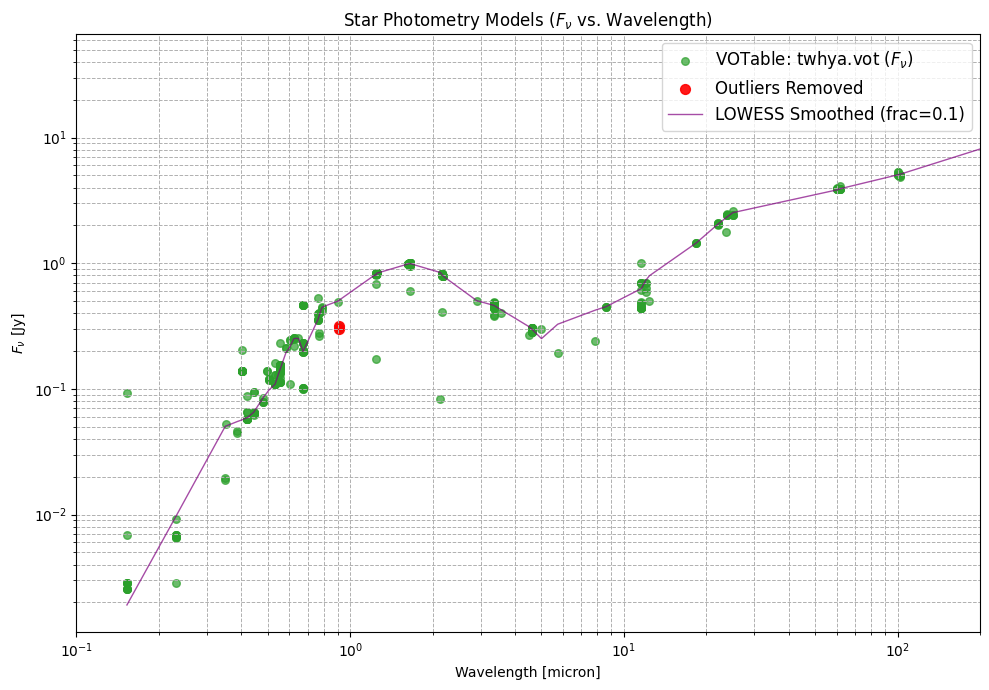

In [2]:
# Plot the Tw Hya Vega Magnitude vs Wavelength
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import statsmodels.api as sm

star_photometry_vot = 'twhya.vot'  # VOTable.
vega_photometry_vot = 'vega.vot'  # Vega magnitude reference.
star_spectral_type = 'M0V'  # Spectral type.

# Read in the VOTable version of the star photometry data.
star_vot = Table.read(star_photometry_vot)

# Convert frequency to wavelength (microns) for plotting.
star_vot["wavelength"] = (const.c / star_vot["sed_freq"]).to(u.micron)

print("VOTable Version of Star Photometry Data:")
star_vot.to_pandas()  # For an easier to read output.

# Constants
c = 299792458.0  # Speed of light in m/s
Jy_to_Wm2Hz = 1e-26  # Conversion factor for Jansky to W/m^-2/Hz^-1
micron_to_m = 1e-6   # Conversion factor for micron to m

# Extract data from your star_vot
star_wavelength_microns = star_vot["wavelength"]
star_sed_flux_jansky = star_vot["sed_flux"]

# Sort the data by wavelength for smoothing
sorted_indices = np.argsort(star_wavelength_microns)
star_wavelength_microns_sorted = star_wavelength_microns[sorted_indices]
star_sed_flux_jansky_sorted = star_sed_flux_jansky[sorted_indices]

# Outlier removal based on the index of the sorted data
outlier_indices = [193,194]
outlier_wavelengths = star_wavelength_microns_sorted[outlier_indices]
outlier_fluxes = star_sed_flux_jansky_sorted[outlier_indices]
print(f"Outliers removed: {outlier_wavelengths} with corresponding fluxes: {outlier_fluxes}")
star_wavelength_microns_sorted = np.delete(star_wavelength_microns_sorted, outlier_indices)
star_sed_flux_jansky_sorted = np.delete(star_sed_flux_jansky_sorted, outlier_indices)

# Smoothing the data using LOWESS
# The 'frac' parameter controls the smoothness.
# It's the fraction of data used for each local regression.
# Adjust this value (e.g., 0.1 to 0.5) to change smoothness.
frac_value = 0.1
smoothed_star_sed_flux_jansky = sm.nonparametric.lowess(star_sed_flux_jansky_sorted, star_wavelength_microns_sorted, frac=frac_value)
smoothed_x = smoothed_star_sed_flux_jansky[:, 0]
smoothed_y = smoothed_star_sed_flux_jansky[:, 1]

# Final Plotting
# --- Figure Configuration ---
plt.figure(figsize=(10, 7)) # Slightly larger for better readability

# Plot the star photometry data
plt.scatter(
    star_wavelength_microns, # X-axis remains wavelength in microns
    star_sed_flux_jansky,
    label=r"VOTable: twhya.vot ($F_{\nu}$)", # Use LaTeX for nu F_nu
    color="C2", # Changed color for distinction if you plot both
    s=30,       # Marker size
    alpha=0.7   # Marker transparency
)

# Plot the outliers in a different color for clarity
plt.scatter(
    outlier_wavelengths,
    outlier_fluxes,
    label="Outliers Removed",
    color="red", # Red for outliers
    s=50,       # Slightly larger marker size for emphasis
    alpha=0.9   # Less transparent for visibility
)

# Plot the LOWESS smoothed curve
plt.plot(
    smoothed_x,
    smoothed_y,
    color='purple', # A distinct color for the smooth line
    linewidth=1,
    label=f'LOWESS Smoothed (frac={frac_value})',
    alpha=0.7   # Marker transparency
)

plt.xlabel("Wavelength [micron]")
plt.ylabel(r"$F_{\nu}$ [Jy]") # LaTeX for units
plt.legend(fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.xlim(0.1, 2e2)
plt.grid(True, linestyle="--", linewidth=0.7, which="both") # 'which="both"' is good for log scales
plt.title(r"Star Photometry Models ($F_{\nu}$ vs. Wavelength)")

plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()

In [4]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F444W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)


STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache
[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R


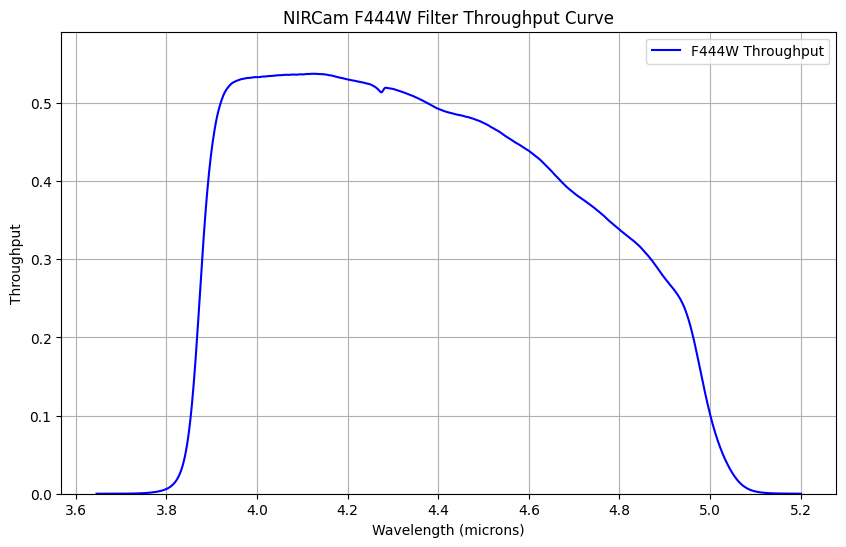

In [5]:
t_waves = nrc.bandpass.wave
t_throughput = nrc.bandpass.throughput

# Plot the throughput curve
plt.figure(figsize=(10, 6))
plt.plot(t_waves/10000, t_throughput, color='blue', label='F444W Throughput')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Throughput')
plt.title('NIRCam F444W Filter Throughput Curve')
plt.ylim(0, max(t_throughput)*1.1)
plt.grid(True)
plt.legend()
plt.show()

### Stellar Spectrum Fitting for TW Hya using BOSZ Models

In [6]:
# Create M2V and K7V spectra from BOSZ models and print their photometry in NIRCam filters (assume magnitude in 2MASS K'-Band of 7.3 mags)

import webbpsf_ext

# Create synphot spectrum from BOSZ grid (Bohlin et al 2017, Mészáros et al. 2024, https://archive.stsci.edu/hlsp/bosz)
# In this case, normalized a ~M0V star to 2MASS K'-Band of 7.3 mags
# Stellar properties (Teff=3800K, log_g=4.2) are from Sokal et al (2018, ApJ, 853, 120)
bp_k = webbpsf_ext.bp_2mass('k')
sp = webbpsf_ext.stellar_spectrum('M0V', 7.3, 'vegamag', bp_k, Teff=3800, log_g=4.2, metallicity=0.0)
# Consider alternative spectrum with slightly different parameters to see how it affects the photometry
sp_m2v = webbpsf_ext.stellar_spectrum('M2V', 7.3, 'vegamag', bp_k, Teff=3600, log_g=4.2, metallicity=0.0)
sp_k7v = webbpsf_ext.stellar_spectrum('K7V', 7.3, 'vegamag', bp_k, Teff=3990, log_g=4.2, metallicity=0.0)

# You can create arbitrary synphot spectrum from arrays like so:
# sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array([...]), flux=np.array([...]), wave_unit='angstrom', flux_unit='flam')
# wave_unit can be 'angstrom', 'um', 'nm', etc.
# flux_unit can be 'Jy', 'flam' (erg/s/cm^2/Angstrom), 'photlam' (photons/s/cm^2/Angstrom), etc

# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp, binset=bp.waveset)
    print(f"{filt} Flux Density (TW Hya System): {obs.effstim('Jy'):.3f} Jy")

sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp.wave), flux=np.array(sp.flux))
sp.convert('flam')  # Convert to erg/s/cm^2/Angstrom
wave = sp.wave
flux = sp.flux

# M2V spectrum
sp_m2v = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp_m2v.wave), flux=np.array(sp_m2v.flux))
sp_m2v.convert('flam')
wave_m2v = sp_m2v.wave
flux_m2v = sp_m2v.flux
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs_m2v = webbpsf_ext.synphot_ext.Observation(sp_m2v, bp, binset=bp.waveset)
    print(f"{filt} Flux Density (M2V Spectrum): {obs_m2v.effstim('Jy'):.3f} Jy")
    
# K7V spectrum
sp_k7v = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp_k7v.wave), flux=np.array(sp_k7v.flux))
sp_k7v.convert('flam')
wave_k7v = sp_k7v.wave
flux_k7v = sp_k7v.flux
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs_k7v = webbpsf_ext.synphot_ext.Observation(sp_k7v, bp, binset=bp.waveset)
    print(f"{filt} Flux Density (K7V Spectrum): {obs_k7v.effstim('Jy'):.3f} Jy")

F200W Flux Density (TW Hya System): 0.854 Jy
F356W Flux Density (TW Hya System): 0.349 Jy
F444W Flux Density (TW Hya System): 0.234 Jy
F200W Flux Density (M2V Spectrum): 0.835 Jy
F356W Flux Density (M2V Spectrum): 0.376 Jy
F444W Flux Density (M2V Spectrum): 0.257 Jy
F200W Flux Density (K7V Spectrum): 0.863 Jy
F356W Flux Density (K7V Spectrum): 0.342 Jy
F444W Flux Density (K7V Spectrum): 0.226 Jy


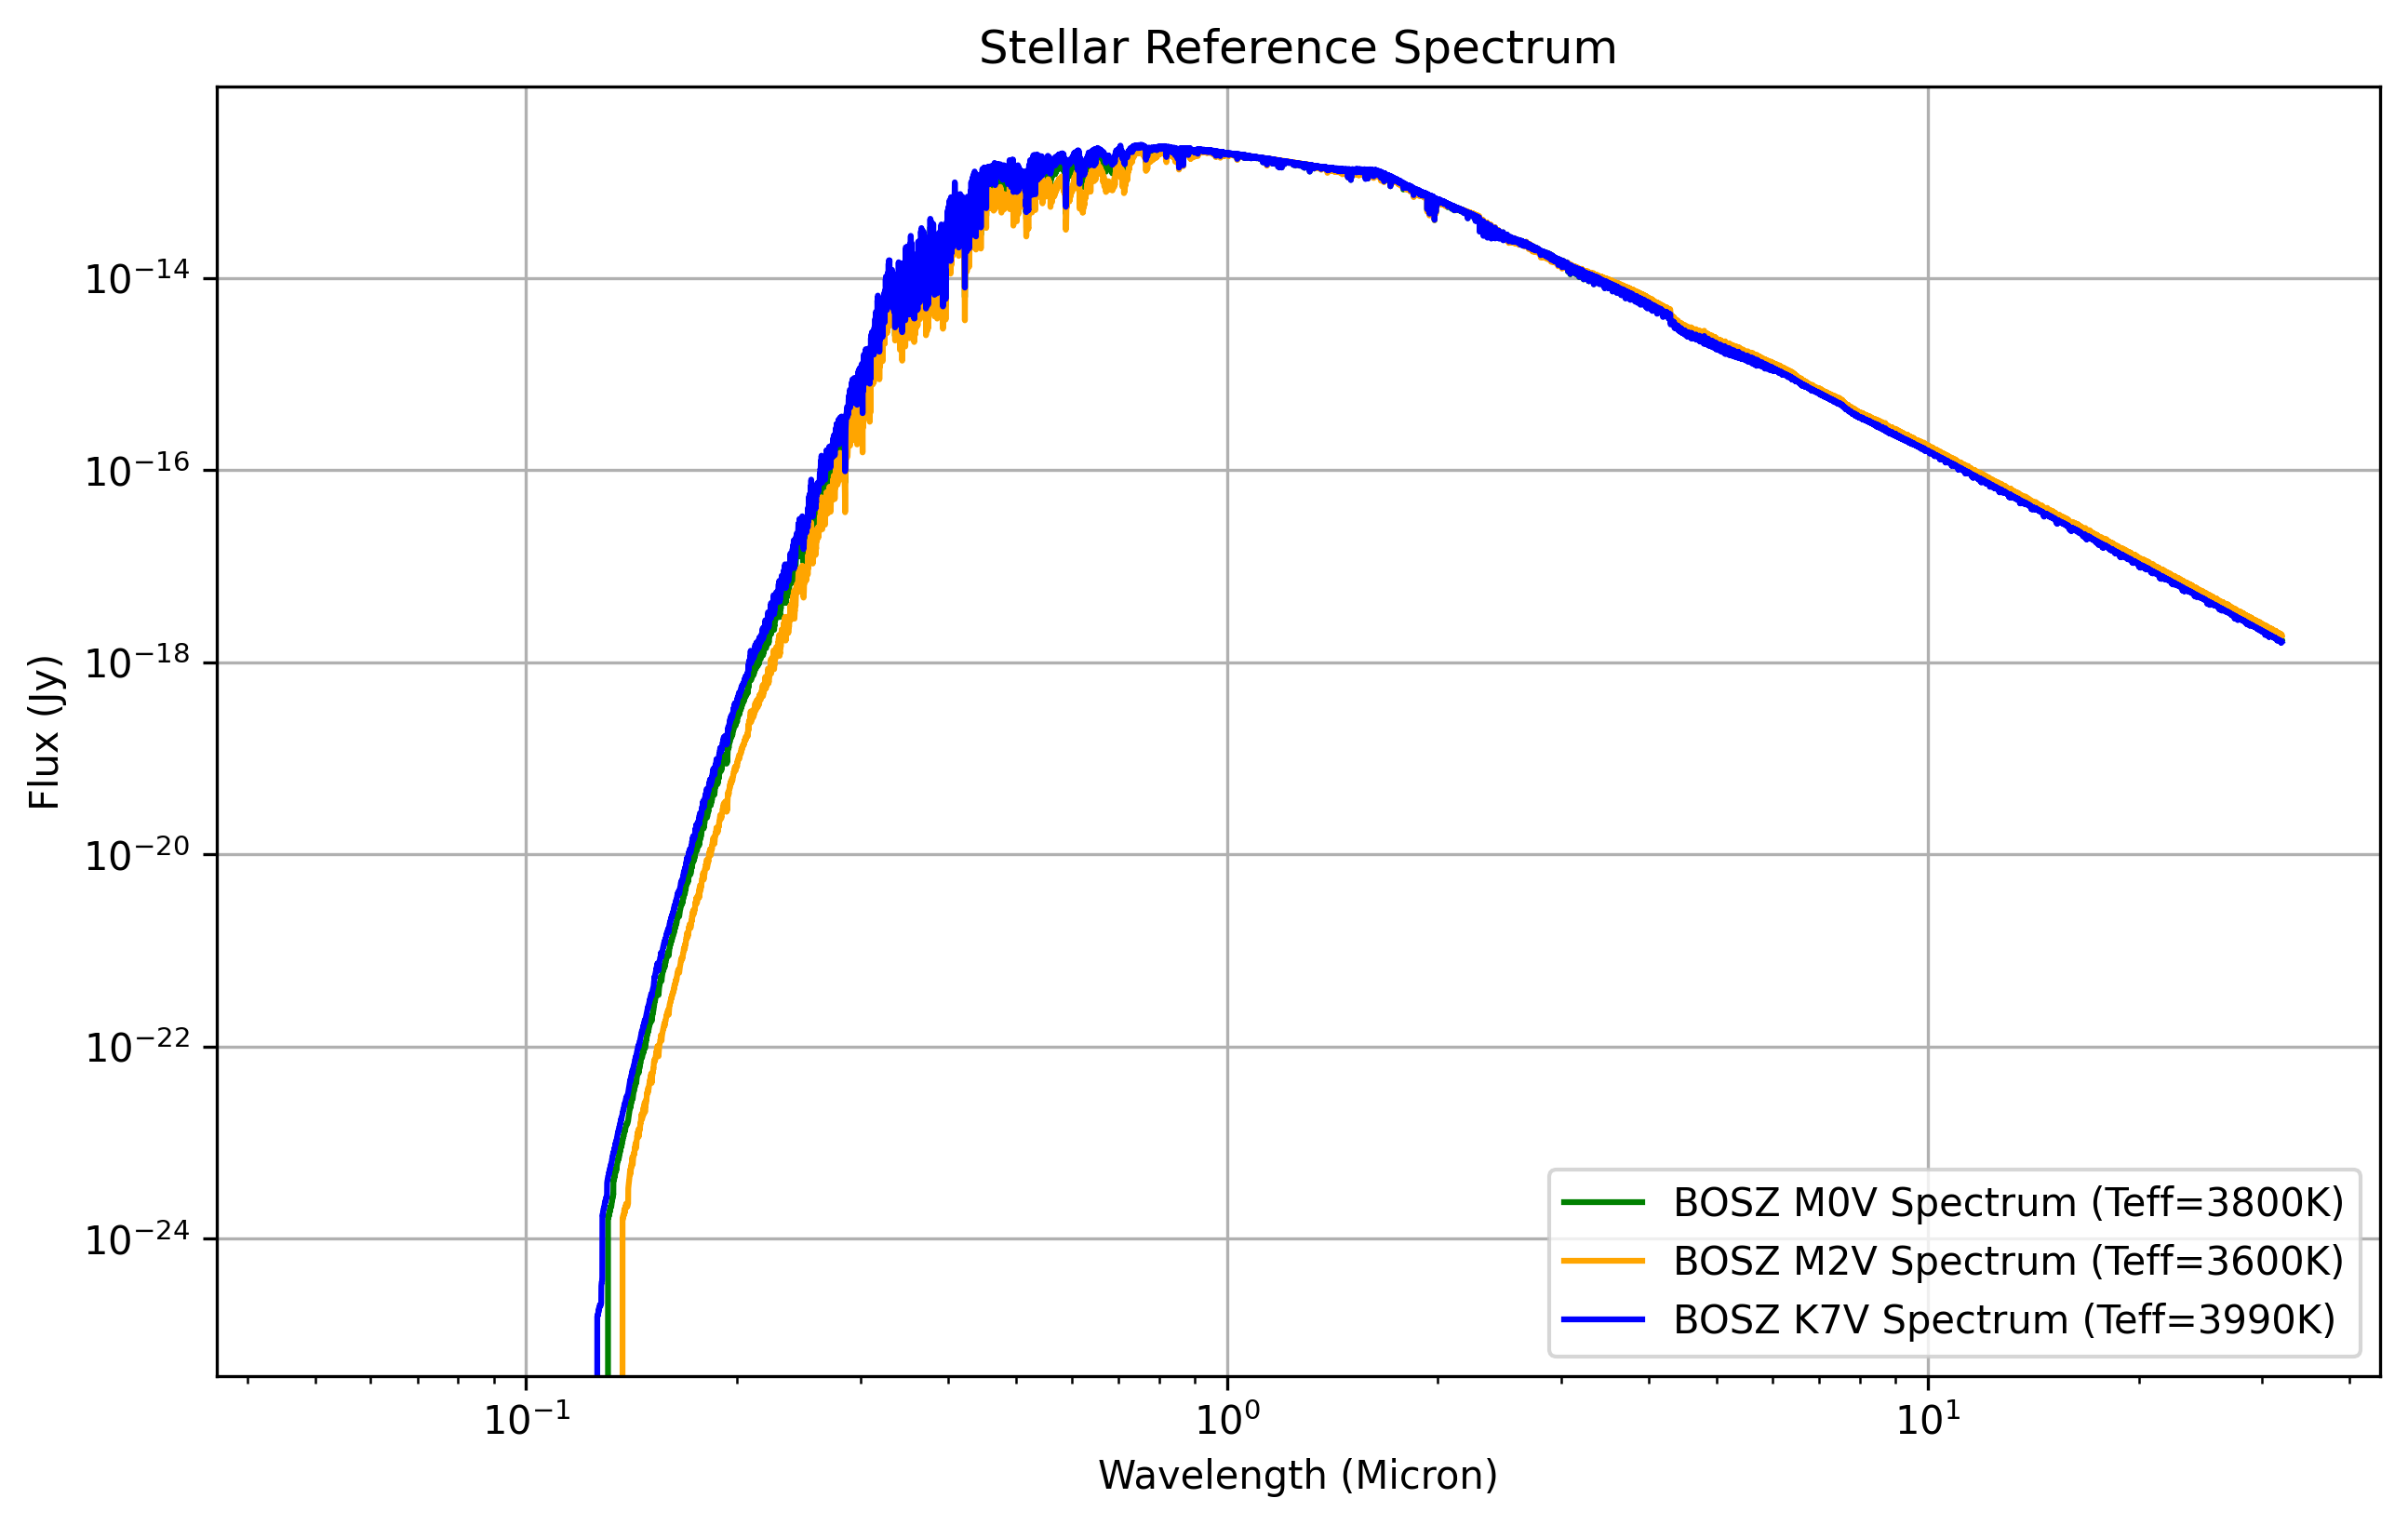

In [7]:
# plotting the flux vs wavelength
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(wave/1e4, flux, color='green', label='BOSZ M0V Spectrum (Teff=3800K)')
plt.plot(wave_m2v/1e4, flux_m2v, color='orange', label='BOSZ M2V Spectrum (Teff=3600K)')
plt.plot(wave_k7v/1e4, flux_k7v, color='blue', label='BOSZ K7V Spectrum (Teff=3990K)')
plt.xlabel('Wavelength (Micron)')
plt.ylabel('Flux (Jy)')
plt.title('Stellar Reference Spectrum')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

##### M0V model fitting

Outliers removed:     wavelength    
      micron      
------------------
0.9090129108550636
0.9090129108550636 with corresponding fluxes:  sed_flux
    Jy   
---------
    0.299
    0.315
Number of data points with 0.7 < λ < 1.8 μm and non-zero errors: 70
Wavelength range for fitting: 0.7621 - 1.6495 μm
Outlier Filtering: Removed 2 outlier(s) based on data error bars.
Reduced χ²: 10.1193

Fit Results:
Scale factor: 9.540076e-01 ± 8.128209e-03


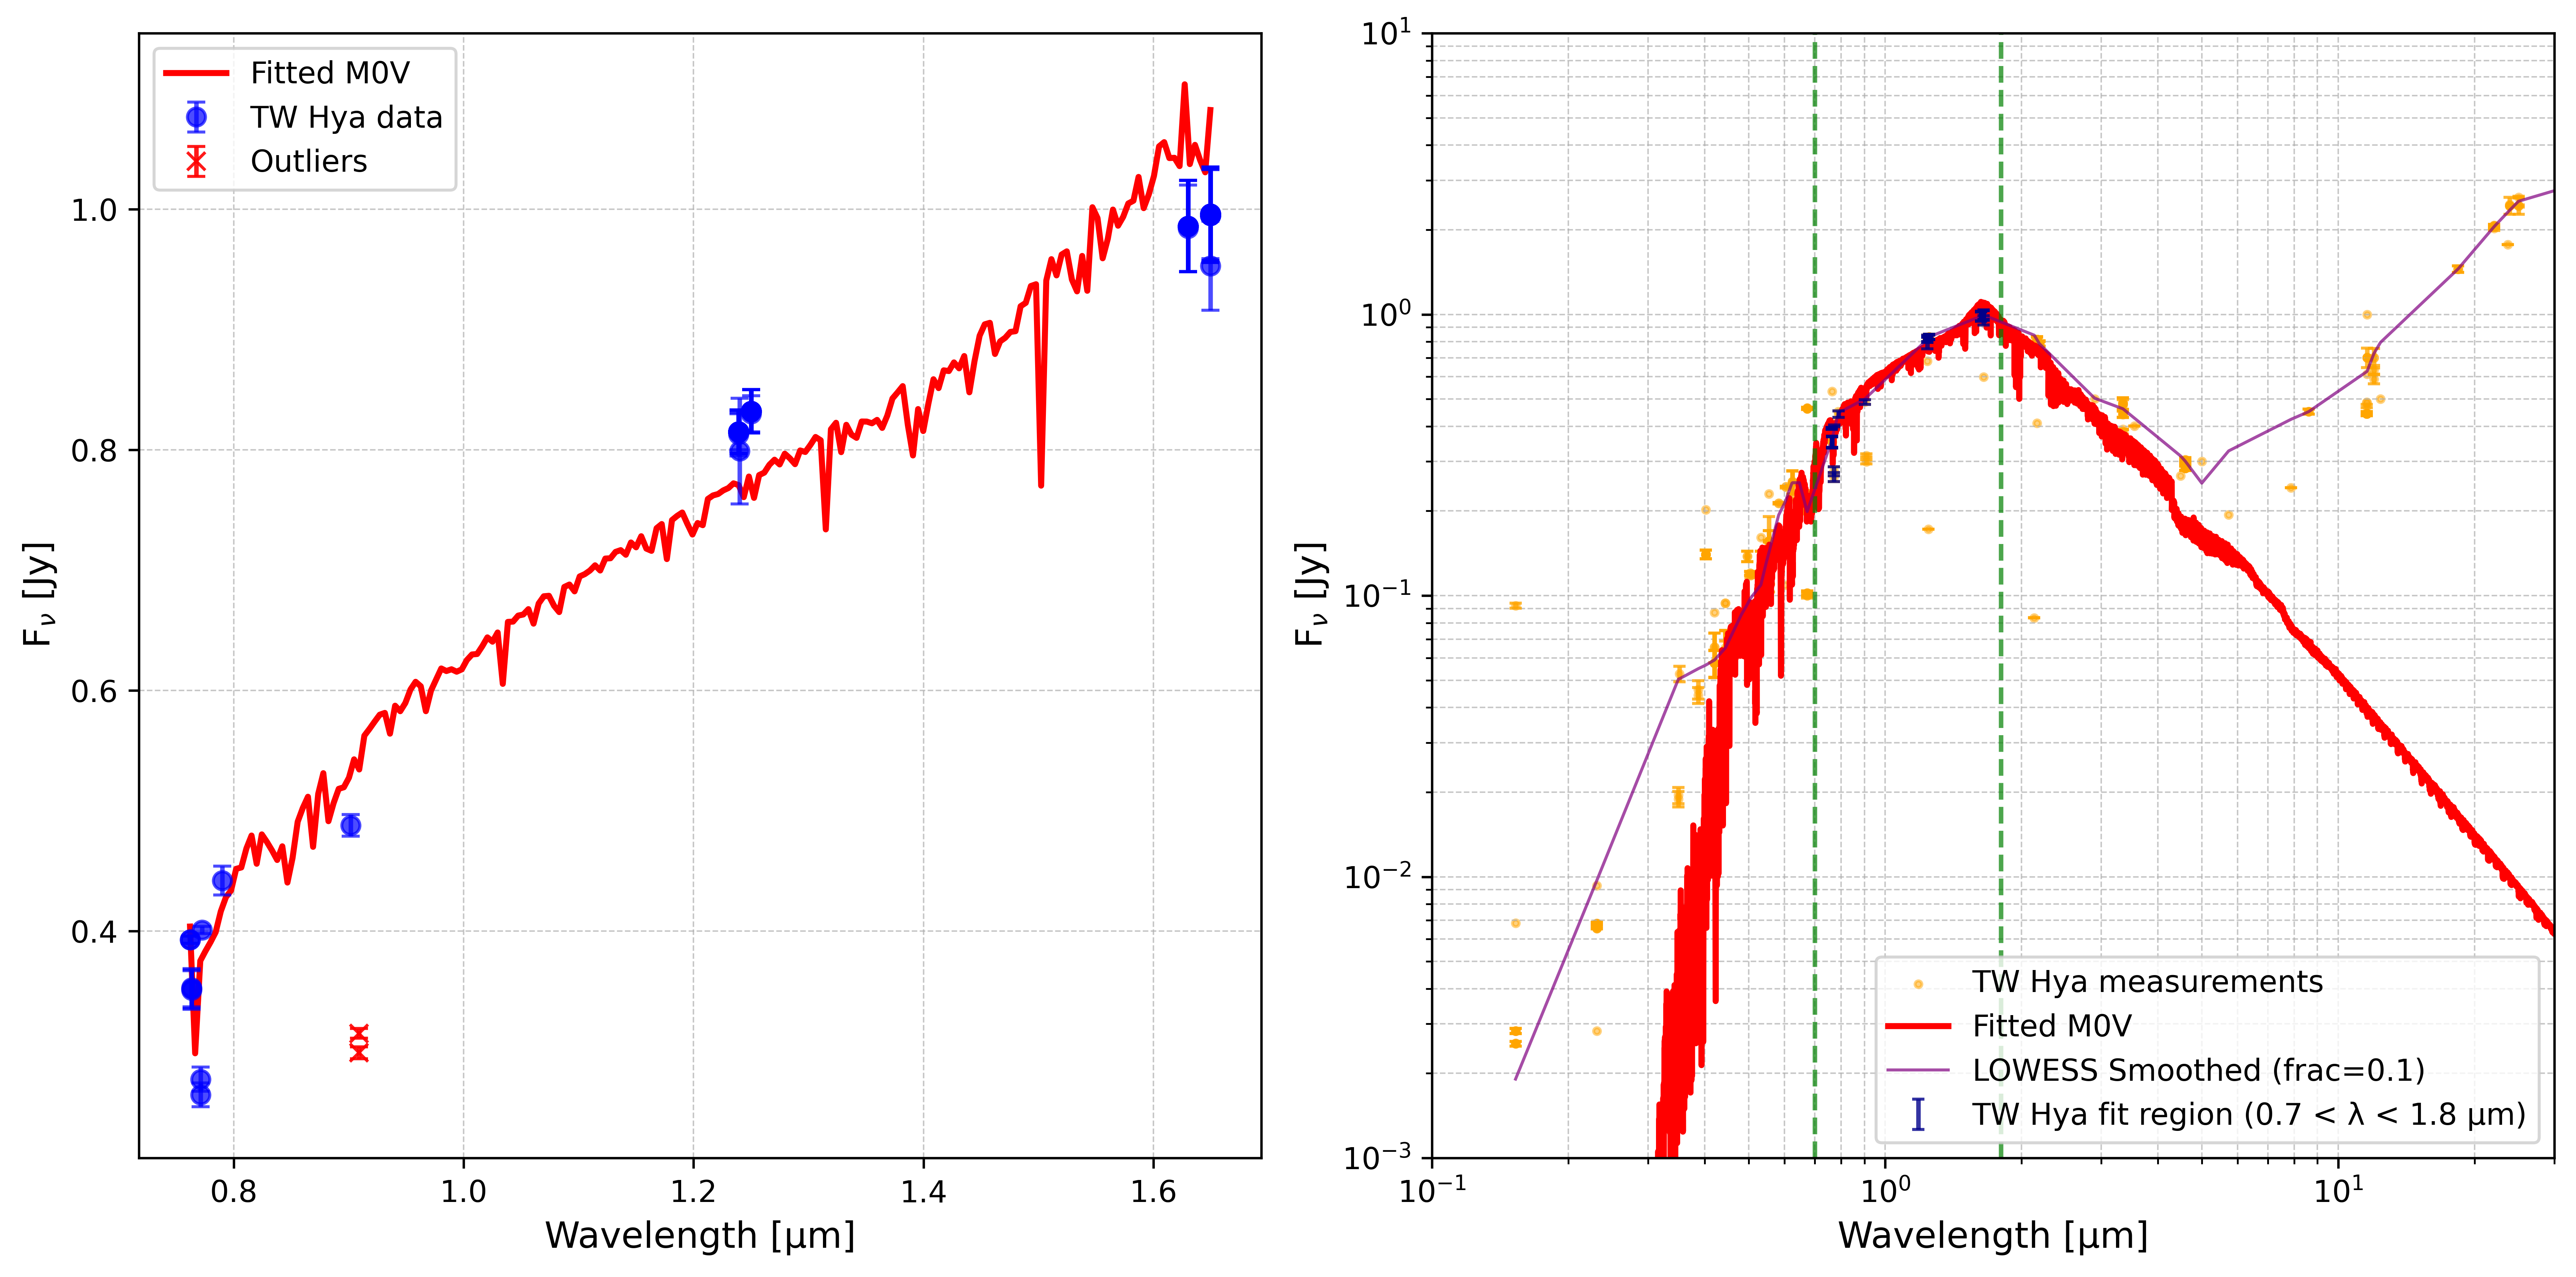

In [8]:
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import statsmodels.api as sm

# M0V spectrum
m0v_wavelength_microns = wave/1e4
m0v_flux = flux

# Read tw hya vot file
star_vot = Table.read('twhya.vot')

# Convert frequency to wavelength (microns) for plotting.
star_vot["wavelength"] = (const.c / star_vot["sed_freq"]).to(u.micron)

# Constants
c = 299792458.0  # Speed of light in m/s
Jy_to_Wm2Hz = 1e-26 # Conversion factor for Jansky to W/m^-2/Hz^-1
micron_to_m = 1e-6   # Conversion factor for micron to m

# Extract data from your star_vot
star_wavelength_microns = star_vot["wavelength"]
star_sed_flux_jansky = star_vot["sed_flux"]

# Sort the data by wavelength for smoothing
sorted_indices = np.argsort(star_wavelength_microns)
star_wavelength_microns_sorted = star_wavelength_microns[sorted_indices]
star_sed_flux_jansky_sorted = star_sed_flux_jansky[sorted_indices]

# Smoothing the data using LOWESS
# The 'frac' parameter controls the smoothness.
# It's the fraction of data used for each local regression.
# Adjust this value (e.g., 0.1 to 0.5) to change smoothness.
frac_value = 0.1
# Outlier removal based on the index of the sorted data
outlier_indices = [193,194]
outlier_wavelengths = star_wavelength_microns_sorted[outlier_indices]
outlier_fluxes = star_sed_flux_jansky_sorted[outlier_indices]
print(f"Outliers removed: {outlier_wavelengths} with corresponding fluxes: {outlier_fluxes}")
star_wavelength_microns_sorted = np.delete(star_wavelength_microns_sorted, outlier_indices)
star_sed_flux_jansky_sorted = np.delete(star_sed_flux_jansky_sorted, outlier_indices)
# generate smoothed flux values using LOWESS
smoothed_star_sed_flux_jansky = sm.nonparametric.lowess(star_sed_flux_jansky_sorted, star_wavelength_microns_sorted, frac=frac_value)
smoothed_x = smoothed_star_sed_flux_jansky[:, 0]
smoothed_y = smoothed_star_sed_flux_jansky[:, 1]
star_flux_wavelengths_interpolator = interp1d(smoothed_x, smoothed_y, kind='linear')

# --- fitting the M0V ---

# Set the cutoff wavelength
cut_off_wavelength_l = 0.7  # microns
cut_off_wavelength = 1.8  # microns

# Create an interpolator for the M0V spectrum (wavelength in microns, flux in erg/s/cm²/Å)
m0v_interpolator = interp1d(m0v_wavelength_microns, m0v_flux, kind='linear', bounds_error=False, fill_value='extrapolate')

# Filter TW Hya data for wavelength < cut_off_wavelength and non-zero errors
mask = (cut_off_wavelength_l < star_vot["wavelength"]) & (star_vot["wavelength"] < cut_off_wavelength) & (star_vot["sed_eflux"] > 0)

tw_hya_wl_fit = star_vot["wavelength"][mask].value  # in microns
tw_hya_flux_fit = star_vot["sed_flux"][mask].value  # in Jy
tw_hya_flux_err_fit = star_vot["sed_eflux"][mask].value  # in Jy

print(f"Number of data points with {cut_off_wavelength_l} < λ < {cut_off_wavelength} μm and non-zero errors: {len(tw_hya_wl_fit)}")
print(f"Wavelength range for fitting: {tw_hya_wl_fit.min():.4f} - {tw_hya_wl_fit.max():.4f} μm")

# Convert M0V flux from F_λ (erg/s/cm²/Å) to F_ν (Jy)
# F_ν = F_λ * (dλ/dν) where dλ/dν = λ²/c
# F_ν = F_λ * (λ²/c) where λ is in cm and c is in cm/s
# Then convert from erg/s/cm²/Hz to Jy (1 Jy = 10^-23 erg/s/cm²/Hz)
def m0v_flux_fnu_jy(wavelength_microns):
    """Convert M0V flux from F_λ [erg/s/cm²/Å] to F_ν [Jy]"""
    flux_flambda = m0v_interpolator(wavelength_microns)  # erg/s/cm²/Å
    wavelength_angstrom = wavelength_microns * 1e4  # Convert microns to Angstroms
    c_cm_per_s = 2.99792458e10  # Speed of light in cm/s
    # For F_λ in erg/s/cm²/Å and conversion to F_ν in erg/s/cm²/Hz:
    # F_ν [erg/s/cm²/Hz] = F_λ [erg/s/cm²/Å] * λ² [Å²] / c [Å/s]
    c_angstrom_per_s = c_cm_per_s * 1e8  # Convert to Å/s
    flux_fnu_erg = flux_flambda * (wavelength_angstrom**2) / c_angstrom_per_s
    
    # Convert to Jy
    flux_fnu_jy = flux_fnu_erg * 1e23  # 1 Jy = 10^-23 erg/s/cm²/Hz
    return flux_fnu_jy

# Define the scaling model: TW Hya flux = scale_factor * M0V flux
def model(wavelength, scale_factor):
    return scale_factor * m0v_flux_fnu_jy(wavelength)

# Perform the INITIAL fit to establish a baseline for residuals
popt_init, pcov_init = curve_fit(model, tw_hya_wl_fit, tw_hya_flux_fit, 
                       sigma=tw_hya_flux_err_fit, p0=[1.0], absolute_sigma=True)

# Generate the initial model flux to compare against data
model_flux_init = model(tw_hya_wl_fit, popt_init[0])

# --- Outlier Filtering Block (Using Measurement Errors) ---
# Calculate residuals
residuals = tw_hya_flux_fit - model_flux_init

# Create a mask keeping data points where the residual is within 3x their specific error bar
sigma_mask = np.abs(residuals) <= 20 * tw_hya_flux_err_fit
outlier_mask = ~sigma_mask  # Invert mask to isolate outliers

# Save outliers into separate arrays for plotting
outlier_wl = tw_hya_wl_fit[outlier_mask]
outlier_flux = tw_hya_flux_fit[outlier_mask]
outlier_err = tw_hya_flux_err_fit[outlier_mask]

print(f"Outlier Filtering: Removed {len(outlier_wl)} outlier(s) based on data error bars.")

# Apply the mask to your fitting arrays to permanently remove outliers
tw_hya_wl_fit = tw_hya_wl_fit[sigma_mask]
tw_hya_flux_fit = tw_hya_flux_fit[sigma_mask]
tw_hya_flux_err_fit = tw_hya_flux_err_fit[sigma_mask]
# ----------------------------------------------------------------

# Perform the FINAL fit using the cleaned data
popt, pcov = curve_fit(model, tw_hya_wl_fit, tw_hya_flux_fit, 
                       sigma=tw_hya_flux_err_fit, p0=popt_init, absolute_sigma=True)

scale_factor = popt[0]
scale_factor_err = np.sqrt(pcov[0, 0])

# Calculate reduced chi-squared using the cleaned data
model_flux_fit = model(tw_hya_wl_fit, scale_factor)
chi_squared = np.sum(((tw_hya_flux_fit - model_flux_fit) / tw_hya_flux_err_fit)**2)
dof = len(tw_hya_wl_fit) - len(popt)  # degrees of freedom = number of data points - number of fitted parameters
reduced_chi_squared = chi_squared / dof
# save the chi-squared value and dof for later use in model comparison
single_component_chi_squared = chi_squared
single_component_dof = dof
print(f"Reduced χ²: {reduced_chi_squared:.4f}")

# If chi^2 > 1, we inflate the error. If chi^2 < 1, we usually keep the raw error (don't shrink it).
inflation_factor = np.sqrt(reduced_chi_squared) if reduced_chi_squared > 1.0 else 1.0
scale_factor_err *= inflation_factor

print(f"\nFit Results:")
print(f"Scale factor: {scale_factor:.6e} ± {scale_factor_err:.6e}")

# Extend the fitted curve to longer wavelengths
wl_extended = np.logspace(np.log10(0.1), np.log10(100), 100000)  # 0.1 to 100 microns
fitted_flux_extended = model(wl_extended, scale_factor)

# Plot the fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

# Left plot: Fit region (Cleaned data)
ax1.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='blue', markersize=6, capsize=3, alpha=0.7,
             label=f'TW Hya data', zorder=3)

# Add Outliers in red
if len(outlier_wl) > 0:
    ax1.errorbar(outlier_wl, outlier_flux, yerr=outlier_err, 
                 fmt='x', color='red', markersize=6, capsize=3, alpha=0.9,
                 label='Outliers', zorder=4)

wl_fit_fine = np.linspace(tw_hya_wl_fit.min(), tw_hya_wl_fit.max(), 200)
fitted_flux_fit = model(wl_fit_fine, scale_factor)
ax1.plot(wl_fit_fine, fitted_flux_fit, 'r-', linewidth=2, 
         label=f'Fitted M0V', zorder=2)

ax1.set_xlabel('Wavelength [μm]', fontsize=12)
ax1.set_ylabel('F$_ν$ [Jy]', fontsize=12)
#ax1.set_title(f'Fit Region: TW Hya vs M0V ({cut_off_wavelength_l} < λ < {cut_off_wavelength} μm)\nχ²/dof = {reduced_chi_squared:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Right plot: Extended to longer wavelengths
# Plot all TW Hya data
ax2.scatter(star_vot["wavelength"], star_vot["sed_flux"],
            s=5, color='orange', alpha=0.5, label='TW Hya measurements', zorder=1)
ax2.errorbar(star_vot["wavelength"], star_vot["sed_flux"], yerr=star_vot["sed_eflux"],linestyle="None",color='orange', markersize=0, capsize=2, alpha=0.8)

# Highlight the fitting region
ax2.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='darkblue', markersize=0, capsize=2, alpha=0.8,
             label=f'TW Hya fit region ({cut_off_wavelength_l} < λ < {cut_off_wavelength} μm)', zorder=3)

# Plot the extended fitted M0V spectrum
ax2.plot(wl_extended, fitted_flux_extended, 'r-', linewidth=2, 
         label=f'Fitted M0V', zorder=2)

# Add vertical line at cutoff wavelength
ax2.axvline(cut_off_wavelength_l, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7)
ax2.axvline(cut_off_wavelength, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7)

ax2.set_xlabel('Wavelength [μm]', fontsize=12)
ax2.set_ylabel('F$_ν$ [Jy]', fontsize=12)

# Plot the LOWESS smoothed curve
ax2.plot(
    smoothed_x,
    smoothed_y,
    color='purple', # A distinct color for the smooth line
    linewidth=1,
    label=f'LOWESS Smoothed (frac={frac_value})',
    alpha=0.7   # Marker transparency
)

#ax2.set_title(f'Extended Fit: TW Hya vs M0V Spectrum\nScale: {scale_factor:.4e} ± {scale_factor_err:.4e}', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-1, 3e1)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(0.001,10)

plt.tight_layout()
plt.show()

# Create interpolator for the fitted extended M0V spectrum
fitted_m0v_interpolator = interp1d(wl_extended, fitted_flux_extended, 
                                    kind='linear', bounds_error=False, fill_value='extrapolate')

In [9]:
# Export the fitted M0V spectrum to a votable like the original TW Hya votable
fitted_table = Table()
fitted_table['wavelength'] = wl_extended * u.micron
fitted_table['sed_freq'] = (const.c / (wl_extended * u.micron)).to(u.GHz)
fitted_table['sed_flux'] = fitted_flux_extended * u.Jy
# Estimate errors using the uncertainties from the fit
fitted_table['sed_eflux'] = (fitted_flux_extended * (scale_factor_err / scale_factor)) * u.Jy

fitted_table.write('fitted_m0v_TWHya.vot', format='votable', overwrite=True)
print("Fitted M0V spectrum exported to 'fitted_m0v_TWHya.vot'")

Fitted M0V spectrum exported to 'fitted_m0v_TWHya.vot'



Filter   Eff Wave   TW Hya [mJy]       M0V [mJy]          Resid [mJy]        Sig   
F200W    2.009        893.81±24.23      814.57±6.94        79.24±25.21      3.1σ
F356W    3.565        434.19±8.69       332.52±2.83       101.67±9.14      11.1σ
F444W    4.362        336.72±2.53       223.26±1.90       113.46±3.17      35.8σ


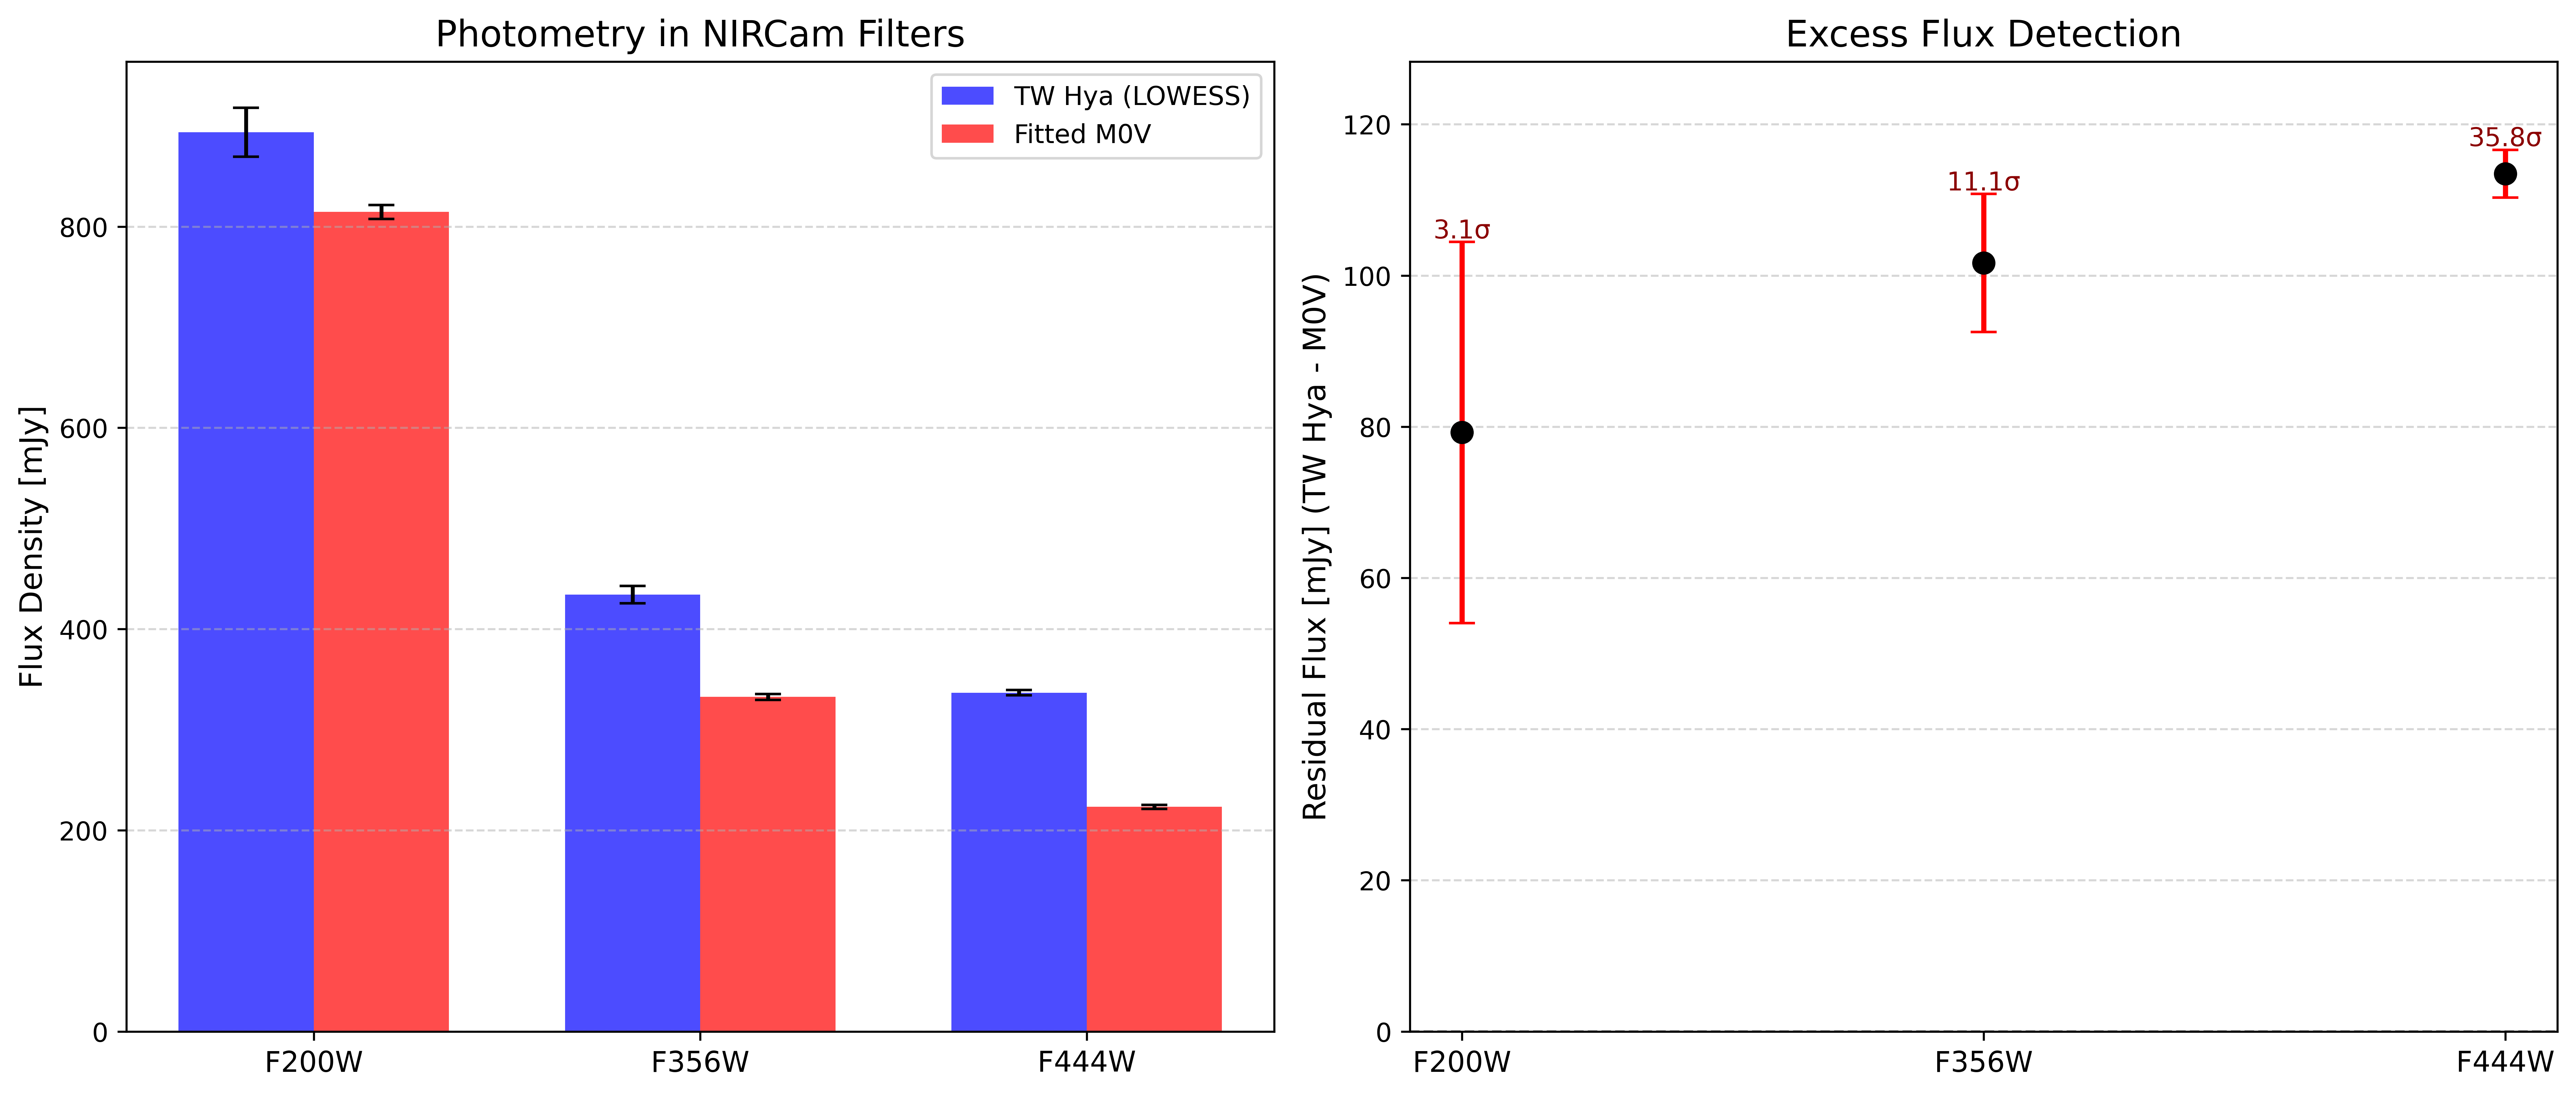

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import webbpsf_ext
from astropy import units as u

# --- 1. Setup Data for Synphot ---

# Clean TW Hya data for Synphot (remove duplicates)
unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
unique_smoothed_y = smoothed_y[unique_indices]

# Create Synphot Spectrum for TW Hya (Observed)
# unique_smoothed_x is in microns, unique_smoothed_y is in Jy
sp_twhya = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=unique_smoothed_x, 
    flux=unique_smoothed_y, 
    waveunits='um', 
    fluxunits='Jy'
)

# Create Synphot Spectrum for Fitted M0V (Model)
# We use the original M0V data (assumed in FLAM: erg/s/cm2/A) scaled by the factor
# Note: Ensure m0v_flux is the un-interpolated array or matches m0v_wavelength_microns
sp_m0v = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=m0v_wavelength_microns, 
    flux=m0v_flux * scale_factor, 
    waveunits='um', 
    fluxunits='flam'
)

# --- 2. Define Filter List and Storage ---

bp_list = ['F200W', 'F356W', 'F444W']
filter_results = {
    'name': [],
    'wavelength': [],
    'twhya_flux': [],
    'twhya_err': [],
    'm0v_flux': [],
    'm0v_err': [],
    'residual': [],
    'resid_err': [],
    'sigma': []
}

print("\n" + "="*90)
print(f"{'Filter':<8} {'Eff Wave':<10} {'TW Hya [mJy]':<18} {'M0V [mJy]':<18} {'Resid [mJy]':<18} {'Sig':<6}")
print("="*90)

# --- 3. Loop Through Filters ---

for filt in bp_list:
    # Load Bandpass
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # Get Effective Wavelength (pivot) and Width (Rectangular approximation)
    eff_wave = bp.pivot().to(u.micron).value
    try:
        # Try to get rectangular width, fallback to approximation if needed
        bp_width = bp.rectwidth().to(u.micron).value
    except:
        bp_width = eff_wave * 0.15 # Fallback approximation
    
    # --- A. Calculate Integrated Fluxes (effstim) ---
    # Observe TW Hya
    obs_twhya = webbpsf_ext.synphot_ext.Observation(sp_twhya, bp)
    flux_twhya_jy = obs_twhya.effstim('Jy')
    
    # Observe M0V Model
    obs_m0v = webbpsf_ext.synphot_ext.Observation(sp_m0v, bp)
    flux_m0v_jy = obs_m0v.effstim('Jy')
    
    # --- B. Calculate Robust Errors for this Filter ---
    
    ## 1. M0V Model Error (Propagated from fit)
    flux_m0v_err = flux_m0v_jy * (scale_factor_err / scale_factor)
    
    # 2. TW Hya Error Components
    # We look for data points within the "Rectangular Width" of the filter
    mask_band = np.abs(star_vot["wavelength"].value - eff_wave) < (bp_width / 2.0)
    flux_in_band = star_vot["sed_flux"].value[mask_band]
    err_in_band = star_vot["sed_eflux"].value[mask_band]
    # Filter valid points
    N = 0 # Number of valid points
    penalty = 0.0 # Penalty for no points in band
    valid = (err_in_band > 0) & (~np.isnan(flux_in_band))
    flux_filt = flux_in_band[valid]
    err_filt = err_in_band[valid]
        
    if len(flux_filt) > 1:
        pass
    else:
        N = 1
        # Fallback if < 2 points in band
        #print(f"Filter {filt}: Not enough data points in band for statistical error, using nearby points.")
        # Use nearest 20 points outside the band for error estimate
        all_flux = star_vot["sed_flux"].value
        all_err = star_vot["sed_eflux"].value
        all_wl = star_vot["wavelength"].value
        # Exclude points without valid errors
        valid_all = all_err > 0
        all_flux = all_flux[valid_all]
        all_err = all_err[valid_all]
        all_wl = all_wl[valid_all]
        # Find indices of nearest 20 points to eff_wave
        distances = np.abs(all_wl - eff_wave)
        nearest_indices = np.argsort(distances)[:10]
        if len(flux_filt) == 0:
            # If no points in band, penalty with the distance to the nearest point * slope
            wl_nearby = eff_wave * np.array([0.99, 1.01])
            flux_nearby = fitted_m0v_interpolator(wl_nearby)
            gradient = np.abs(np.diff(flux_nearby)[0]) / (0.02 * eff_wave)
            penalty = gradient * np.min(distances)
        flux_filt = all_flux[nearest_indices]
        err_filt = all_err[nearest_indices]
    
    # Robust Scatter (MAD) to remove outliers inside the band
    median_f = np.nanmedian(flux_filt)
    mad = np.nanmedian(np.abs(flux_filt - median_f))
    if mad > 0:
        not_outlier = np.abs(flux_filt - median_f) < 3.0 * 1.4826 * mad
        flux_clean = flux_filt[not_outlier]
        err_clean = err_filt[not_outlier]
    else:
        flux_clean, err_clean = flux_filt, err_filt
        
    if N == 0:
        N = len(flux_clean)
    #print(f"Filter {filt}: Found {N} valid data points in band for statistical error calculation.")
    # Standard Error of the Mean (Scatter / sqrt(N))
    sem_scatter = np.std(flux_clean, ddof=1) / np.sqrt(N) if N > 1 else 0
    sem_meas = np.nanmedian(err_clean) / np.sqrt(N) if N > 0 else 0
    flux_twhya_err = np.sqrt(max(sem_scatter, sem_meas)**2 + penalty**2)

    # --- C. Calculate Residuals ---
    residual = flux_twhya_jy - flux_m0v_jy
    resid_err = np.sqrt(flux_twhya_err**2 + flux_m0v_err**2)
    sigma = residual / resid_err if resid_err > 0 else 0
    
    # Store Data
    filter_results['name'].append(filt)
    filter_results['wavelength'].append(eff_wave)
    filter_results['twhya_flux'].append(flux_twhya_jy)
    filter_results['twhya_err'].append(flux_twhya_err)
    filter_results['m0v_flux'].append(flux_m0v_jy)
    filter_results['m0v_err'].append(flux_m0v_err)
    filter_results['residual'].append(residual)
    filter_results['resid_err'].append(resid_err)
    filter_results['sigma'].append(sigma)
    
    print(f"{filt:<8} {eff_wave:<10.3f} {flux_twhya_jy*1000:>8.2f}±{flux_twhya_err*1000:<8.2f} "
          f"{flux_m0v_jy*1000:>8.2f}±{flux_m0v_err*1000:<8.2f} "
          f"{residual*1000:>8.2f}±{resid_err*1000:<8.2f} {sigma:>5.1f}σ")

print("="*90)

# --- 4. Plotting the Results ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=600)

# X-axis setup
x_pos = np.arange(len(bp_list))
labels = filter_results['name']

# --- PLOT 1: Flux Comparison (Bar Chart) ---
width = 0.35
ax1.bar(x_pos - width/2, np.array(filter_results['twhya_flux'])*1000, width, 
        yerr=np.array(filter_results['twhya_err'])*1000, capsize=5, 
        label='TW Hya (LOWESS)', color='blue', alpha=0.7)

ax1.bar(x_pos + width/2, np.array(filter_results['m0v_flux'])*1000, width, 
        yerr=np.array(filter_results['m0v_err'])*1000, capsize=5, 
        label='Fitted M0V', color='red', alpha=0.7)

ax1.set_ylabel('Flux Density [mJy]', fontsize=12)
ax1.set_title('Photometry in NIRCam Filters', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT 2: Residuals (Scatter with Error Bars) ---
# Convert to mJy for easier reading
y_res = np.array(filter_results['residual']) * 1000
y_err = np.array(filter_results['resid_err']) * 1000

ax2.errorbar(x_pos, y_res, yerr=y_err, fmt='o', color='k', 
             ecolor='red', elinewidth=2, capsize=5, markersize=8, label='Residual')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add text annotations for Sigma
for i, sig in enumerate(filter_results['sigma']):
    ax2.annotate(f'{sig:.1f}σ', (x_pos[i], y_res[i] + y_err[i] + 0.5), 
                 ha='center', color='darkred', fontsize=10)

ax2.set_ylabel('Residual Flux [mJy] (TW Hya - M0V)', fontsize=12)
ax2.set_title('Excess Flux Detection', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, max(y_res + y_err) * 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # remove duplicated wavelengths in smoothed data
    unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
    unique_smoothed_y = smoothed_y[unique_indices]
    sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=unique_smoothed_x, flux=unique_smoothed_y, waveunits='um', fluxunits='Jy')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp)
    print(f"{filt} TW Hya System Flux Density: {obs.effstim('Jy'):.3f} Jy")
    
    # fitted flux at filter wavelength
    sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=m0v_wavelength_microns, flux=m0v_flux*scale_factor, waveunits='um', fluxunits='flam')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp)
    print(f"{filt} Stellar Flux Density: {obs.effstim('Jy'):.3f} Jy")

F200W TW Hya System Flux Density: 0.894 Jy
F200W Stellar Flux Density: 0.815 Jy
F356W TW Hya System Flux Density: 0.434 Jy
F356W Stellar Flux Density: 0.333 Jy
F444W TW Hya System Flux Density: 0.337 Jy
F444W Stellar Flux Density: 0.223 Jy


##### Two-component (M2V+K7V) model fitting

Outliers removed:     wavelength    
      micron      
------------------
0.9090129108550636
0.9090129108550636 with corresponding fluxes:  sed_flux
    Jy   
---------
    0.299
    0.315
Number of data points with 0.7 < λ < 1.8 μm and non-zero errors: 70
Wavelength range for fitting: 0.7621 - 1.6495 μm
Outlier Filtering: Removed 2 outlier(s) based on data error bars.
Reduced χ²: 8.4941

Fit Results:
Scale factor M2V: 5.523627e-01 ± 7.809016e-02
Scale factor K7V: 4.192341e-01 ± 7.170593e-02
Ratio (M2V:K7V): 0.569 ± 0.126 : 0.431 ± 0.096


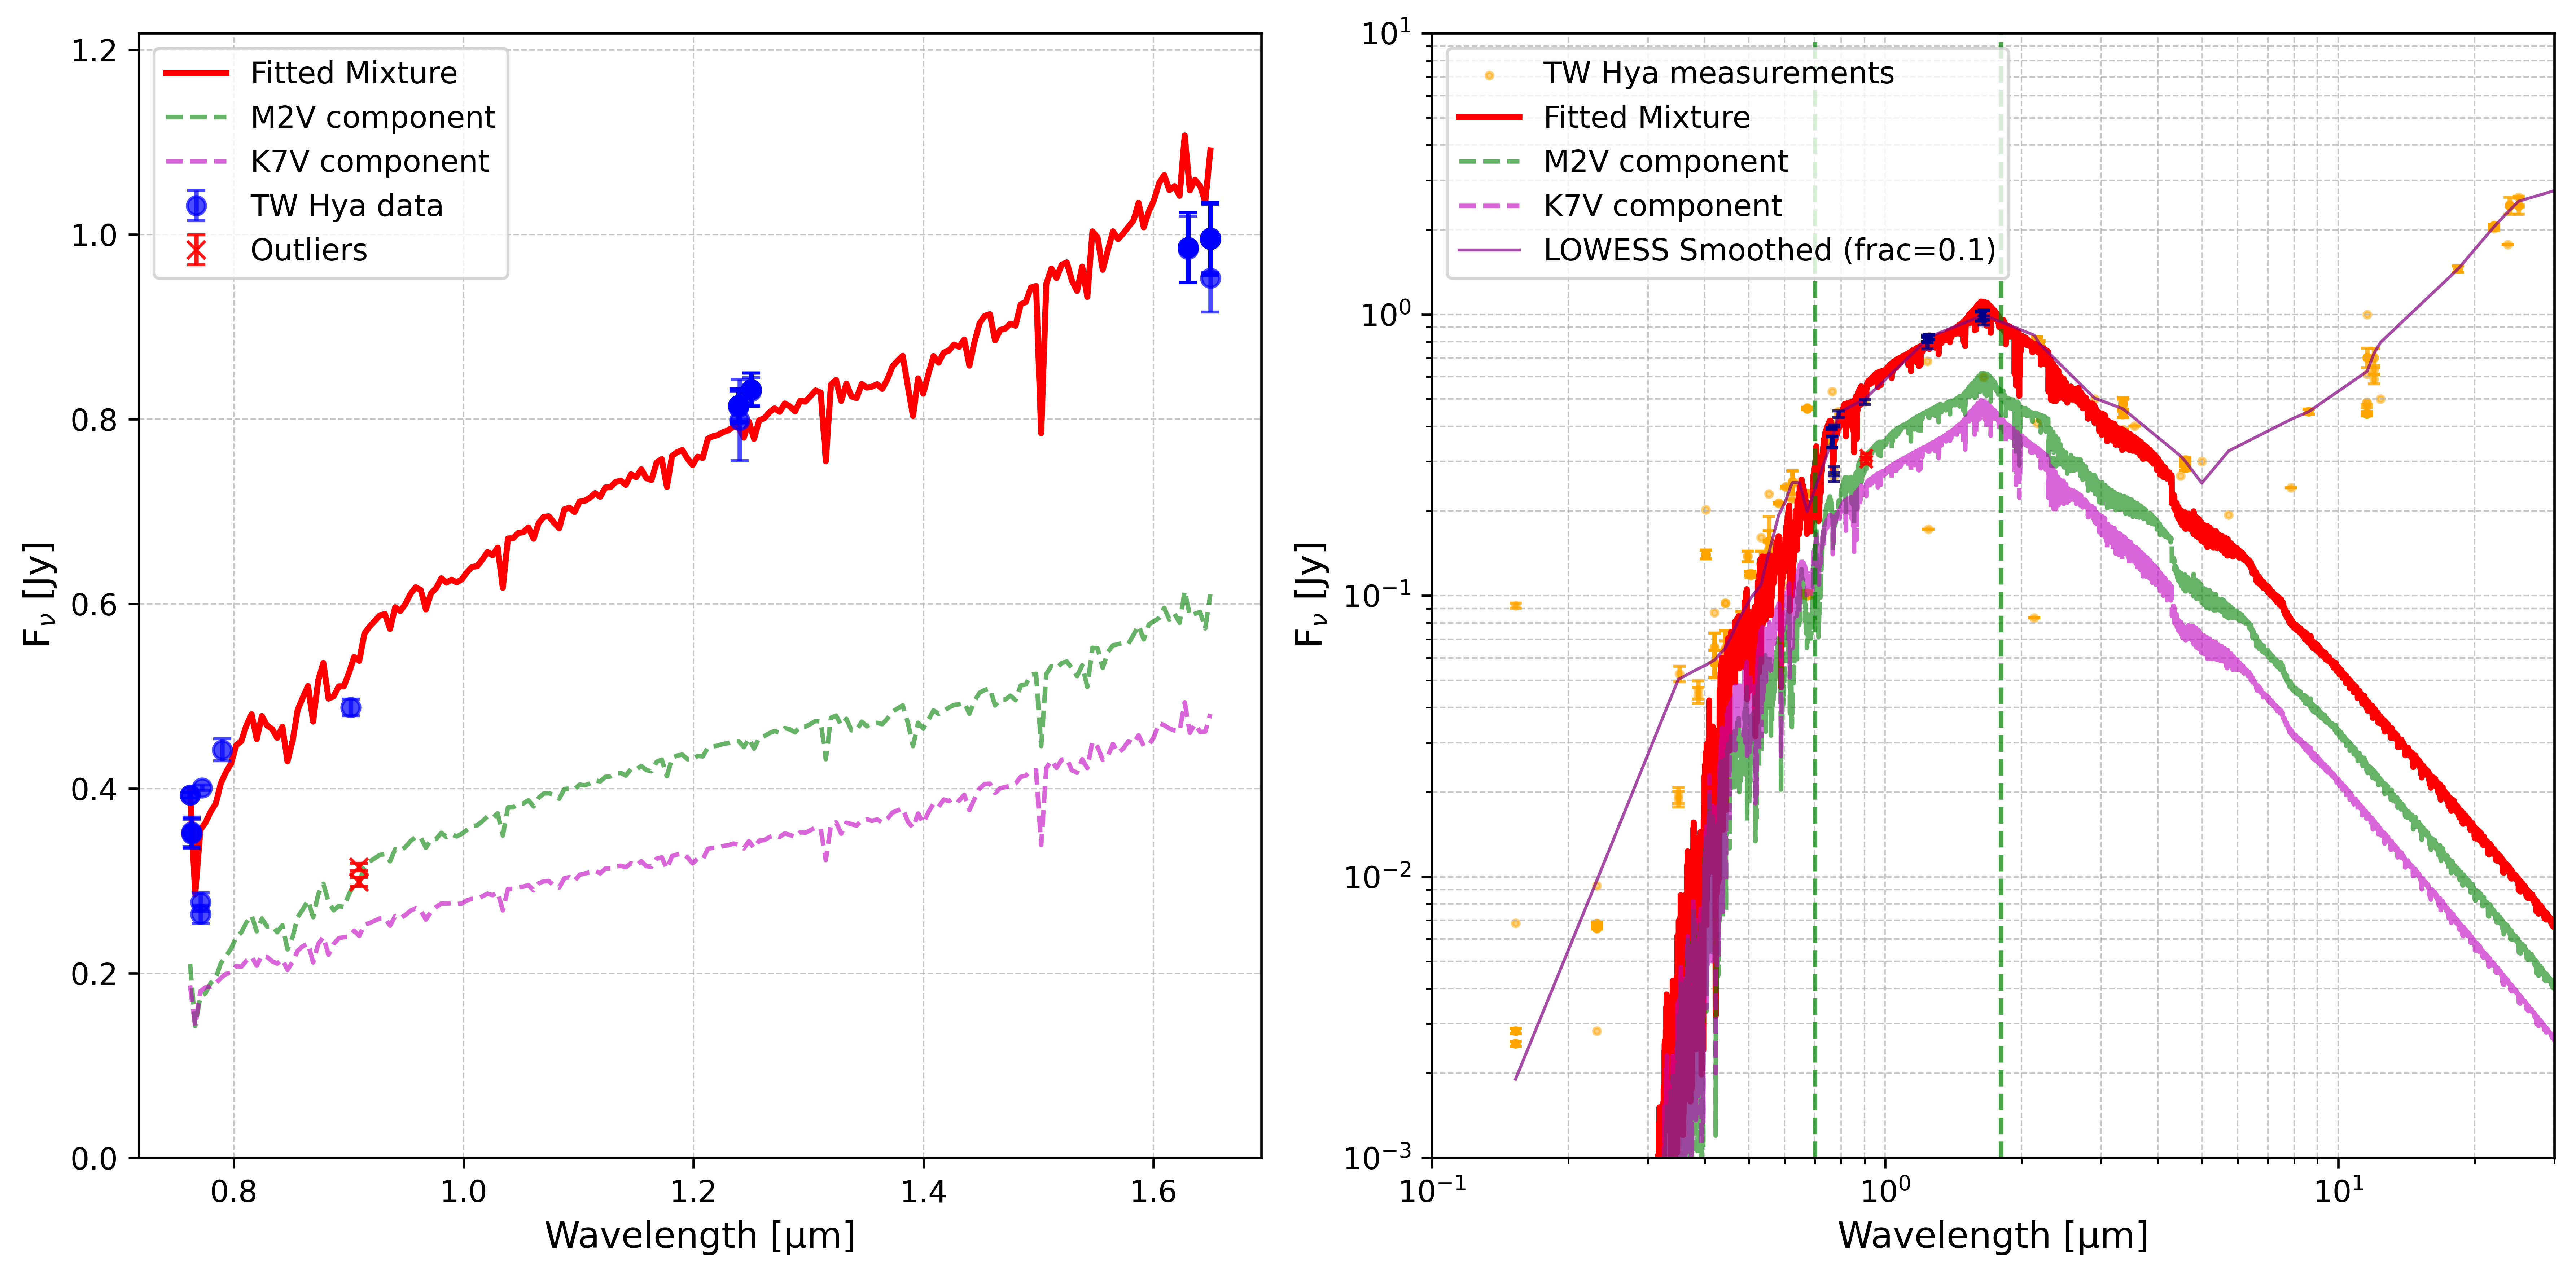

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import statsmodels.api as sm

# --- Setup Spectra ---
# Ensure you load/define your wave and flux arrays for M2V and K7V before this point.
m2v_wavelength_microns = wave_m2v / 1e4
m2v_flux = flux_m2v

k7v_wavelength_microns = wave_k7v / 1e4
k7v_flux = flux_k7v

# Read tw hya vot file
star_vot = Table.read('twhya.vot')

# Convert frequency to wavelength (microns) for plotting.
star_vot["wavelength"] = (const.c / star_vot["sed_freq"]).to(u.micron)

# Constants
c = 299792458.0  # Speed of light in m/s
Jy_to_Wm2Hz = 1e-26 # Conversion factor for Jansky to W/m^-2/Hz^-1
micron_to_m = 1e-6   # Conversion factor for micron to m

# Extract data from your star_vot
star_wavelength_microns = star_vot["wavelength"]
star_sed_flux_jansky = star_vot["sed_flux"]

# Sort the data by wavelength for smoothing
sorted_indices = np.argsort(star_wavelength_microns)
star_wavelength_microns_sorted = star_wavelength_microns[sorted_indices]
star_sed_flux_jansky_sorted = star_sed_flux_jansky[sorted_indices]

# Smoothing the data using LOWESS
frac_value = 0.1
# Outlier removal based on the index of the sorted data
outlier_indices = [193,194]
outlier_wavelengths = star_wavelength_microns_sorted[outlier_indices]
outlier_fluxes = star_sed_flux_jansky_sorted[outlier_indices]
print(f"Outliers removed: {outlier_wavelengths} with corresponding fluxes: {outlier_fluxes}")
star_wavelength_microns_sorted = np.delete(star_wavelength_microns_sorted, outlier_indices)
star_sed_flux_jansky_sorted = np.delete(star_sed_flux_jansky_sorted, outlier_indices)
# generate smoothed flux values using LOWESS
smoothed_star_sed_flux_jansky = sm.nonparametric.lowess(
    star_sed_flux_jansky_sorted, star_wavelength_microns_sorted, frac=frac_value
)
smoothed_x = smoothed_star_sed_flux_jansky[:, 0]
smoothed_y = smoothed_star_sed_flux_jansky[:, 1]
star_flux_wavelengths_interpolator = interp1d(smoothed_x, smoothed_y, kind='linear')

# --- Fitting the M2V + K7V mixture ---

# Set the cutoff wavelength
cut_off_wavelength_l = 0.7  # microns
cut_off_wavelength = 1.8  # microns

# Create interpolators for both spectra (wavelength in microns, flux in erg/s/cm²/Å)
m2v_interpolator = interp1d(m2v_wavelength_microns, m2v_flux, kind='linear', bounds_error=False, fill_value='extrapolate')
k7v_interpolator = interp1d(k7v_wavelength_microns, k7v_flux, kind='linear', bounds_error=False, fill_value='extrapolate')

# Filter TW Hya data for wavelength &lt; cut_off_wavelength and non-zero errors
mask = (cut_off_wavelength_l < star_vot["wavelength"]) & (star_vot["wavelength"] < cut_off_wavelength) & (star_vot["sed_eflux"] > 0)

tw_hya_wl_fit = star_vot["wavelength"][mask].value  # in microns
tw_hya_flux_fit = star_vot["sed_flux"][mask].value  # in Jy
tw_hya_flux_err_fit = star_vot["sed_eflux"][mask].value  # in Jy

print(f"Number of data points with {cut_off_wavelength_l} < λ < {cut_off_wavelength} μm and non-zero errors: {len(tw_hya_wl_fit)}")
print(f"Wavelength range for fitting: {tw_hya_wl_fit.min():.4f} - {tw_hya_wl_fit.max():.4f} μm")

def spectrum_flux_fnu_jy(interpolator, wavelength_microns):
    """Convert flux from F_λ [erg/s/cm²/Å] to F_ν [Jy] dynamically"""
    flux_flambda = interpolator(wavelength_microns)  # erg/s/cm²/Å
    wavelength_angstrom = wavelength_microns * 1e4  # Convert microns to Angstroms
    c_cm_per_s = 2.99792458e10  # Speed of light in cm/s
    c_angstrom_per_s = c_cm_per_s * 1e8  # Convert to Å/s
    
    # F_ν [erg/s/cm²/Hz] = F_λ [erg/s/cm²/Å] * λ² [Å²] / c [Å/s]
    flux_fnu_erg = flux_flambda * (wavelength_angstrom**2) / c_angstrom_per_s
    
    # Convert to Jy (1 Jy = 10^-23 erg/s/cm²/Hz)
    flux_fnu_jy = flux_fnu_erg * 1e23  
    return flux_fnu_jy

# Define the combination model: TW Hya flux = (scale_m2v * M2V) + (scale_k7v * K7V)
def model(wavelength, scale_m2v, scale_k7v):
    fnu_m2v = spectrum_flux_fnu_jy(m2v_interpolator, wavelength)
    fnu_k7v = spectrum_flux_fnu_jy(k7v_interpolator, wavelength)
    return (scale_m2v * fnu_m2v) + (scale_k7v * fnu_k7v)

# Perform the INITIAL fit to establish a baseline for residuals
popt_init, pcov_init = curve_fit(model, tw_hya_wl_fit, tw_hya_flux_fit, 
                       sigma=tw_hya_flux_err_fit, p0=[1.0, 1.0], absolute_sigma=True)

# Generate the initial model flux to compare against data
model_flux_init = model(tw_hya_wl_fit, popt_init[0], popt_init[1])

# --- Outlier Filtering Block ---
# Calculate residuals and their standard deviation
residuals = tw_hya_flux_fit - model_flux_init

# Create a mask keeping data points where the residual is within 3x their specific error bar
sigma_mask = np.abs(residuals) <= 20 * tw_hya_flux_err_fit
outlier_mask = ~sigma_mask  # Invert mask to isolate outliers

# Save outliers into separate arrays for plotting
outlier_wl = tw_hya_wl_fit[outlier_mask]
outlier_flux = tw_hya_flux_fit[outlier_mask]
outlier_err = tw_hya_flux_err_fit[outlier_mask]

print(f"Outlier Filtering: Removed {len(outlier_wl)} outlier(s) based on data error bars.")

# Apply the mask to your fitting arrays to permanently remove outliers
tw_hya_wl_fit = tw_hya_wl_fit[sigma_mask]
tw_hya_flux_fit = tw_hya_flux_fit[sigma_mask]
tw_hya_flux_err_fit = tw_hya_flux_err_fit[sigma_mask]
# ----------------------------------------------------------------

# Perform the FINAL fit using the cleaned data
popt, pcov = curve_fit(model, tw_hya_wl_fit, tw_hya_flux_fit, 
                       sigma=tw_hya_flux_err_fit, p0=popt_init, absolute_sigma=True)
scale_m2v, scale_k7v = popt

# Calculate reduced chi-squared using the cleaned data
model_flux_fit = model(tw_hya_wl_fit, scale_m2v, scale_k7v)
chi_squared = np.sum(((tw_hya_flux_fit - model_flux_fit) / tw_hya_flux_err_fit)**2)
dof = len(tw_hya_wl_fit) - len(popt)  # degrees of freedom = number of data points - number of fitted parameters
reduced_chi_squared = chi_squared / dof

# save the chi-squared value and dof for later use in model comparison
two_component_chi_squared = chi_squared
two_component_dof = dof
print(f"Reduced χ²: {reduced_chi_squared:.4f}")

# Scale the entire covariance matrix if the fit is poor (Red Chi^2 > 1)
if reduced_chi_squared > 1.0:
    pcov *= reduced_chi_squared 

# Extract variances and the specific covariance term
var_m2v = pcov[0, 0]
var_k7v = pcov[1, 1]
cov_m2v_k7v = pcov[0, 1] 

# Calculate individual errors from the scaled matrix for reporting
scale_m2v_err = np.sqrt(var_m2v)
scale_k7v_err = np.sqrt(var_k7v)

print(f"\nFit Results:")
print(f"Scale factor M2V: {scale_m2v:.6e} ± {scale_m2v_err:.6e}")
print(f"Scale factor K7V: {scale_k7v:.6e} ± {scale_k7v_err:.6e}")
# Normalized ratio of the two components
if scale_k7v >0 and scale_m2v > 0:
    ratio_m2v = scale_m2v / (scale_k7v + scale_m2v)  # Ratio of M2V to total
    ratio_m2v_err = ratio_m2v * np.sqrt((scale_m2v_err / scale_m2v)**2 + (scale_k7v_err / scale_k7v)**2)
    ratio_k7v = scale_k7v / (scale_k7v + scale_m2v)  # Ratio of K7V to total
    ratio_k7v_err = ratio_k7v * np.sqrt((scale_k7v_err / scale_k7v)**2 + (scale_m2v_err / scale_m2v)**2)
    print(f"Ratio (M2V:K7V): {ratio_m2v:.3f} ± {ratio_m2v_err:.3f} : {ratio_k7v:.3f} ± {ratio_k7v_err:.3f}")
else:
    print("Cannot calculate ratio (one or both scale factors are non-positive).")

# Extend the fitted curve to longer wavelengths
wl_extended = np.logspace(np.log10(0.1), np.log10(100), 100000)  # 0.1 to 100 microns
fitted_flux_extended = model(wl_extended, scale_m2v, scale_k7v)

# Plot the fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

# Left plot: Fit region
# Left plot: Fit region (Cleaned data)
ax1.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='blue', markersize=6, capsize=3, alpha=0.7,
             label='TW Hya data', zorder=3)

# Outliers in red
if len(outlier_wl) > 0:
    ax1.errorbar(outlier_wl, outlier_flux, yerr=outlier_err, 
                 fmt='x', color='red', markersize=6, capsize=3, alpha=0.9,
                 label='Outliers', zorder=4)

wl_fit_fine = np.linspace(tw_hya_wl_fit.min(), tw_hya_wl_fit.max(), 200)
model_flux_fine = model(wl_fit_fine, scale_m2v, scale_k7v)
ax1.plot(wl_fit_fine, model_flux_fine, 'r-', linewidth=2, 
         label=f'Fitted Mixture', zorder=2)
# Optional: Plot the individual components
ax1.plot(wl_fit_fine, model(wl_fit_fine, scale_m2v, 0), 'g--', alpha=0.6, label='M2V component')
ax1.plot(wl_fit_fine, model(wl_fit_fine, 0, scale_k7v), 'm--', alpha=0.6, label='K7V component')

ax1.set_xlabel('Wavelength [μm]', fontsize=12)
ax1.set_ylabel('F$_ν$ [Jy]', fontsize=12)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# Use the max of the model flux in the fit region to set the y-axis limit for better visualization
max_flux_plot = max(tw_hya_flux_fit.max(), model_flux_fine.max())
ax1.set_ylim(0, max_flux_plot * 1.1)

# Right plot: Extended to longer wavelengths
ax2.scatter(star_vot["wavelength"], star_vot["sed_flux"],
            s=5, color='orange', alpha=0.5, label='TW Hya measurements', zorder=1)
ax2.errorbar(star_vot["wavelength"], star_vot["sed_flux"], yerr=star_vot["sed_eflux"],
             linestyle="None", color='orange', markersize=0, capsize=2, alpha=0.8)

ax2.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='darkblue', markersize=0, capsize=2, alpha=0.8, zorder=3)

# Add Outliers in red
if len(outlier_wl) > 0:
    ax2.errorbar(outlier_wl, outlier_flux, yerr=outlier_err, 
                 fmt='x', color='red', markersize=4, capsize=2, alpha=0.9, zorder=4)

# Plot the extended fitted mixture spectrum
ax2.plot(wl_extended, fitted_flux_extended, 'r-', linewidth=2, 
         label=f'Fitted Mixture', zorder=2)
ax2.plot(wl_extended, model(wl_extended, scale_m2v, 0), 'g--', alpha=0.6, label='M2V component')
ax2.plot(wl_extended, model(wl_extended, 0, scale_k7v), 'm--', alpha=0.6, label='K7V component')

# Add vertical line at cutoff wavelength
ax2.axvline(cut_off_wavelength_l, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(cut_off_wavelength, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_xlabel('Wavelength [μm]', fontsize=12)
ax2.set_ylabel('F$_ν$ [Jy]', fontsize=12)

# Plot the LOWESS smoothed curve
ax2.plot(smoothed_x, smoothed_y, color='purple', linewidth=1,
         label=f'LOWESS Smoothed (frac={frac_value})', alpha=0.7)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-1, 3e1)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_ylim(0.001, 10)

plt.tight_layout()
plt.show()

# Create interpolator for the fitted extended mixture spectrum
fitted_mixture_interpolator = interp1d(wl_extended, fitted_flux_extended, 
                                       kind='linear', bounds_error=False, fill_value='extrapolate')


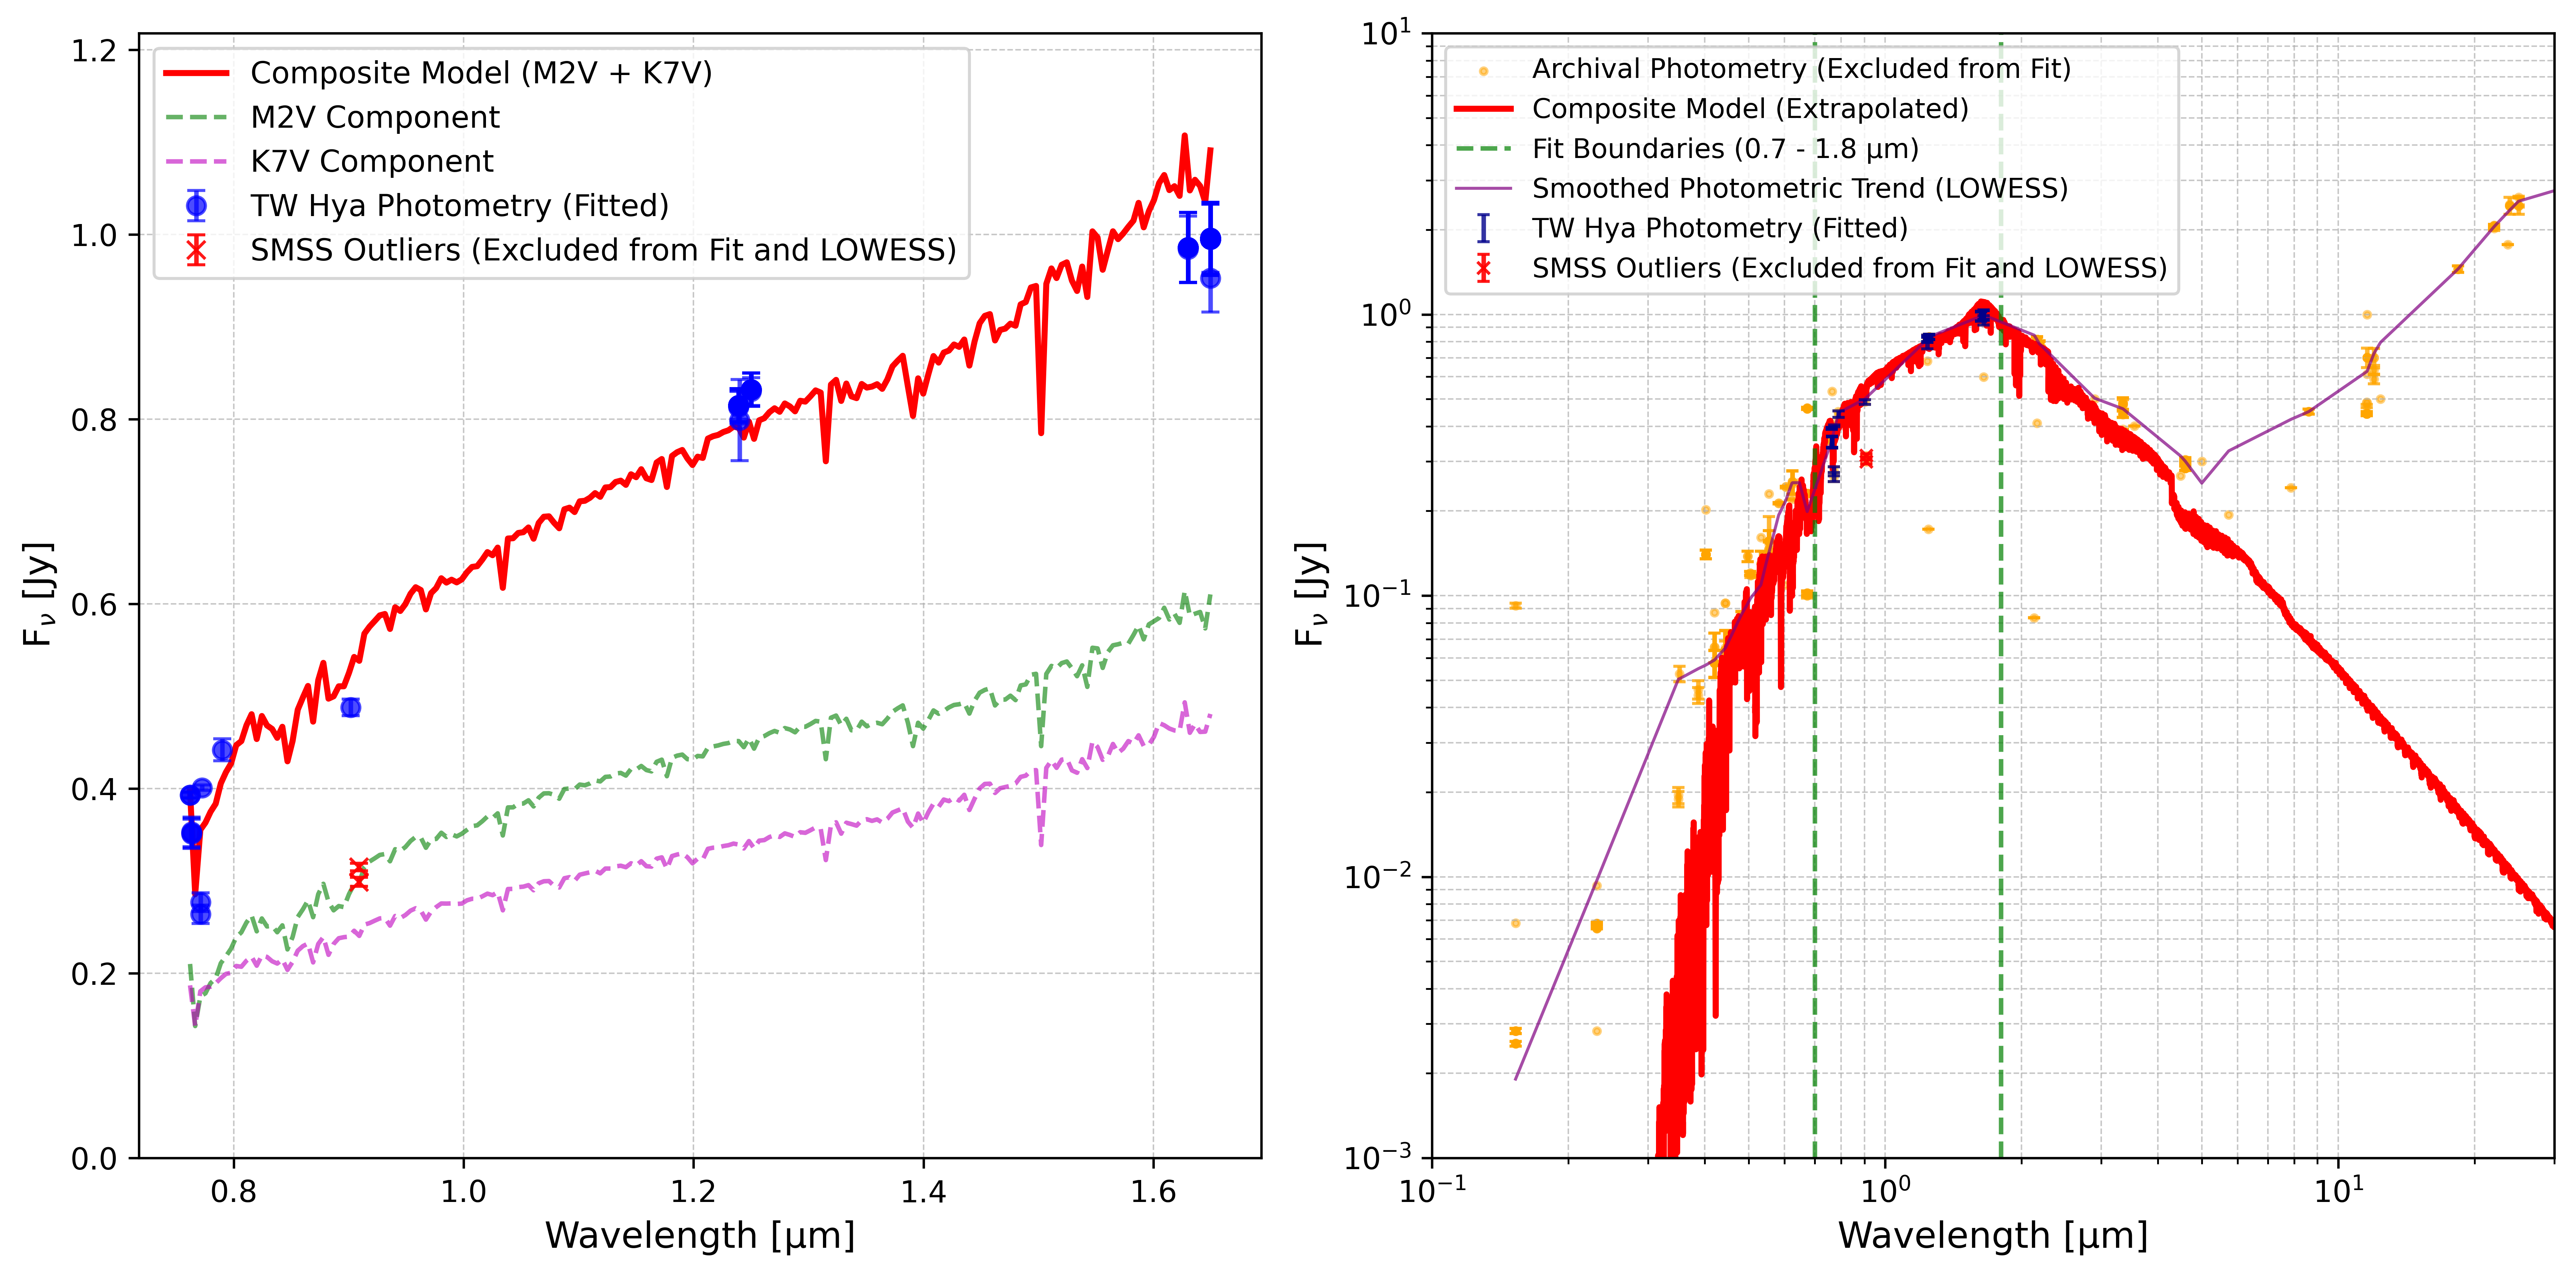

In [13]:
# --- Plot the fit ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

# Left plot: Fit region
ax1.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='blue', markersize=6, capsize=3, alpha=0.7,
             label='TW Hya Photometry (Fitted)', zorder=3)

# Outliers in red
if len(outlier_wl) > 0:
    ax1.errorbar(outlier_wl, outlier_flux, yerr=outlier_err, 
                 fmt='x', color='red', markersize=6, capsize=3, alpha=0.9,
                 label='SMSS Outliers (Excluded from Fit and LOWESS)', zorder=4)

wl_fit_fine = np.linspace(tw_hya_wl_fit.min(), tw_hya_wl_fit.max(), 200)
model_flux_fine = model(wl_fit_fine, scale_m2v, scale_k7v)
ax1.plot(wl_fit_fine, model_flux_fine, 'r-', linewidth=2, 
         label='Composite Model (M2V + K7V)', zorder=2)

ax1.plot(wl_fit_fine, model(wl_fit_fine, scale_m2v, 0), 'g--', alpha=0.6, label='M2V Component')
ax1.plot(wl_fit_fine, model(wl_fit_fine, 0, scale_k7v), 'm--', alpha=0.6, label='K7V Component')

ax1.set_xlabel('Wavelength [μm]', fontsize=12)
ax1.set_ylabel('F$_ν$ [Jy]', fontsize=12)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

max_flux_plot = max(tw_hya_flux_fit.max(), model_flux_fine.max())
ax1.set_ylim(0, max_flux_plot * 1.1)


# Right plot: Extended to longer wavelengths
ax2.scatter(star_vot["wavelength"], star_vot["sed_flux"],
            s=5, color='orange', alpha=0.5, label='Archival Photometry (Excluded from Fit)', zorder=1)
ax2.errorbar(star_vot["wavelength"], star_vot["sed_flux"], yerr=star_vot["sed_eflux"],
             linestyle="None", color='orange', markersize=0, capsize=2, alpha=0.8)

# Added label to the dark blue dots
ax2.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='darkblue', markersize=0, capsize=2, alpha=0.8, zorder=3,
             label='TW Hya Photometry (Fitted)')

# Add Outliers in red
if len(outlier_wl) > 0:
    ax2.errorbar(outlier_wl, outlier_flux, yerr=outlier_err, 
                 fmt='x', color='red', markersize=4, capsize=2, alpha=0.9, zorder=4, label='SMSS Outliers (Excluded from Fit and LOWESS)')

# Plot the extended fitted mixture spectrum
ax2.plot(wl_extended, fitted_flux_extended, 'r-', linewidth=2, 
         label='Composite Model (Extrapolated)', zorder=2)

# Removed the individual M2V/K7V dashed lines from the right plot to reduce clutter

# Add vertical lines at cutoff wavelength WITH a label
ax2.axvline(cut_off_wavelength_l, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Fit Boundaries (0.7 - 1.8 μm)')
ax2.axvline(cut_off_wavelength, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_xlabel('Wavelength [μm]', fontsize=12)
ax2.set_ylabel('F$_ν$ [Jy]', fontsize=12)

# Plot the LOWESS smoothed curve with cleaner label
ax2.plot(smoothed_x, smoothed_y, color='purple', linewidth=1,
         label='Smoothed Photometric Trend (LOWESS)', alpha=0.7)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-1, 3e1)
ax2.legend(fontsize=9, loc='best') # Slightly smaller font to accommodate new labels
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_ylim(0.001, 10)

plt.tight_layout()
plt.show()


Filter   Eff Wave   TW Hya [mJy]     Two-Component [mJy]  Resid [mJy]        Sig   
F200W    2.009        893.81±24.23      823.27±7.22        70.55±25.28      2.8σ
F356W    3.565        434.19±8.69       351.16±5.51        83.03±10.29      8.1σ
F444W    4.362        336.72±2.53       236.43±4.26       100.29±4.96      20.2σ


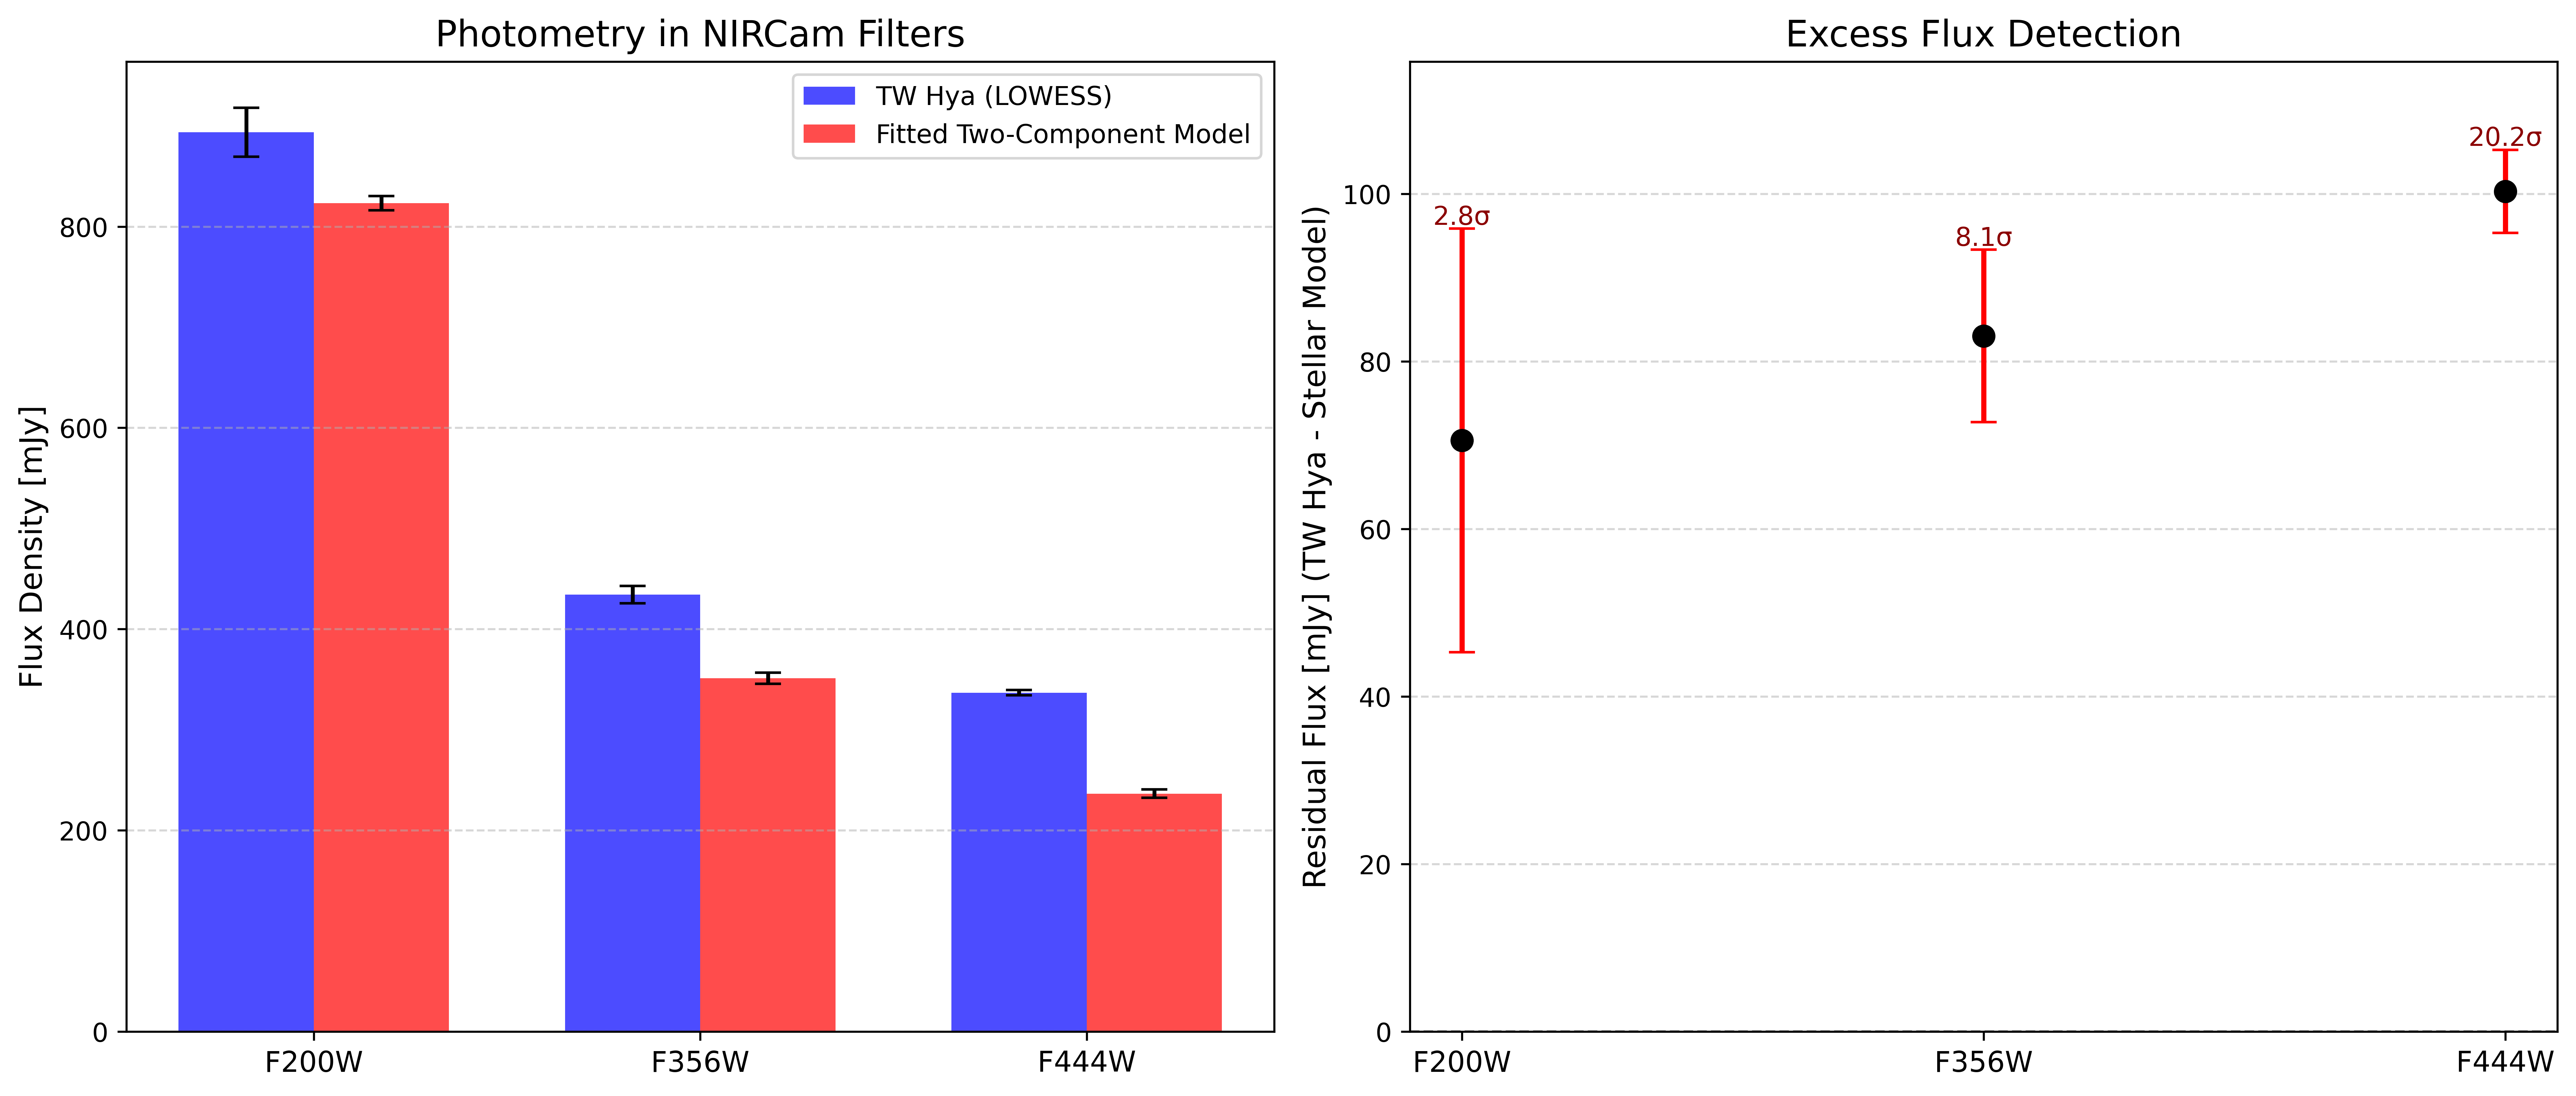

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import webbpsf_ext
from astropy import units as u

# --- 1. Setup Data for Synphot ---

# Clean TW Hya data for Synphot (remove duplicates)
unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
unique_smoothed_y = smoothed_y[unique_indices]

# Create Synphot Spectrum for TW Hya (Observed)
# unique_smoothed_x is in microns, unique_smoothed_y is in Jy
sp_twhya = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=unique_smoothed_x, 
    flux=unique_smoothed_y, 
    waveunits='um', 
    fluxunits='Jy'
)

# Create Synphot Spectrum for Fitted M0V (Model)
# Note: These are 'unit' spectra (scale=1.0) so we can scale them inside the loop
sp_m2v_unit = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=m2v_wavelength_microns, 
    flux=spectrum_flux_fnu_jy(m2v_interpolator, m2v_wavelength_microns), 
    waveunits='um', 
    fluxunits='Jy'
)

sp_k7v_unit = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=k7v_wavelength_microns, 
    flux=spectrum_flux_fnu_jy(k7v_interpolator, k7v_wavelength_microns), 
    waveunits='um', 
    fluxunits='Jy'
)


# --- 2. Define Filter List and Storage ---

bp_list = ['F200W', 'F356W', 'F444W']
filter_results = {
    'name': [],
    'wavelength': [],
    'twhya_flux': [],
    'twhya_err': [],
    'two_component_flux': [],
    'two_component_err': [],
    'residual': [],
    'resid_err': [],
    'sigma': []
}

print("\n" + "="*90)
print(f"{'Filter':<8} {'Eff Wave':<10} {'TW Hya [mJy]':<16} {'Two-Component [mJy]':<20} {'Resid [mJy]':<18} {'Sig':<6}")
print("="*90)

# --- 3. Loop Through Filters ---

for filt in bp_list:
    # Load Bandpass
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # Get Effective Wavelength (pivot) and Width (Rectangular approximation)
    eff_wave = bp.pivot().to(u.micron).value
    try:
        # Try to get rectangular width, fallback to approximation if needed
        bp_width = bp.rectwidth().to(u.micron).value
    except:
        bp_width = eff_wave * 0.15 # Fallback approximation
    
    # --- A. Calculate Integrated Fluxes (effstim) ---
    # Observe TW Hya
    obs_twhya = webbpsf_ext.synphot_ext.Observation(sp_twhya, bp)
    flux_twhya_jy = obs_twhya.effstim('Jy')
    
    # Observe individual templates (unit scale)
    f_m2v_filt = webbpsf_ext.synphot_ext.Observation(sp_m2v_unit, bp).effstim('Jy')
    f_k7v_filt = webbpsf_ext.synphot_ext.Observation(sp_k7v_unit, bp).effstim('Jy')
    
    # Combine to get total model flux: F = (a * T1) + (b * T2)
    flux_two_component_jy = (scale_m2v * f_m2v_filt) + (scale_k7v * f_k7v_filt)
    
    # --- B. Calculate Robust Errors for this Filter ---
    
    ## 1. Stellar Model Error (Propagated from fit)
    # sigma^2 = (T1^2 * var_a) + (T2^2 * var_b) + (2 * T1 * T2 * cov_ab)
    flux_two_component_err = np.sqrt(
        (f_m2v_filt**2 * var_m2v) + 
        (f_k7v_filt**2 * var_k7v) + 
        (2 * f_m2v_filt * f_k7v_filt * cov_m2v_k7v)
    )
    
    # 2. TW Hya Error Components
    # We look for data points within the "Rectangular Width" of the filter
    mask_band = np.abs(star_vot["wavelength"].value - eff_wave) < (bp_width / 2.0)
    flux_in_band = star_vot["sed_flux"].value[mask_band]
    err_in_band = star_vot["sed_eflux"].value[mask_band]
    # Filter valid points
    N = 0 # Number of valid points
    penalty = 0.0 # Penalty for no points in band
    valid = (err_in_band > 0) & (~np.isnan(flux_in_band))
    flux_filt = flux_in_band[valid]
    err_filt = err_in_band[valid]
        
    if len(flux_filt) > 1:
        pass
    else:
        N = 1
        # Fallback if < 2 points in band
        #print(f"Filter {filt}: Not enough data points in band for statistical error, using nearby points.")
        # Use nearest 20 points outside the band for error estimate
        all_flux = star_vot["sed_flux"].value
        all_err = star_vot["sed_eflux"].value
        all_wl = star_vot["wavelength"].value
        # Exclude points without valid errors
        valid_all = all_err > 0
        all_flux = all_flux[valid_all]
        all_err = all_err[valid_all]
        all_wl = all_wl[valid_all]
        # Find indices of nearest 20 points to eff_wave
        distances = np.abs(all_wl - eff_wave)
        nearest_indices = np.argsort(distances)[:10]
        if len(flux_filt) == 0:
            # If no points in band, penalty with the distance to the nearest point * slope
            wl_nearby = eff_wave * np.array([0.99, 1.01])
            # Evaluate the high-resolution native interpolators at the nearby wavelengths
            flux_m2v_nearby = spectrum_flux_fnu_jy(m2v_interpolator, wl_nearby)
            flux_k7v_nearby = spectrum_flux_fnu_jy(k7v_interpolator, wl_nearby)
            # Combine them using the fitted scaling factors
            flux_nearby = (scale_m2v * flux_m2v_nearby) + (scale_k7v * flux_k7v_nearby)
            # Calculate the gradient (slope) of the model spectrum at the effective wavelength
            gradient = np.abs(np.diff(flux_nearby)[0]) / (0.02 * eff_wave)
            penalty = gradient * np.min(distances)
        flux_filt = all_flux[nearest_indices]
        err_filt = all_err[nearest_indices]
    
    # Robust Scatter (MAD) to remove outliers inside the band
    median_f = np.nanmedian(flux_filt)
    mad = np.nanmedian(np.abs(flux_filt - median_f))
    if mad > 0:
        not_outlier = np.abs(flux_filt - median_f) < 3.0 * 1.4826 * mad
        flux_clean = flux_filt[not_outlier]
        err_clean = err_filt[not_outlier]
    else:
        flux_clean, err_clean = flux_filt, err_filt
        
    if N == 0:
        N = len(flux_clean)
    #print(f"Filter {filt}: Found {N} valid data points in band for statistical error calculation.")
    # Standard Error of the Mean (Scatter / sqrt(N))
    sem_scatter = np.std(flux_clean, ddof=1) / np.sqrt(N) if N > 1 else 0
    sem_meas = np.nanmedian(err_clean) / np.sqrt(N) if N > 0 else 0
    flux_twhya_err = np.sqrt(max(sem_scatter, sem_meas)**2 + penalty**2)


    # --- C. Calculate Residuals ---
    residual = flux_twhya_jy - flux_two_component_jy
    resid_err = np.sqrt(flux_twhya_err**2 + flux_two_component_err**2)
    sigma = residual / resid_err if resid_err > 0 else 0
    
    # Store Data
    filter_results['name'].append(filt)
    filter_results['wavelength'].append(eff_wave)
    filter_results['twhya_flux'].append(flux_twhya_jy)
    filter_results['twhya_err'].append(flux_twhya_err)
    filter_results['two_component_flux'].append(flux_two_component_jy)
    filter_results['two_component_err'].append(flux_two_component_err)
    filter_results['residual'].append(residual)
    filter_results['resid_err'].append(resid_err)
    filter_results['sigma'].append(sigma)
    
    print(f"{filt:<8} {eff_wave:<10.3f} {flux_twhya_jy*1000:>8.2f}±{flux_twhya_err*1000:<8.2f} "
          f"{flux_two_component_jy*1000:>8.2f}±{flux_two_component_err*1000:<8.2f} "
          f"{residual*1000:>8.2f}±{resid_err*1000:<8.2f} {sigma:>5.1f}σ")

print("="*90)

# --- 4. Plotting the Results ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=600)

# X-axis setup
x_pos = np.arange(len(bp_list))
labels = filter_results['name']

# --- PLOT 1: Flux Comparison (Bar Chart) ---
width = 0.35
ax1.bar(x_pos - width/2, np.array(filter_results['twhya_flux'])*1000, width, 
        yerr=np.array(filter_results['twhya_err'])*1000, capsize=5, 
        label='TW Hya (LOWESS)', color='blue', alpha=0.7)

ax1.bar(x_pos + width/2, np.array(filter_results['two_component_flux'])*1000, width, 
        yerr=np.array(filter_results['two_component_err'])*1000, capsize=5, 
        label='Fitted Two-Component Model', color='red', alpha=0.7)

ax1.set_ylabel('Flux Density [mJy]', fontsize=12)
ax1.set_title('Photometry in NIRCam Filters', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT 2: Residuals (Scatter with Error Bars) ---
# Convert to mJy for easier reading
y_res = np.array(filter_results['residual']) * 1000
y_err = np.array(filter_results['resid_err']) * 1000

ax2.errorbar(x_pos, y_res, yerr=y_err, fmt='o', color='k', 
             ecolor='red', elinewidth=2, capsize=5, markersize=8, label='Residual')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add text annotations for Sigma
for i, sig in enumerate(filter_results['sigma']):
    ax2.annotate(f'{sig:.1f}σ', (x_pos[i], y_res[i] + y_err[i] + 0.5), 
                 ha='center', color='darkred', fontsize=10)

ax2.set_ylabel('Residual Flux [mJy] (TW Hya - Stellar Model)', fontsize=12)
ax2.set_title('Excess Flux Detection', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, max(y_res + y_err) * 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Computing bandpass-integrated blackbody grid...

Single-temperature blackbody fit to the excess flux
Best-fit temperature: 1227 K (-218, +218 K)
Minimum chi-square: 3.002
Degrees of freedom: 1
Reduced chi-square: 3.002

At 1200 K: chi-square = 3.010, Delta chi-square = 0.007

Bandpass-integrated flux comparison:
Filter      Observed excess [mJy]       Best-fit BB [mJy]    Residual / sigma
F200W          70.55 ± 25.28                  40.22                1.20
F356W          83.03 ± 10.29                  95.04               -1.17
F444W         100.29 ± 4.96                   98.07                0.45


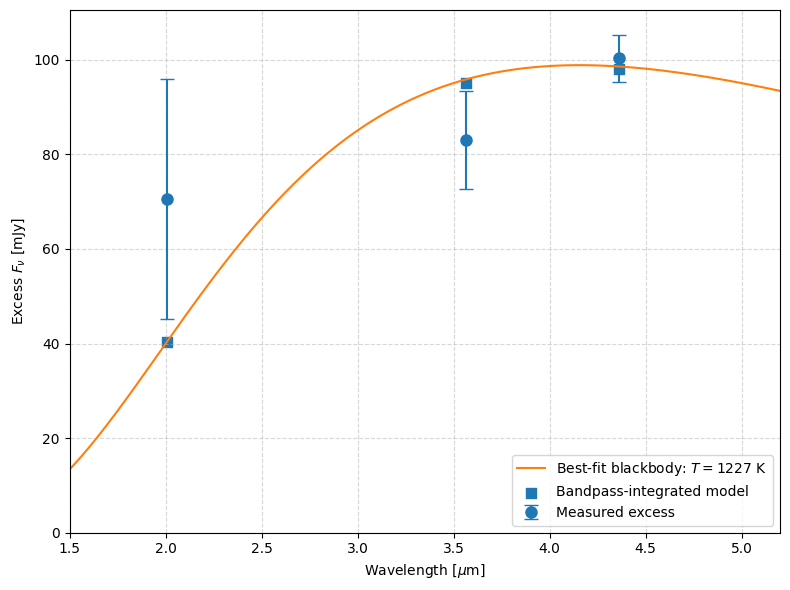

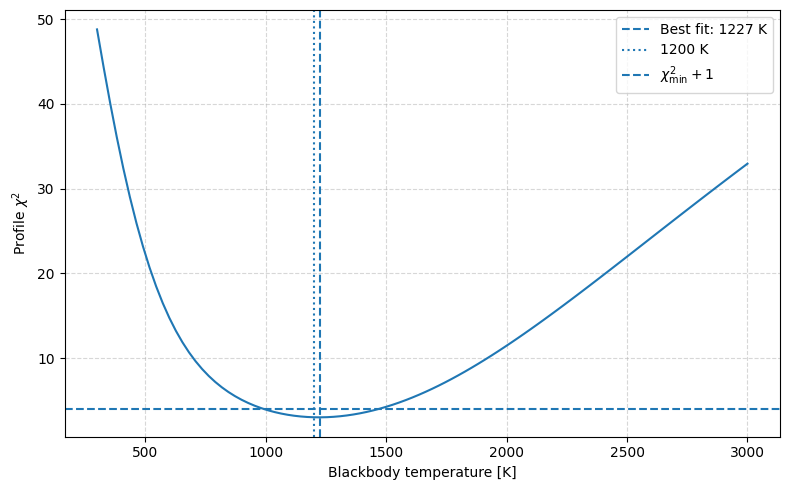

In [18]:
# ============================================================
# Fit a single-temperature blackbody to the excess fluxes
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from astropy.constants import h, c, k_B


# ------------------------------------------------------------
# 1. Observed excess fluxes and uncertainties
# ------------------------------------------------------------

filters = np.asarray(filter_results["name"])
eff_wavelengths = np.asarray(filter_results["wavelength"], dtype=float)  # micron
excess_fluxes = np.asarray(filter_results["residual"], dtype=float)     # Jy
excess_errors = np.asarray(filter_results["resid_err"], dtype=float)    # Jy

valid = (
    np.isfinite(excess_fluxes)
    & np.isfinite(excess_errors)
    & (excess_errors > 0)
)

filters = filters[valid]
eff_wavelengths = eff_wavelengths[valid]
excess_fluxes = excess_fluxes[valid]
excess_errors = excess_errors[valid]

if len(excess_fluxes) < 3:
    raise ValueError("At least three valid excess measurements are required.")


# ------------------------------------------------------------
# 2. Reuse the same NIRCam bandpasses
# ------------------------------------------------------------

bandpasses = {
    filt: webbpsf_ext.nircam_filter(
        filt,
        pupil="CIRCLYOT",
        mask="MASK335R",
        module="A",
    )
    for filt in filters
}


# ------------------------------------------------------------
# 3. Define the blackbody F_nu spectral shape
# ------------------------------------------------------------

# This range safely covers F200W, F356W, and F444W.
bb_wave_um = np.geomspace(0.5, 8.0, 5000)


def blackbody_fnu_shape(wavelength_um, temperature):
    """
    Return the shape of B_nu(T), normalized to a maximum of 1.

    Parameters
    ----------
    wavelength_um : array-like
        Wavelength in microns.
    temperature : float
        Blackbody temperature in kelvin.
    """
    wavelength_m = np.asarray(wavelength_um, dtype=float) * 1e-6
    frequency_hz = c.value / wavelength_m

    exponent = h.value * frequency_hz / (k_B.value * temperature)

    # B_nu in SI units. The absolute units do not matter because
    # the fitted amplitude absorbs the normalization.
    bnu = (
        2.0 * h.value * frequency_hz**3 / c.value**2
    ) / np.expm1(exponent)

    return bnu / np.nanmax(bnu)


def quantity_to_float(value):
    """Return the numerical value from either a Quantity or a float."""
    return float(value.value) if hasattr(value, "value") else float(value)


def bandpass_blackbody_fluxes(temperature):
    """
    Calculate the relative blackbody flux density in each NIRCam filter.

    The resulting values correspond to a unit-normalized blackbody
    spectrum. A free amplitude is fitted separately.
    """
    shape = blackbody_fnu_shape(bb_wave_um, temperature)

    spectrum = webbpsf_ext.synphot_ext.ArraySpectrum(
        wave=bb_wave_um,
        flux=shape,
        waveunits="um",
        fluxunits="Jy",
    )

    model_fluxes = []

    for filt in filters:
        obs = webbpsf_ext.synphot_ext.Observation(
            spectrum,
            bandpasses[filt],
        )
        model_fluxes.append(
            quantity_to_float(obs.effstim("Jy"))
        )

    return np.asarray(model_fluxes)


# ------------------------------------------------------------
# 4. Profile over temperature
#
# For each temperature, solve analytically for the best amplitude:
#
# A = sum(y_i m_i / sigma_i^2) / sum(m_i^2 / sigma_i^2)
# ------------------------------------------------------------

temperature_grid = np.linspace(300.0, 3000.0, 100)

print("Computing bandpass-integrated blackbody grid...")

blackbody_grid = np.vstack([
    bandpass_blackbody_fluxes(temperature)
    for temperature in temperature_grid
])

weights = 1.0 / excess_errors**2

amplitude_grid = np.sum(
    weights[None, :] * excess_fluxes[None, :] * blackbody_grid,
    axis=1,
) / np.sum(
    weights[None, :] * blackbody_grid**2,
    axis=1,
)

# Do not permit an unphysical negative blackbody amplitude.
amplitude_grid = np.maximum(amplitude_grid, 0.0)

predicted_grid = amplitude_grid[:, None] * blackbody_grid

chi2_grid = np.sum(
    ((excess_fluxes[None, :] - predicted_grid)
     / excess_errors[None, :])**2,
    axis=1,
)


# ------------------------------------------------------------
# 5. Best fit and profile-likelihood uncertainty
# ------------------------------------------------------------

best_index = np.argmin(chi2_grid)

best_temperature = temperature_grid[best_index]
best_amplitude = amplitude_grid[best_index]
best_model_fluxes = predicted_grid[best_index]
minimum_chi2 = chi2_grid[best_index]

n_data = len(excess_fluxes)
n_parameters = 2  # temperature and amplitude
degrees_of_freedom = n_data - n_parameters

# For one parameter of interest, Delta chi^2 = 1 approximates
# a 68% confidence interval after profiling over amplitude.
inside_1sigma = chi2_grid <= minimum_chi2 + 1.0

if np.any(inside_1sigma):
    temperature_lower = temperature_grid[inside_1sigma][0]
    temperature_upper = temperature_grid[inside_1sigma][-1]
else:
    temperature_lower = np.nan
    temperature_upper = np.nan


# ------------------------------------------------------------
# 6. Compare explicitly with a 1200 K blackbody
# ------------------------------------------------------------

temperature_reference = 1200.0
model_1200 = bandpass_blackbody_fluxes(temperature_reference)

amplitude_1200 = np.sum(
    weights * excess_fluxes * model_1200
) / np.sum(
    weights * model_1200**2
)

amplitude_1200 = max(amplitude_1200, 0.0)

predicted_1200 = amplitude_1200 * model_1200

chi2_1200 = np.sum(
    ((excess_fluxes - predicted_1200) / excess_errors)**2
)

delta_chi2_1200 = chi2_1200 - minimum_chi2


# ------------------------------------------------------------
# 7. Print the fit results
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("Single-temperature blackbody fit to the excess flux")
print("=" * 72)

print(
    f"Best-fit temperature: "
    f"{best_temperature:.0f} K "
    f"(-{best_temperature - temperature_lower:.0f}, "
    f"+{temperature_upper - best_temperature:.0f} K)"
)

print(f"Minimum chi-square: {minimum_chi2:.3f}")
print(f"Degrees of freedom: {degrees_of_freedom}")

if degrees_of_freedom > 0:
    print(
        f"Reduced chi-square: "
        f"{minimum_chi2 / degrees_of_freedom:.3f}"
    )

print(
    f"\nAt 1200 K: chi-square = {chi2_1200:.3f}, "
    f"Delta chi-square = {delta_chi2_1200:.3f}"
)

print("\nBandpass-integrated flux comparison:")
print(
    f"{'Filter':<8}"
    f"{'Observed excess [mJy]':>25}"
    f"{'Best-fit BB [mJy]':>24}"
    f"{'Residual / sigma':>20}"
)

for filt, observed, error, modeled in zip(
    filters,
    excess_fluxes,
    excess_errors,
    best_model_fluxes,
):
    standardized_residual = (observed - modeled) / error

    print(
        f"{filt:<8}"
        f"{observed * 1000:>12.2f} ± {error * 1000:<8.2f}"
        f"{modeled * 1000:>20.2f}"
        f"{standardized_residual:>20.2f}"
    )

print("=" * 72)


# ------------------------------------------------------------
# 8. Plot the best-fitting blackbody
# ------------------------------------------------------------

best_shape = blackbody_fnu_shape(
    bb_wave_um,
    best_temperature,
)
best_continuous_spectrum = best_amplitude * best_shape

plt.figure(figsize=(8, 6))

plt.errorbar(
    eff_wavelengths,
    excess_fluxes * 1000,
    yerr=excess_errors * 1000,
    fmt="o",
    capsize=5,
    markersize=8,
    label="Measured excess",
)

plt.plot(
    bb_wave_um,
    best_continuous_spectrum * 1000,
    linewidth=1.5,
    label=fr"Best-fit blackbody: $T={best_temperature:.0f}$ K",
)

plt.scatter(
    eff_wavelengths,
    best_model_fluxes * 1000,
    marker="s",
    s=55,
    label="Bandpass-integrated model",
)

plt.xlabel(r"Wavelength [$\mu$m]")
plt.ylabel(r"Excess $F_\nu$ [mJy]")
plt.xlim(1.5, 5.2)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Plot chi-square versus temperature
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    temperature_grid,
    chi2_grid,
    linewidth=1.5,
)

plt.axvline(
    best_temperature,
    linestyle="--",
    label=fr"Best fit: {best_temperature:.0f} K",
)

plt.axvline(
    1200,
    linestyle=":",
    label="1200 K",
)

plt.axhline(
    minimum_chi2 + 1.0,
    linestyle="--",
    label=r"$\chi^2_{\min}+1$",
)

plt.xlabel("Blackbody temperature [K]")
plt.ylabel(r"Profile $\chi^2$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Export the fitted two component spectrum to a votable like the original TW Hya votable
fitted_table = Table()
fitted_table['wavelength'] = wl_extended * u.micron
fitted_table['sed_freq'] = (const.c / (wl_extended * u.micron)).to(u.GHz)
fitted_table['sed_flux'] = fitted_flux_extended * u.Jy
# 1. Get the individual template fluxes at the extended wavelengths (F_nu in Jy)
fnu_m2v_ext = spectrum_flux_fnu_jy(m2v_interpolator, wl_extended)
fnu_k7v_ext = spectrum_flux_fnu_jy(k7v_interpolator, wl_extended)

# 2. Propagate error using the variance-covariance formula:
# sigma_total = sqrt( (T1^2 * var1) + (T2^2 * var2) + (2 * T1 * T2 * cov12) )
sed_eflux_val = np.sqrt(
    (fnu_m2v_ext * scale_m2v_err)**2 + 
    (fnu_k7v_ext * scale_k7v_err)**2 + 
    (2 * fnu_m2v_ext * fnu_k7v_ext * cov_m2v_k7v)
)
fitted_table['sed_eflux'] = sed_eflux_val * u.Jy
fitted_table.write('fitted_two_component_TWHya.vot', format='votable', overwrite=True)
print("Fitted TW Hya spectrum exported to 'fitted_two_component_TWHya.vot'")

Fitted TW Hya spectrum exported to 'fitted_two_component_TWHya.vot'


In [17]:
# Compare the single-component M0V fit to the two-component M2V+K7V fit using F-test
from scipy.stats import f
# Calculate the F-statistic
numerator = (single_component_chi_squared - two_component_chi_squared) / (2 - 1)
denominator = two_component_chi_squared / two_component_dof
F_statistic = numerator / denominator
# Calculate the p-value
p_value = 1 - f.cdf(F_statistic, dfn=2 - 1, dfd=two_component_dof)
print(f"\nModel Comparison (F-test):")
print(f"F-statistic: {F_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretation of F-test results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("The two-component M2V+K7V model provides a statistically significant improvement over the single-component M0V model.")
else:
    print("The two-component M2V+K7V model does NOT provide a statistically significant improvement over the single-component M0V model.")


Model Comparison (F-test):
F-statistic: 13.8201
P-value: 4.1693e-04
The two-component M2V+K7V model provides a statistically significant improvement over the single-component M0V model.


In [18]:
# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # 1. TW Hya System Flux Density
    unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
    unique_smoothed_y = smoothed_y[unique_indices]
    sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=unique_smoothed_x, flux=unique_smoothed_y, waveunits='um', fluxunits='Jy')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp)
    print(f"{filt} TW Hya System Flux Density: {obs.effstim('Jy'):.3f} Jy")
    
    # 2. Stellar Flux Density (Using the method from your first block)
    # Get the unit flux for each component in this filter
    f_m2v_filt = webbpsf_ext.synphot_ext.Observation(sp_m2v_unit, bp).effstim('Jy')
    f_k7v_filt = webbpsf_ext.synphot_ext.Observation(sp_k7v_unit, bp).effstim('Jy')
    
    # Scale and combine
    stellar_flux_density = (scale_m2v * f_m2v_filt) + (scale_k7v * f_k7v_filt)
    print(f"{filt} Stellar Flux Density: {stellar_flux_density:.3f} Jy\n")

F200W TW Hya System Flux Density: 0.894 Jy
F200W Stellar Flux Density: 0.823 Jy

F356W TW Hya System Flux Density: 0.434 Jy
F356W Stellar Flux Density: 0.351 Jy

F444W TW Hya System Flux Density: 0.337 Jy
F444W Stellar Flux Density: 0.236 Jy



# Photometry of TW Hya with JWST data

### Loading FITS files and preparing data for photometry

In [19]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import map_coordinates

# Load the F200W, F356W, and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F356W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
headers = [hdul[0].header for hdul in hduls]
pixel_scales = [header['PIXSCALE'] for header in headers]
data = [hdul[0].data for hdul in hduls]
hpfrdi_images = [d[:,:,1] for d in data]
deconv_images = [d[:,:,0] for d in data]

### Variance vs Mean Intensity in Rings for F200W, used for geometric fitting

Fitted line: y = 0.2375$x^2$ + 0.2028x + -1.0201, $R^2$ = 0.98
Coefficients: 0.23745102230324, 0.20276344663137, -1.02007986310495


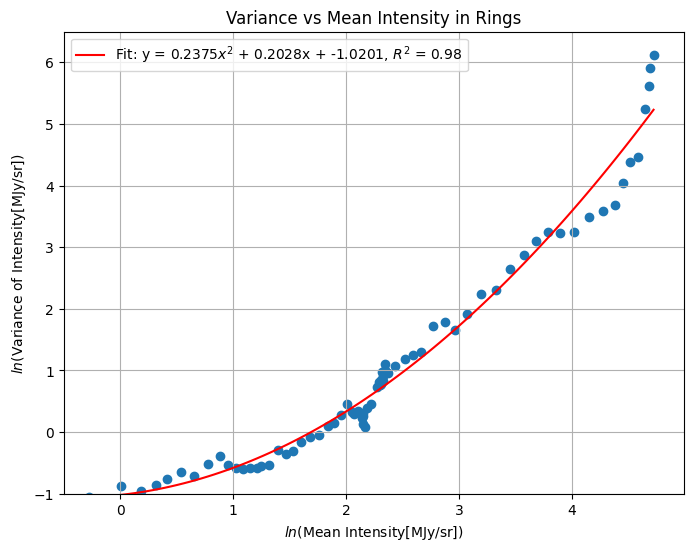

In [20]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# Load the F200W and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
data = [hdul[0].data for hdul in hduls]
images = [d[:,:,0] for d in data]
image_f200w = images[0]

# make a ring clipping mask
r_in = 22  # inner radius in pixels
r_out = 97  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels
rings = [[] for _ in range(r_in, r_out)]
for x,y in np.ndindex(image_f200w.shape):
    r = np.sqrt((x-x_center)**2 + (y-y_center)**2)
    if r_in <= r <= r_out:
        #print(r, int(r)-r_in)
        rings[int(r)-r_in].append(image_f200w[x,y])

# calculate the mean value and var of each ring
ring_means = [np.mean(ring) for ring in rings]
ring_vars = [np.var(ring, ddof=1) for ring in rings]
ring_means_log = np.log(ring_means)
ring_vars_log = np.log(ring_vars)

# Fit a line to the data
coefficients = np.polyfit(ring_means_log, ring_vars_log, 2)
polynomial = np.poly1d(coefficients)
R_squared = 1 - (np.sum((ring_vars_log - polynomial(ring_means_log))**2) / np.sum((ring_vars_log - np.mean(ring_vars_log))**2))
print(f"Fitted line: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}")
# print the coefficients in high precision
print(f"Coefficients: {coefficients[0]:.14f}, {coefficients[1]:.14f}, {coefficients[2]:.14f}")

# Create a scatter plot of var vs mean
plt.figure(figsize=(8, 6))
plt.scatter(ring_means_log, ring_vars_log)
# Plot the fitted line
x_fit = np.linspace(min(ring_means_log), max(ring_means_log), 100)
y_fit = polynomial(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}')
plt.legend()
plt.xlabel(f'$ln$(Mean Intensity[MJy/sr])')
plt.ylabel(f'$ln$(Variance of Intensity[MJy/sr])')
plt.title('Variance vs Mean Intensity in Rings')
plt.grid(True)
plt.xlim(-0.5,)
plt.ylim(-1,)
plt.show()

Fitted line: y = 0.5468$x^2$ + 0.2028x + -0.4430, $R^2$ = 0.98
Coefficients: 0.54675111777099, 0.20276353330016, -0.44301507597909


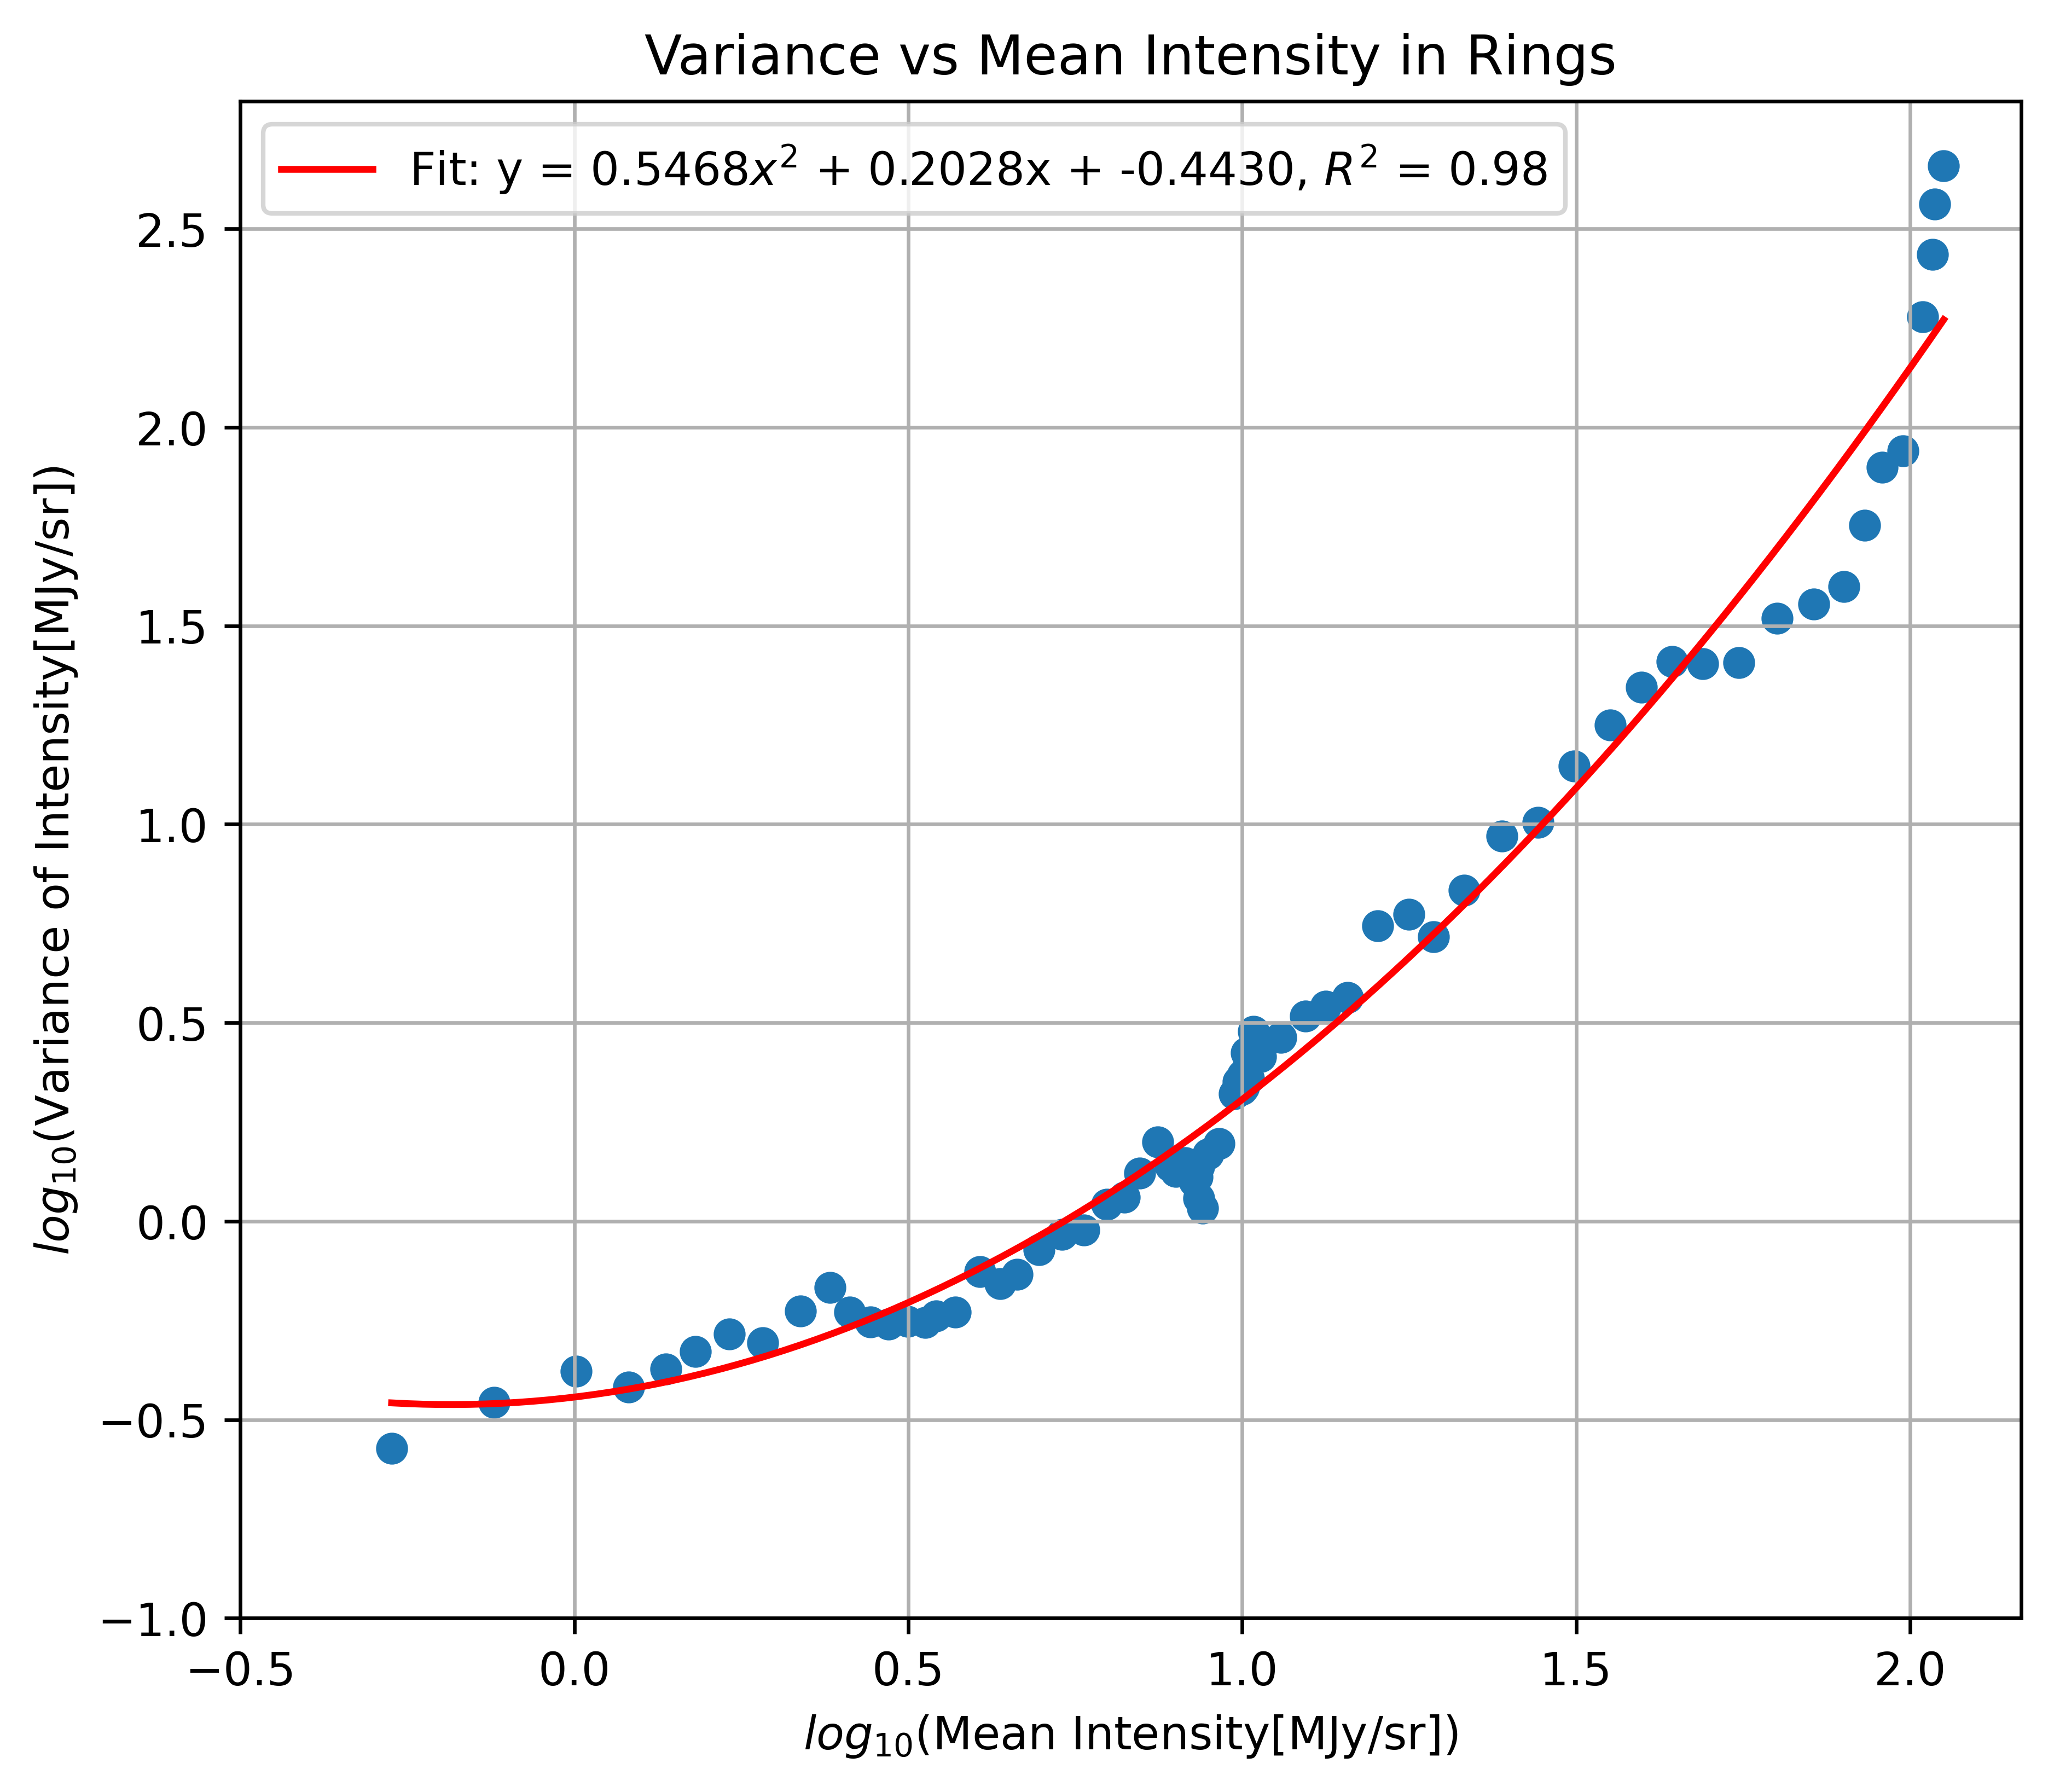

In [21]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# Load the F200W and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
data = [hdul[0].data for hdul in hduls]
images = [d[:,:,0] for d in data]
image_f200w = images[0]

# make a ring clipping mask
r_in = 22  # inner radius in pixels
r_out = 97  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels
rings = [[] for _ in range(r_in, r_out)]
for x,y in np.ndindex(image_f200w.shape):
    r = np.sqrt((x-x_center)**2 + (y-y_center)**2)
    if r_in <= r <= r_out:
        #print(r, int(r)-r_in)
        rings[int(r)-r_in].append(image_f200w[x,y])

# calculate the mean value and var of each ring
ring_means = [np.mean(ring) for ring in rings]
ring_vars = [np.var(ring, ddof=1) for ring in rings]
ring_means_log = np.log10(ring_means)
ring_vars_log = np.log10(ring_vars)

# Fit a line to the data
coefficients = np.polyfit(ring_means_log, ring_vars_log, 2)
polynomial = np.poly1d(coefficients)
R_squared = 1 - (np.sum((ring_vars_log - polynomial(ring_means_log))**2) / np.sum((ring_vars_log - np.mean(ring_vars_log))**2))
print(f"Fitted line: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}")
# print the coefficients in high precision
print(f"Coefficients: {coefficients[0]:.14f}, {coefficients[1]:.14f}, {coefficients[2]:.14f}")

# Create a scatter plot of var vs mean
plt.figure(figsize=(7, 6), dpi=600)
plt.scatter(ring_means_log, ring_vars_log)
# Plot the fitted line
x_fit = np.linspace(min(ring_means_log), max(ring_means_log), 100)
y_fit = polynomial(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}')
plt.legend()
plt.xlabel(f'$log_{{10}}$(Mean Intensity[MJy/sr])')
plt.ylabel(f'$log_{{10}}$(Variance of Intensity[MJy/sr])')
plt.title('Variance vs Mean Intensity in Rings')
plt.grid(True)
plt.xlim(-0.5,)
plt.ylim(-1,)
plt.show()

### Photometry with Bootstrap Uncertainty Estimation (Python Version)
see Photometry_rust.ipynb for the Rust version, which is much faster. The Python version is kept here for reference and comparison.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Setting for a ring clipping mask
r_in = [0,0,0,0]  # inner radius in pixels
max_radius = int(325*np.sqrt(2))  # maximum radius in pixels (diagonal of the image)
r_out = [max_radius,max_radius,max_radius,max_radius]  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels

# Constant
conversion_factor = 2.3504e-2 # mJy/arcsec^2 per MJy/sr

# --- Bootstrap analysis ---
def bootstrap_photometry(images, headers, pixel_scales, n_bootstrap, deconv=False, error_profs=None):
    """
    Performs bootstrap photometry on a list of images.
    """
    bootstrap_fluxes = np.empty(len(images))
    bootstrap_efluxes = np.empty(len(images))
    for i, (image, header, pixel_scale) in enumerate(zip(images, headers, pixel_scales)):
        start_time = time.time()
        if 'filter' in header:
            print(f"Filter: {header['filter']}")
        # 1. Vectorized Grid and Radius Calculation
        ny, nx = image.shape
        y_indices, x_indices = np.mgrid[:ny, :nx]
        radii = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)

        # 2. Pixel Grouping into Rings
        # Create a mask for pixels within the desired radial range and that are not NaN
        valid_mask = (radii >= r_in[i]) & (radii < r_out[i]) & ~np.isnan(image)
        
        # Get the pixel values and their corresponding integer ring number
        valid_pixels = image[valid_mask]
        valid_radii_integers = radii[valid_mask].astype(int)

        # Get unique ring numbers and the indices to reconstruct them
        unique_rings, ring_indices = np.unique(valid_radii_integers, return_inverse=True)
        
        # 3. Vectorized Bootstrap Resampling
        # Create an array to store the sum of each bootstrap sample
        bootstrap_sums = np.zeros(n_bootstrap)
        
        # Loop through each ring, perform bootstrap on its pixels, and add to total
        for ring_num in unique_rings:
            # Find all pixels that belong to the current ring
            pixels_in_ring = valid_pixels[valid_radii_integers == ring_num]
            n_pixels = len(pixels_in_ring)
            if n_pixels == 0:
                continue

            # Generate all bootstrap samples for this ring in one go
            # Shape: (n_pixels_in_ring, n_bootstrap)
            resampled_indices = np.random.randint(0, n_pixels, size=(n_pixels, n_bootstrap))
            resampled_pixels = pixels_in_ring[resampled_indices]
            
            # Sum each bootstrap column and add it to our running total
            if deconv:
                try: 
                    ring_flux_fractional_error = min(error_profs[i][ring_num-r_in[i]],1.0) # if the error is larger than 1, we can only say the true flux is between 0 and 2 times the measured flux, so we set the lower bound to 0 and upper bound to 2 times the measured flux
                except:
                    ring_flux_fractional_error = 1.0
                # Assume the error is uniformly distributed
                # f is chosen uniformly between -ring_flux_fractional_error and +ring_flux_fractional_error
                f = ring_flux_fractional_error*np.random.uniform(-1, 1, size=n_bootstrap)
                # the true flux is then measured flux * (1+f)
                bootstrap_sums += np.sum(resampled_pixels, axis=0) * (1+f)
                
            else:
                bootstrap_sums += np.sum(resampled_pixels, axis=0)

        # 4. Final Flux Calculation
        total_fluxes_bootstrap = bootstrap_sums * (pixel_scale**2) * conversion_factor

        # --- Analysis and Plotting ---
        mean_flux = np.mean(total_fluxes_bootstrap)
        std_flux = np.std(total_fluxes_bootstrap)
        
        end_time = time.time()
        print(f"Processing took: {end_time - start_time:.4f} seconds")
        print(f"Mean Total Flux: {mean_flux:.6f} mJy")
        print(f"Standard Deviation of Total Flux: {std_flux:.6f} mJy")
        
        plt.figure(figsize=(8, 6))
        plt.hist(total_fluxes_bootstrap, bins=100, density=True, alpha=0.7, label=f'Filter {header["filter"]}')
        #plt.title(f'Bootstrap Distribution of Total Brightness - Filter {header["filter"]}')
        plt.xlabel('Total Flux (mJy)')
        plt.ylabel('Probability Density')
        plt.axvline(mean_flux, color='r', linestyle='--', label=f'Mean: {mean_flux:.2f} mJy')
        plt.legend()
        plt.grid(True)
        plt.show()
        bootstrap_fluxes[i] = mean_flux
        bootstrap_efluxes[i] = std_flux
    return bootstrap_fluxes, bootstrap_efluxes


HPFRDI Images Photometry
Filter: F200W
Processing took: 6.3211 seconds
Mean Total Flux: 8.259374 mJy
Standard Deviation of Total Flux: 0.003975 mJy


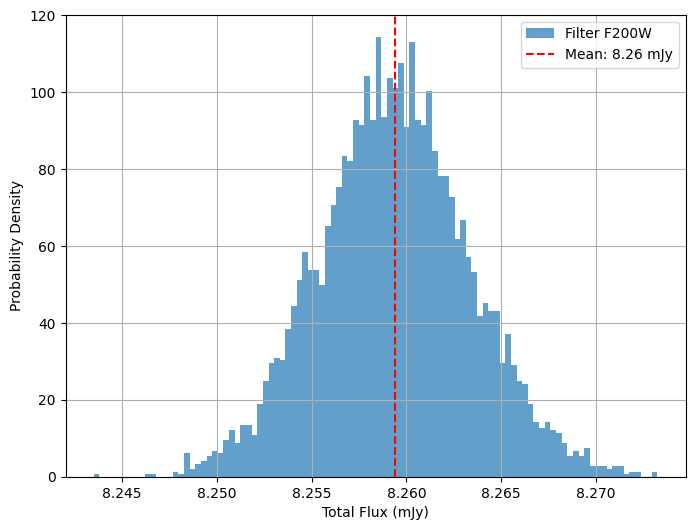

Filter: F356W
Processing took: 6.2948 seconds
Mean Total Flux: 2.188695 mJy
Standard Deviation of Total Flux: 0.004171 mJy


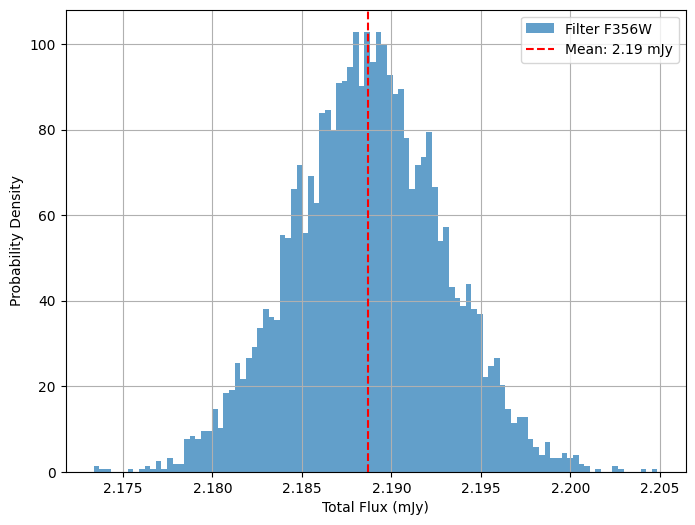

Filter: F444W
Processing took: 6.2905 seconds
Mean Total Flux: 1.166676 mJy
Standard Deviation of Total Flux: 0.005980 mJy


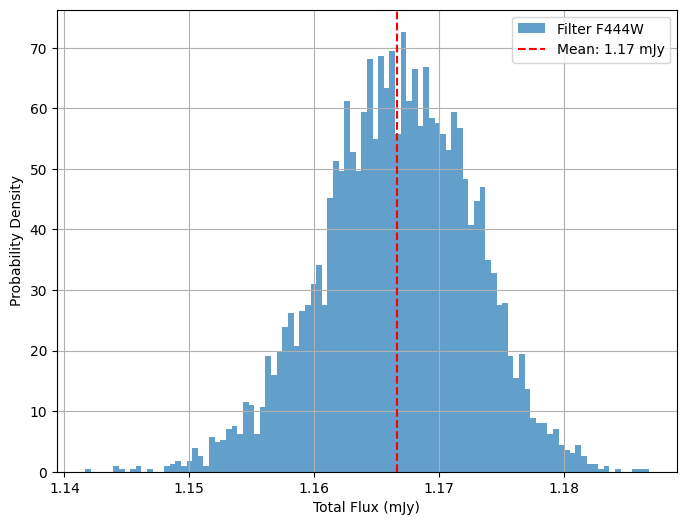

In [23]:
# Number of bootstrap samples 
n_bootstrap = 5000 # Number of bootstrap samples

# HPFRDI Images Photometry
print("HPFRDI Images Photometry")
hpfrdi_fluxes = np.empty(len(hpfrdi_images))
hpfrdi_efluxes = np.empty(len(hpfrdi_images))
hpfrdi_fluxes, hpfrdi_efluxes = bootstrap_photometry(hpfrdi_images, headers, pixel_scales, n_bootstrap, deconv=False)

Deconvolved Images Photometry
Processing filter: F200W
Processing filter: F356W
Processing filter: F444W
Filter: F200W


Processing took: 6.3013 seconds
Mean Total Flux: 20.110371 mJy
Standard Deviation of Total Flux: 1.138519 mJy


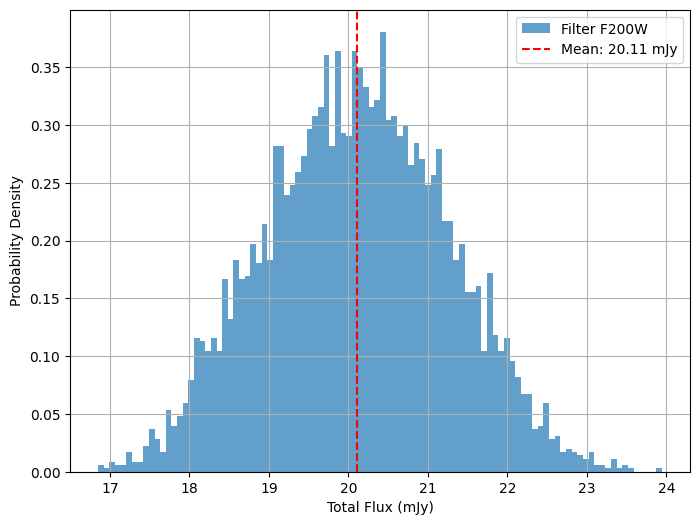

Filter: F356W
Processing took: 6.2995 seconds
Mean Total Flux: 3.422137 mJy
Standard Deviation of Total Flux: 0.100679 mJy


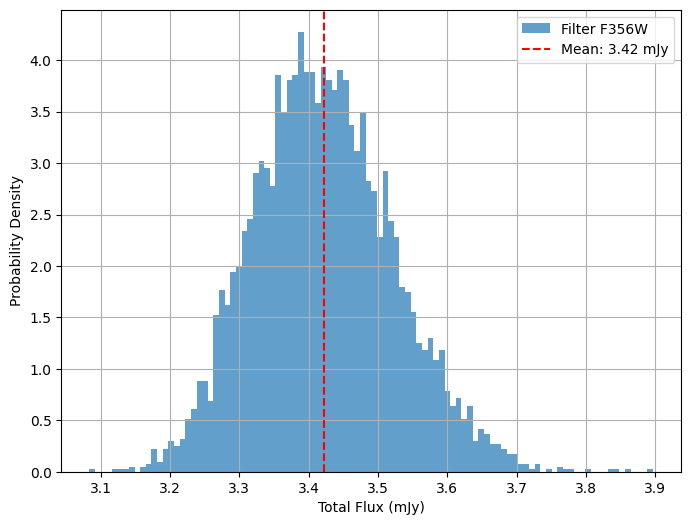

Filter: F444W
Processing took: 6.2981 seconds
Mean Total Flux: 2.721786 mJy
Standard Deviation of Total Flux: 0.219748 mJy


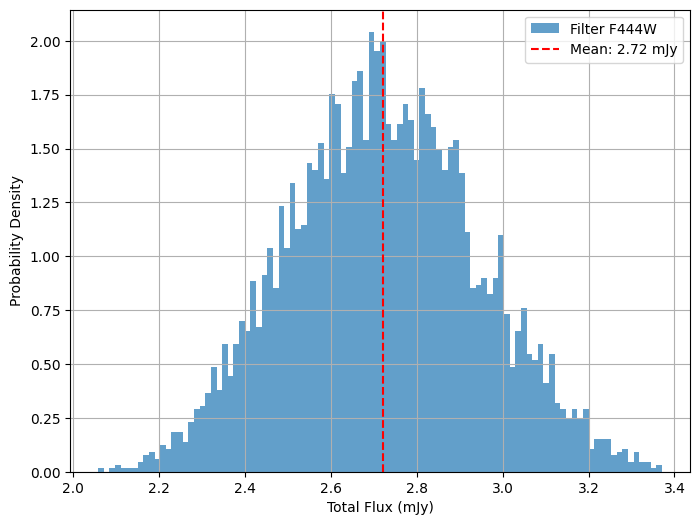

In [24]:
# Number of bootstrap samples 
n_bootstrap = 5000 # Number of bootstrap samples

# Deconvolved Images Photometry
print("Deconvolved Images Photometry")
deconv_fluxes = np.empty(len(deconv_images))
deconv_efluxes = np.empty(len(deconv_images))
error_profs = []
for filter_name in ['F200W', 'F356W', 'F444W']:
    print(f"Processing filter: {filter_name}")
    error_prof = np.load(f"{filter_name}_best_fractional_error.npz")['best_error_prof']
    error_profs.append(error_prof)
deconv_fluxes, deconv_efluxes = bootstrap_photometry(deconv_images, headers, pixel_scales, n_bootstrap, deconv=True, error_profs=error_profs)

### Make throughput recovery images and calculate photometry for throughput recovery
see Photometry_rust.ipynb for the error estimation of throughput recovery photometry

In [25]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [26]:
# Try to load F444W coronagraphic mask
import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F444W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R


In [27]:
import numpy as np
# Calculate total brightness with consideration of coronagraphic mask by dividing by mask transmission
# The image data is in units of surface brightness, MJy/sr
# To get the total brightness (flux density), we need to sum the values of all pixels and multiply by the solid angle of a single pixel.
# The solid angle of a pixel is pixel_scale^2 (in arcsec^2).

# HPFRDI images
print("HPFRDI Images Photometry with Coronagraphic Mask Correction")
print("="*50)
hpfrdi_fluxes_throughput_recover = np.empty(len(hpfrdi_images))
for i, (image, header, pixel_scale) in enumerate(zip(hpfrdi_images, headers, pixel_scales)):
    if 'filter' in header:
        print(f"Filter: {header['filter']}")
        
    # Load the coronagraphic mask corresponding to the filter
    nrc = webbpsf_ext.NIRCam_ext(filter=header['filter'], image_mask='MASK335R', pupil_mask='CIRCLYOT')
    coron_mask = nrc.gen_mask_image(npix=len(image) ,nd_squares=False, pixelscale=pixel_scale)
    
    # Avoid division by zero by setting a minimum transmission
    min_transmission = 0.01
    corrected_mask = np.clip(coron_mask, min_transmission, 1)
    corrected_image = image / corrected_mask
    
    # Savve the corrected image in a FITS file
    fits.writeto(f'throughput_recover_{header["filter"]}.fits', corrected_image, header, overwrite=True)
    
    # Total brightness = sum(pixel values) * pixel_area
    total_brightness = np.nansum(corrected_image) * (pixel_scale**2)
    print(f"Pixel scale: {pixel_scale:.4f} arcsec/pixel")
    print(f"Solid angle per pixel: {pixel_scale**2:.4f} arcsec^2/pixel")
    print(f"Applied minimum mask transmission of {min_transmission} to avoid division by zero.")
    
    if 'BUNIT' in header:
        bunit = header['BUNIT']
        print(f"The surface brightness unit is: {bunit}")
    else:
        print("BUNIT keyword not found in header.")

    # The unit is MJy/sr, we can convert to mJy.
    # 1 sr = (180/pi)^2 * 3600^2 arcsec^2 = 206265^2 arcsec^2
    # 1 MJy = 1e6 Jy = 1e9 mJy
    # So, 1 MJy/sr = 1e9 mJy / (206265^2 arcsec^2) = 2.35e-2 mJy/arcsec^2
    #if 'BUNIT' in header and header['BUNIT'].lower() == 'mjy/sr':
    if True:
        conversion_factor = 2.3504e-2 # mJy/arcsec^2 per MJy/sr
        total_flux_mjy = total_brightness * conversion_factor
        print(f"Total flux in mJy: {total_flux_mjy:.2f} mJy")
        print("="*40)
        hpfrdi_fluxes_throughput_recover[i] = total_flux_mjy

HPFRDI Images Photometry with Coronagraphic Mask Correction
Filter: F200W
[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_MASK335R
Pixel scale: 0.0307 arcsec/pixel
Solid angle per pixel: 0.0009 arcsec^2/pixel
Applied minimum mask transmission of 0.01 to avoid division by zero.
BUNIT keyword not found in header.
Total flux in mJy: 23.71 mJy
Filter: F356W
[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
Pixel scale: 0.0624 arcsec/pixel
Solid angle per pixel: 0.0039 arcsec^2/pixel
Applied minim

# Photometry Results and Disk/Star Flux Ratio Plot

### Show photometry results from Photometry_rust.ipynb

In [28]:
# Read photometry_twhya.npz file
photometry_twhya = np.load('photometry_twhya.npz')
# Display results in a table
print("\n" + "="*90)
print("Photometry of TW Hya with JWST data")
print("-" * 90)
print(f"{'Filter':<10} {'HPFRDI Flux [mJy]':<20} {'Throughput Recover Flux [mJy]':<30} {'Deconvolved Flux [mJy]':<25}")
print("-" * 90)
for i, header in enumerate(headers):
    filter_name = header['filter'] if 'filter' in header else 'Unknown'
    hpfrdi_flux = photometry_twhya['hpfrdi_fluxes'][i]
    hpfrdi_eflux = photometry_twhya['hpfrdi_efluxes'][i]
    deconv_flux = photometry_twhya['deconv_fluxes'][i]
    deconv_eflux = photometry_twhya['deconv_efluxes'][i]
    hpfrdi_flux_throughput_recover =photometry_twhya['throughput_fluxes'][i]
    hpfrdi_eflux_throughput_recover = photometry_twhya['throughput_efluxes'][i]
    print(f"{filter_name:<10} {hpfrdi_flux:.3f} ± {err_rp(hpfrdi_eflux):<18.3f} {hpfrdi_flux_throughput_recover:.2f} ± {err_rp(hpfrdi_eflux_throughput_recover,2):<18.2f} {deconv_flux:.2f} ± {err_rp(deconv_eflux,2):.2f}")


Photometry of TW Hya with JWST data
------------------------------------------------------------------------------------------
Filter     HPFRDI Flux [mJy]    Throughput Recover Flux [mJy]  Deconvolved Flux [mJy]   
------------------------------------------------------------------------------------------
F200W      8.259 ± 0.005              23.71 ± 0.07               20.10 ± 1.20
F356W      2.189 ± 0.005              6.45 ± 0.13               3.42 ± 0.11
F444W      1.167 ± 0.006              4.07 ± 0.03               2.72 ± 0.23



Disk/Star Flux Ratio Analysis (Using Synthetic Photometry)
Filter: F200W (2.01 µm)
  Stellar Flux: 823.27 mJy
  Ratio (HPFRDI):      0.010032 ± 0.000088
  Ratio (Deconvolved): 0.024418 ± 0.001392
  Ratio (Throughput Rec): 0.028802 ± 0.000265
--------------------------------------------------
Filter: F356W (3.57 µm)
  Stellar Flux: 351.16 mJy
  Ratio (HPFRDI):      0.006233 ± 0.000099
  Ratio (Deconvolved): 0.009745 ± 0.000327
  Ratio (Throughput Rec): 0.018380 ± 0.000450
--------------------------------------------------
Filter: F444W (4.36 µm)
  Stellar Flux: 236.43 mJy
  Ratio (HPFRDI):      0.004935 ± 0.000092
  Ratio (Deconvolved): 0.011517 ± 0.000957
  Ratio (Throughput Rec): 0.017199 ± 0.000329
--------------------------------------------------


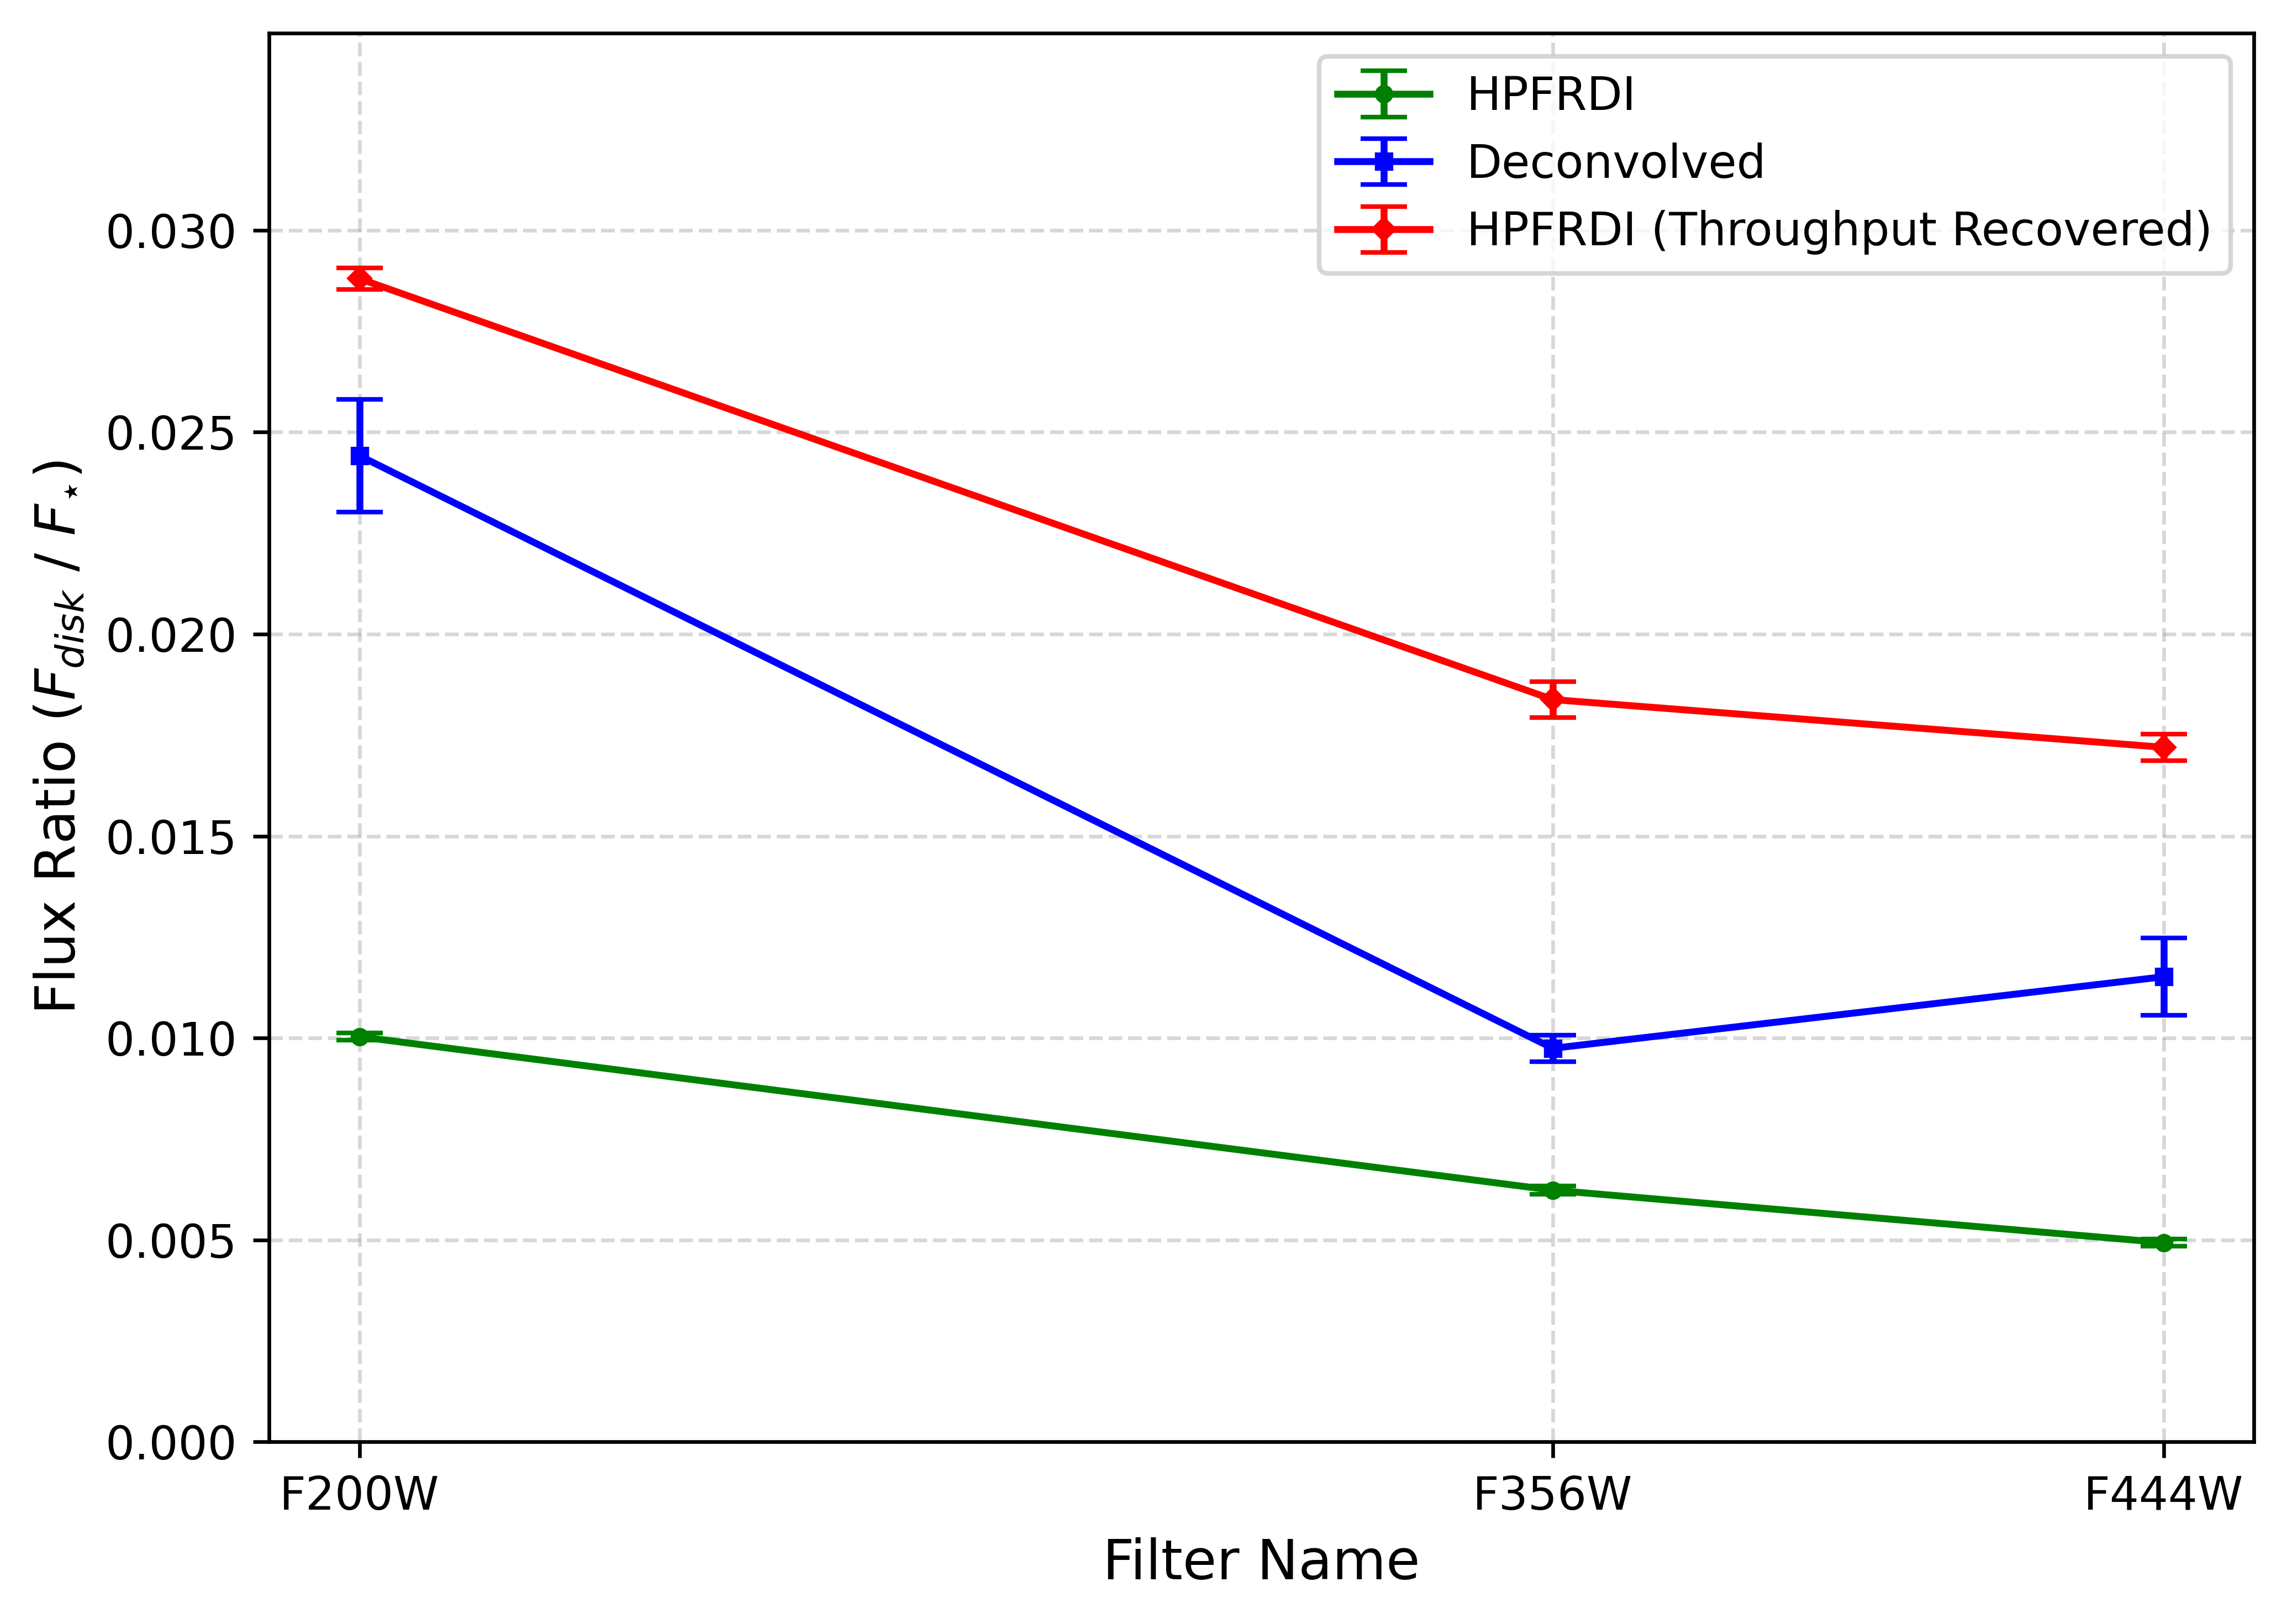

In [29]:
# --- 1. Extract values from previous results ---
# Effective wavelengths and integrated fluxes/errors
filter_names = filter_results['name']
wavelengths = np.array(filter_results['wavelength'])
st_fluxes = np.array(filter_results['two_component_flux'])  # In Jy
st_errs = np.array(filter_results['two_component_err'])    # In Jy

num_filters = len(filter_names)

# Initialize storage arrays
hpfrdi_disk_star_ratios = np.zeros(num_filters)
hpfrdi_disk_star_ratios_err = np.zeros(num_filters)
deconv_disk_star_ratios = np.zeros(num_filters)
deconv_disk_star_ratios_err = np.zeros(num_filters)
hpfrdi_throughput_recover_disk_star_ratios = np.zeros(num_filters)
hpfrdi_throughput_recover_disk_star_ratios_err = np.zeros(num_filters)

print("\nDisk/Star Flux Ratio Analysis (Using Synthetic Photometry)")
print("="*90)

# Read photometry_twhya.npz file
photometry_twhya = np.load('photometry_twhya.npz')

# --- 2. Calculate Ratios ---
# Assuming hpfrdi_fluxes and deconv_fluxes are in mJy
for i in range(num_filters):
    filt = filter_names[i]
    wl = wavelengths[i]
    f_star = st_fluxes[i]
    e_star = st_errs[i]
    hpfrdi_flux = photometry_twhya['hpfrdi_fluxes'][i]
    hpfrdi_eflux = photometry_twhya['hpfrdi_efluxes'][i]
    deconv_flux = photometry_twhya['deconv_fluxes'][i]
    deconv_eflux = photometry_twhya['deconv_efluxes'][i]
    hpfrdi_flux_throughput_recover =photometry_twhya['throughput_fluxes'][i]
    hpfrdi_eflux_throughput_recover = photometry_twhya['throughput_efluxes'][i]
    
    
    # A. HPFRDI Ratio
    # Formula: (Disk_mJy / 1000) / Star_Jy
    hpfrdi_disk_star_ratios[i] = (hpfrdi_flux / 1000.0) / f_star
    hpfrdi_disk_star_ratios_err[i] = hpfrdi_disk_star_ratios[i] * np.sqrt(
        (hpfrdi_eflux / hpfrdi_flux)**2 + (e_star / f_star)**2
    )
    
    # B. HPFRDI with Throughput Recovery
    hpfrdi_throughput_recover_disk_star_ratios[i] = (hpfrdi_flux_throughput_recover / 1000.0) / f_star
    hpfrdi_throughput_recover_disk_star_ratios_err[i] = hpfrdi_throughput_recover_disk_star_ratios[i] * np.sqrt(
        (hpfrdi_eflux_throughput_recover / hpfrdi_flux_throughput_recover)**2 + (e_star / f_star)**2
    )
    
    # C. Deconvolved Ratio
    deconv_disk_star_ratios[i] = (deconv_flux / 1000.0) / f_star
    deconv_disk_star_ratios_err[i] = deconv_disk_star_ratios[i] * np.sqrt(
        (deconv_eflux / deconv_flux)**2 + (e_star / f_star)**2
    )

    print(f"Filter: {filt} ({wl:.2f} µm)")
    print(f"  Stellar Flux: {f_star*1000:.2f} mJy")
    print(f"  Ratio (HPFRDI):      {hpfrdi_disk_star_ratios[i]:.6f} ± {hpfrdi_disk_star_ratios_err[i]:.6f}")
    print(f"  Ratio (Deconvolved): {deconv_disk_star_ratios[i]:.6f} ± {deconv_disk_star_ratios_err[i]:.6f}")
    print(f"  Ratio (Throughput Rec): {hpfrdi_throughput_recover_disk_star_ratios[i]:.6f} ± {hpfrdi_throughput_recover_disk_star_ratios_err[i]:.6f}")
    print("-" * 50)

# --- 3. Plotting ---
plt.figure(figsize=(7, 5), dpi=600)

# Use errorbar with filter names as x-ticks
plt.errorbar(wavelengths, hpfrdi_disk_star_ratios, yerr=hpfrdi_disk_star_ratios_err, 
             marker='o', markersize=3, capsize=5, linestyle='-', color='green', label='HPFRDI')

plt.errorbar(wavelengths, deconv_disk_star_ratios, yerr=deconv_disk_star_ratios_err, 
             marker='s', markersize=3, capsize=5, linestyle='-', color='blue', label='Deconvolved')

plt.errorbar(wavelengths, hpfrdi_throughput_recover_disk_star_ratios, yerr=hpfrdi_throughput_recover_disk_star_ratios_err, 
             marker='D', markersize=3, capsize=5, linestyle='-', color='red', label='HPFRDI (Throughput Recovered)')

# Formatting
plt.xlabel(r'Filter Name', fontsize=12)
plt.ylabel(r'Flux Ratio ($F_{disk}$ / $F_{\star}$)', fontsize=12)
#plt.title('Disk-to-Star Contrast Ratios', fontsize=14)

# Set X-ticks to the specific filter wavelengths
plt.xticks(wavelengths, filter_names)

# Dynamic Y-limit
max_val = max(np.max(hpfrdi_throughput_recover_disk_star_ratios + hpfrdi_throughput_recover_disk_star_ratios_err),
              np.max(deconv_disk_star_ratios + deconv_disk_star_ratios_err))
plt.ylim(0, max_val * 1.2)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

# Off-Axis Beam Size 

In [30]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [31]:
# TW Hya stellar spectrum from VOTable
import webbpsf_ext
from astropy.table import Table
star_vot = Table.read("fitted_two_component_TWHya.vot")
wave_data = star_vot['wavelength'].value
flux_data = star_vot['sed_flux'].value
wave_units = star_vot['wavelength'].unit
flux_units = star_vot['sed_flux'].unit
print(f"Wave units: {wave_units}, Flux units: {flux_units}")
spec_synphot = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=wave_data,
    flux=flux_data,
    waveunits='micron',   # 
    fluxunits='Jy'      # 'flam' is erg/s/cm^2/A. Adjust to 'Jy', 'photlam', etc. based on your VOTable
)

Wave units: micron, Flux units: Jy


### F200W Off-Axis Beam Size Calculation

In [32]:
import numpy as np
import webbpsf_ext

# 1. Configure the NIRCam observation
nircam = webbpsf_ext.NIRCam_ext(
    filter='F200W', 
    image_mask='MASK335R', 
    pupil_mask='CIRCLYOT'
)

# 2. Simulate the PSF
oversample_factor = 10

# Source offset: 1.5" at PA 0 (Shift along +Y)
# We use 'idl' frame for arcsecs relative to aperture center. X=0.0, Y=1.5
psf_hdul = nircam.calc_psf(
    oversample=oversample_factor,
    coord_vals=(0.0, 1.5), 
    coord_frame='idl',
    sp=spec_synphot,
    return_hdul=True
)

# 3. Extract the oversampled PSF array
# In standard webbpsf output, the oversampled array is kept in the 'OVERSAMP' extension 
# or the primary HDU (index 0).
try:
    oversampled_psf = psf_hdul['OVERSAMP'].data
except KeyError:
    oversampled_psf = psf_hdul[0].data

# 4. Calculate the effective beam size (N_beam) in native detector pixels
psf_sum = np.sum(oversampled_psf)
psf_max = np.max(oversampled_psf)

# Apply the mathematical formula from the text
n_beam = (psf_sum / psf_max) * (1.0 / oversample_factor**2)

print(f"Calculated N_beam: {n_beam:.15f} pixels")

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_MASK335R
[     poppy:INFO] PSF calc using fov_pixels = 267, oversample = 10, number of wavelengths = 13
[     stpsf:INFO] Creating optical system model:
[     poppy:INFO] Initialized OpticalSystem: JWST+NIRCam
[     poppy:INFO] JWST Entrance Pupil: Loaded amplitude transmission from /npool/nvme/yuchialin/JWST/stpsf_data/jwst_pupil_RevW_npix1024.fits.gz
[     poppy:INFO] JWST Entrance Pupil: Loaded OPD from /npool/nvme/yuchialin/JWST/stpsf_data/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
[     stpsf:INFO] Loading field dependent model parameters from /npool/nvme/yuchialin/JWST/stpsf_data/NIRCam/OPD/field_dep_table_nircam.fits
[     stpsf:INFO] Calculating field-

### F356W Off-Axis Beam Size Calculation

In [ ]:
import numpy as np
import webbpsf_ext

# 1. Configure the NIRCam observation
nircam = webbpsf_ext.NIRCam_ext(
    filter='F356W', 
    image_mask='MASK335R', 
    pupil_mask='CIRCLYOT'
)

# 2. Simulate the PSF
oversample_factor = 10

# Source offset: 1.5" at PA 0 (Shift along +Y)
# We use 'idl' frame for arcsecs relative to aperture center. X=0.0, Y=1.5
psf_hdul = nircam.calc_psf(
    oversample=oversample_factor,
    coord_vals=(0.0, 1.5), 
    coord_frame='idl',
    sp=spec_synphot,
    return_hdul=True
)

# 3. Extract the oversampled PSF array
# In standard webbpsf output, the oversampled array is kept in the 'OVERSAMP' extension 
# or the primary HDU (index 0).
try:
    oversampled_psf = psf_hdul['OVERSAMP'].data
except KeyError:
    oversampled_psf = psf_hdul[0].data

# 4. Calculate the effective beam size (N_beam) in native detector pixels
psf_sum = np.sum(oversampled_psf)
psf_max = np.max(oversampled_psf)

# Apply the mathematical formula from the text
n_beam = (psf_sum / psf_max) * (1.0 / oversample_factor**2)

print(f"Calculated N_beam: {n_beam:.15f} pixels")

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     poppy:INFO] PSF calc using fov_pixels = 267, oversample = 10, number of wavelengths = 13
[     stpsf:INFO] Creating optical system model:
[     poppy:INFO] Initialized OpticalSystem: JWST+NIRCam
[     poppy:INFO] JWST Entrance Pupil: Loaded amplitude transmission from /npool/nvme/yuchialin/JWST/stpsf_data/jwst_pupil_RevW_npix1024.fits.gz
[     poppy:INFO] JWST Entrance Pupil: Loaded OPD from /npool/nvme/yuchialin/JWST/stpsf_data/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
[     stpsf:INFO] Loading field dependent model parameters from /npool/nvme/yuchialin/JWST/stpsf_data/NIRCam/OPD/field_dep_table_nircam.fits
[     stpsf:INFO] Calculating field-dependent OTE OPD at v2 = 1.790 arcmin, v3 = -6.727 arcmin
[     poppy

### F444W Off-Axis Beam Size Calculation

In [ ]:
import numpy as np
import webbpsf_ext

# 1. Configure the NIRCam observation
nircam = webbpsf_ext.NIRCam_ext(
    filter='F444W', 
    image_mask='MASK335R', 
    pupil_mask='CIRCLYOT'
)

# 2. Simulate the PSF
oversample_factor = 10

# Source offset: 1.5" at PA 0 (Shift along +Y)
# We use 'idl' frame for arcsecs relative to aperture center. X=0.0, Y=1.5
psf_hdul = nircam.calc_psf(
    oversample=oversample_factor,
    coord_vals=(0.0, 1.5), 
    coord_frame='idl',
    sp=spec_synphot,
    return_hdul=True
)

# 3. Extract the oversampled PSF array
# In standard webbpsf output, the oversampled array is kept in the 'OVERSAMP' extension 
# or the primary HDU (index 0).
try:
    oversampled_psf = psf_hdul['OVERSAMP'].data
except KeyError:
    oversampled_psf = psf_hdul[0].data

# 4. Calculate the effective beam size (N_beam) in native detector pixels
psf_sum = np.sum(oversampled_psf)
psf_max = np.max(oversampled_psf)

# Apply the mathematical formula from the text
n_beam = (psf_sum / psf_max) * (1.0 / oversample_factor**2)

print(f"Calculated N_beam: {n_beam:.15f} pixels")

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     poppy:INFO] PSF calc using fov_pixels = 267, oversample = 10, number of wavelengths = 16
[     stpsf:INFO] Creating optical system model:
[     poppy:INFO] Initialized OpticalSystem: JWST+NIRCam
[     poppy:INFO] JWST Entrance Pupil: Loaded amplitude transmission from /npool/nvme/yuchialin/JWST/stpsf_data/jwst_pupil_RevW_npix1024.fits.gz
[     poppy:INFO] JWST Entrance Pupil: Loaded OPD from /npool/nvme/yuchialin/JWST/stpsf_data/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
[     stpsf:INFO] Loading field dependent model parameters from /npool/nvme/yuchialin/JWST/stpsf_data/NIRCam/OPD/field_dep_table_nircam.fits
[     stpsf:INFO] Calculating field-dependent OTE OPD at v2 = 1.790 arcmin, v3 = -6.727 arcmin
[     poppy

# Coronagraphic Mask

In [ ]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [ ]:
import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F200W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_MASK335R


In [ ]:
import numpy as np
# IWA in pixels
max_thoughput = np.max(coron_mask)
iwa_pixels = np.where(coron_mask <= 0.5 * max_thoughput)
iwa_pixels_num = len(iwa_pixels[0])
iwa_radius_pixels = np.sqrt(iwa_pixels_num / np.pi)
print(f"Calculated IWA radius: {iwa_radius_pixels:.2f} pixels")

Calculated IWA radius: 20.78 pixels


Text(0, 0.5, 'Pixels')

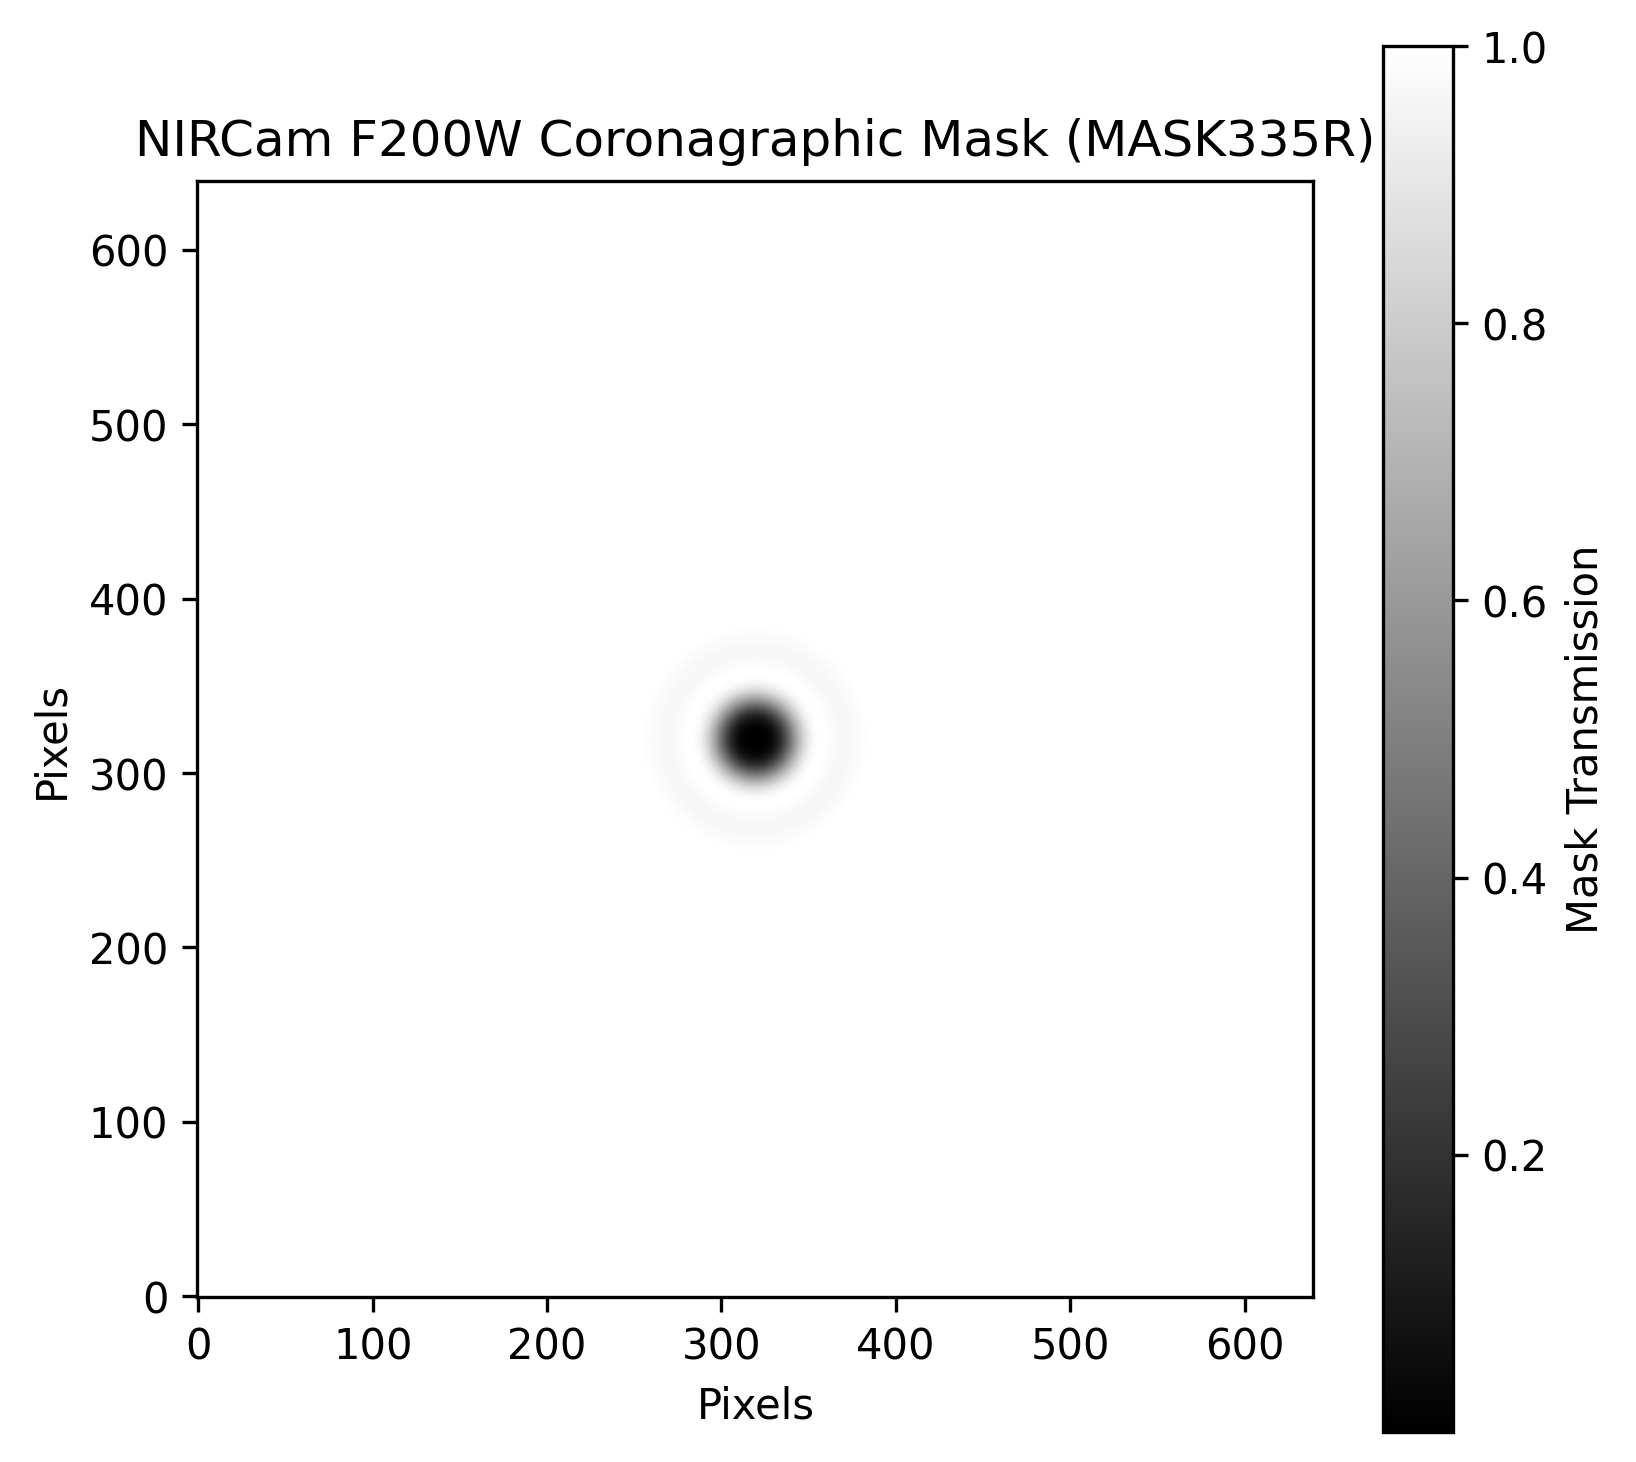

In [ ]:
import matplotlib.pyplot as plt
# Display the coronagraphic mask
plt.figure(figsize=(6, 6), dpi=300)
plt.imshow(coron_mask, cmap='gray', origin='lower')
plt.colorbar(label='Mask Transmission')
plt.title('NIRCam F200W Coronagraphic Mask (MASK335R)')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

In [ ]:
import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F444W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R


Text(0, 0.5, 'Pixels')

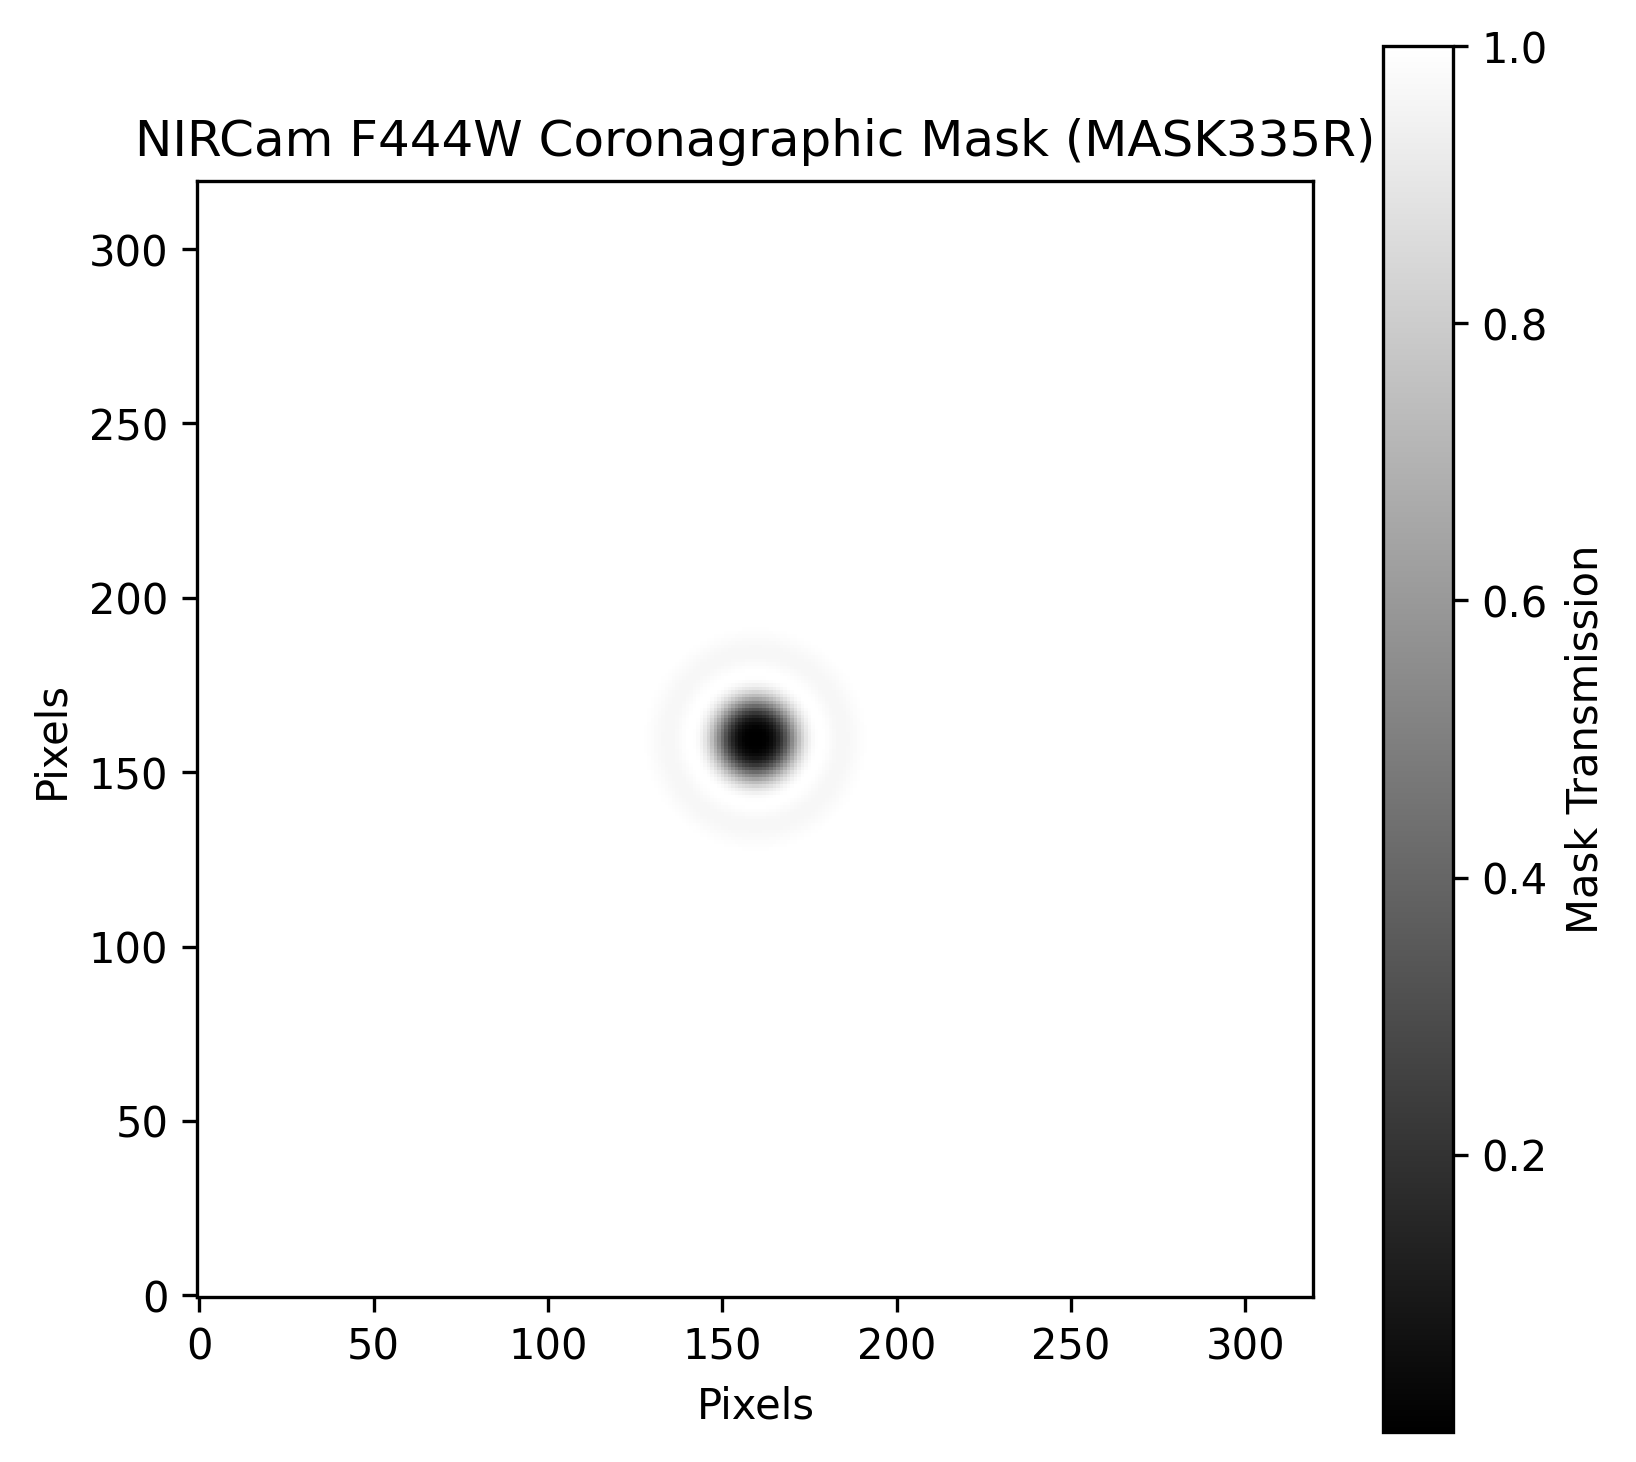

In [ ]:
import matplotlib.pyplot as plt
# Display the coronagraphic mask
plt.figure(figsize=(6, 6), dpi=300)
plt.imshow(coron_mask, cmap='gray', origin='lower')
plt.colorbar(label='Mask Transmission')
plt.title('NIRCam F444W Coronagraphic Mask (MASK335R)')
plt.xlabel('Pixels')
plt.ylabel('Pixels')